In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:32798")
client

<Client: 'tcp://127.0.0.1:32798' processes=8 threads=32, memory=503.70 GiB>

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
from xhistogram.xarray import histogram as xhist
from xgcm.grid import Grid
import gsw

import rioxarray
import seaborn as sns
import xrft

import glob

import gcm_filters

import os.path as op

from scipy.interpolate import griddata, interpn

import warnings
warnings.filterwarnings("ignore")

# from xeofs.models import EOF
from pydmd import DMD, BOPDMD, MrDMD
from pydmd.mrcosts import mrCOSTS
from pydmd.preprocessing import hankel_preprocessing
from pydmd.plotter import plot_eigs, plot_summary

from matplotlib import ticker
import matplotlib.colors as clr
import matplotlib.pyplot as plt
plt.rcParams['pcolor.shading'] = 'auto'
%matplotlib inline

In [3]:
grav = 9.807
meth = "linear"
ddir = "/storage/tartar/takaya/swot/"

# Agulhas Rings

In [173]:
ds01 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 1))
ds01.coords["num_lines"] = ("num_lines",range(len(ds01.num_lines)))
ds01.coords["num_pixels"] = ("num_pixels",range(len(ds01.num_pixels)))

ds16 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 16))
ds16.coords["num_lines"] = ("num_lines",range(len(ds16.num_lines)))
ds16.coords["num_pixels"] = ("num_pixels",range(len(ds16.num_pixels)))
ds01,ds16

(<xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
     longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 571MB dask.array<chunksize=(1, 9860, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels  

In [174]:
maskn1 = xr.DataArray(ds01.latitude.where(ds01.latitude>-38.2).to_masked_array().mask,
                     dims=ds01.latitude.dims,
                     coords=ds01.latitude.coords
                    )
masks1 = xr.DataArray(ds01.latitude.where(ds01.latitude<-33).to_masked_array().mask,
                     dims=ds01.latitude.dims,
                     coords=ds01.latitude.coords
                    )
xo01 = ds01.where(~maskn1,drop=True).where(~masks1,drop=True)

maskn6 = xr.DataArray(ds16.latitude.where(ds16.latitude>-38.2).to_masked_array().mask,
                     dims=ds16.latitude.dims,
                     coords=ds16.latitude.coords
                    )
masks6 = xr.DataArray(ds16.latitude.where(ds16.latitude<-33).to_masked_array().mask,
                     dims=ds16.latitude.dims,
                     coords=ds16.latitude.coords
                    )
xo16 = ds16.where(~maskn6,drop=True).where(~masks6,drop=True)
xo01, xo16

(<xarray.Dataset> Size: 18MB
 Dimensions:       (cycle_num: 105, num_lines: 310, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 2kB 2777 2778 2779 2780 ... 3084 3085 3086
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 171kB -38.19 -38.2 ... -33.0
     longitude     (num_lines, num_pixels) float64 171kB 14.54 14.56 ... 17.44
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 18MB dask.array<chunksize=(1, 310, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 18MB
 Dimensions:       (cycle_num: 105, num_lines: 310, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 2kB 6775 6776 6777 6778 ... 7082 7083 7084
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 

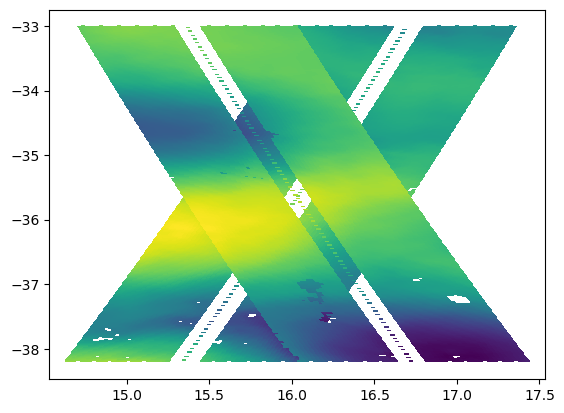

In [6]:
fig, ax = plt.subplots()
ax.pcolormesh(xo01.longitude, xo01.latitude,
              xo01.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )
ax.pcolormesh(xo16.longitude, xo16.latitude,
              xo16.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )

In [175]:
inp = 3

mask01 = xr.DataArray(xo01.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo01.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo01.ssha_detided.isel(cycle_num=0).coords
                    )
mm01 = xr.DataArray(mask01.where(mask01<.5
                              ).to_masked_array().mask,
                   dims=xo01.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo01.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mask16 = xr.DataArray(xo16.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo16.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo16.ssha_detided.isel(cycle_num=0).coords
                    )
mm16 = xr.DataArray(mask16.where(mask16<.5
                              ).to_masked_array().mask,
                   dims=xo16.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo16.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mm01, mm16

(<xarray.DataArray (num_lines: 310, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ...,  True,  True,  True]], shape=(310, 63))
 Coordinates:
   * num_lines   (num_lines) int64 2kB 2777 2778 2779 2780 ... 3084 3085 3086
   * num_pixels  (num_pixels) int64 504B 3 4 5 6 7 8 9 ... 59 60 61 62 63 64 65
     cycle_num   int64 8B 474
     latitude    (num_lines, num_pixels) float64 156kB -38.2 -38.21 ... -32.99
     longitude   (num_lines, num_pixels) float64 156kB 14.61 14.63 ... 17.38,
 <xarray.DataArray (num_lines: 310, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  Tr

In [176]:
low01 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass%03d/SSHa.zarr" 
                               % 1)
                      ).ssha.where(~maskn1,drop=True).where(~masks1,drop=True)
low16 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass%03d/SSHa.zarr" 
                               % 16)
                      ).ssha.where(~maskn6,drop=True).where(~masks6,drop=True)
low01, low16

(<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 308, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 308, 61), dtype=float64, chunksize=(1, 308, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 2kB 2778 2779 2780 2781 ... 3083 3084 3085
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 150kB -38.19 -38.19 ... -33.01
     longitude   (num_lines, num_pixels) float64 150kB 14.64 14.66 ... 17.35,
 <xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 308, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 308, 61), dtype=float64, chunksize=(1, 308, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 2kB 6776 6777 6778 6779 ... 7081 7082 7083
   * num_pixels  (num_pixels) int

In [177]:
r_ref1 = (~mm01).sum() / np.prod(mm01.shape)
r_ref6 = (~mm16).sum() / np.prod(mm16.shape)
r_ref6

<xarray.DataArray ()> Size: 8B
array(0.80491551)
Coordinates:
    cycle_num  int64 8B 474

In [178]:
ageo = (1e-2*ds01.ssha_detided
        - low01
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low01.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r01 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r01 = xr.concat([r01, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref1:
        if ic == 0:
            a01 = ssha
        else:
            try:
                a01 = xr.concat([a01, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a01.coords["cycle_num"] = ("cycle_num",
                           r01.where(r01>0.7*r_ref1, drop=True).cycle_num.data
                          )

dsa01 = a01.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa01.coords["y"] = ("y",range(len(dsa01.y)))
dsa01.coords["x"] = ("x",range(len(dsa01.x)))
if not dsa01.rio.crs:
    dsa01 = dsa01.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa01.ssha.rio.nodata is None:
    dsa01["ssha"] = dsa01.ssha.rio.write_nodata(np.nan)
_a01_exterp = dsa01.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a01_interp = _a01_exterp.interp(cycle_num=ds01.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a01_exterp = _a01_exterp.where(mm01.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds01.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa01.close()

dsg01 = low01.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg01.coords["y"] = ("y",range(len(dsg01.y)))
dsg01.coords["x"] = ("x",range(len(dsg01.x)))
if not dsg01.rio.crs:
    dsg01 = dsg01.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg01.ssha.rio.nodata is None:
    dsg01["ssha"] = dsg01.ssha.rio.write_nodata(np.nan)
_g01_exterp = dsg01.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g01_interp = _g01_exterp.interp(cycle_num=ds01.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g01_exterp = _g01_exterp.where(mm01.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds01.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg01.close()

In [179]:
ageo = (1e-2*ds16.ssha_detided
        - low16
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low16.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r16 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r16 = xr.concat([r16, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref6:
        if ic == 0:
            a16 = ssha
        else:
            try:
                a16 = xr.concat([a16, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a16.coords["cycle_num"] = ("cycle_num",
                           r16.where(r16>0.7*r_ref6, drop=True).cycle_num.data
                          )

dsa16 = a16.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa16.coords["y"] = ("y",range(len(dsa16.y)))
dsa16.coords["x"] = ("x",range(len(dsa16.x)))
if not dsa16.rio.crs:
    dsa16 = dsa16.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa16.ssha.rio.nodata is None:
    dsa16["ssha"] = dsa16.ssha.rio.write_nodata(np.nan)
_a16_exterp = dsa16.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a16_interp = _a16_exterp.interp(cycle_num=ds16.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a16_exterp = _a16_exterp.where(mm16.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds16.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa16.close()

dsg16 = low16.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg16.coords["y"] = ("y",range(len(dsg16.y)))
dsg16.coords["x"] = ("x",range(len(dsg16.x)))
if not dsg16.rio.crs:
    dsg16 = dsg16.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg16.ssha.rio.nodata is None:
    dsg16["ssha"] = dsg16.ssha.rio.write_nodata(np.nan)
_g16_exterp = dsg16.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g16_interp = _g16_exterp.interp(cycle_num=ds16.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g16_exterp = _g16_exterp.where(mm16.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds16.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg16.close()

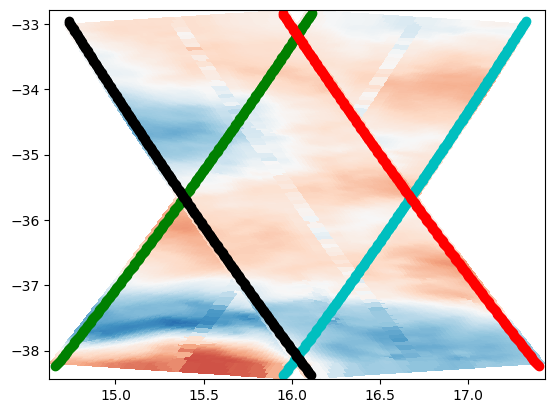

In [12]:
fig, ax = plt.subplots()
ax.pcolormesh(a01_exterp.longitude, a01_exterp.latitude,
              _a01_interp.isel(cycle_num=10),
              vmax=.3, vmin=-.3, cmap="RdBu_r",
              rasterized=True
             )
ax.pcolormesh(a16_exterp.longitude, a16_exterp.latitude,
              _a16_interp.isel(cycle_num=10),
              vmax=.3, vmin=-.3, cmap="RdBu_r",
              rasterized=True
             )
ax.scatter(a01_exterp.longitude.isel(num_pixels=1), a01_exterp.latitude.isel(num_pixels=13), c="g")
ax.scatter(a01_exterp.longitude.isel(num_pixels=-2), a01_exterp.latitude.isel(num_pixels=-14), c="c")
ax.scatter(a16_exterp.longitude.isel(num_pixels=1), a16_exterp.latitude.isel(num_pixels=13), c="r")
ax.scatter(a16_exterp.longitude.isel(num_pixels=-2), a16_exterp.latitude.isel(num_pixels=-14), c="k")

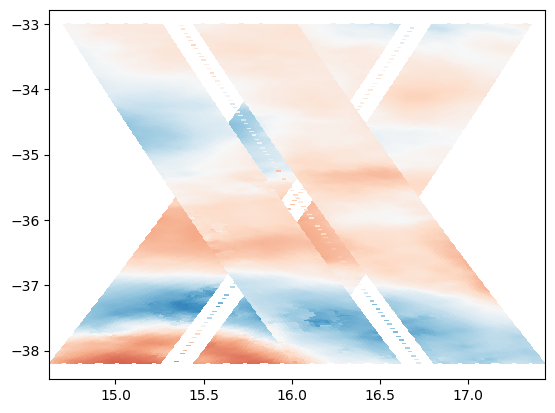

In [13]:
fig, ax = plt.subplots()
ax.pcolormesh(a01_exterp.longitude, a01_exterp.latitude,
              a01_exterp.isel(cycle_num=11),
              vmax=.3, vmin=-.3, cmap="RdBu_r",
              rasterized=True
             )
ax.pcolormesh(a16_exterp.longitude, a16_exterp.latitude,
              a16_exterp.isel(cycle_num=11),
              vmax=.3, vmin=-.3, cmap="RdBu_r",
              rasterized=True
             )

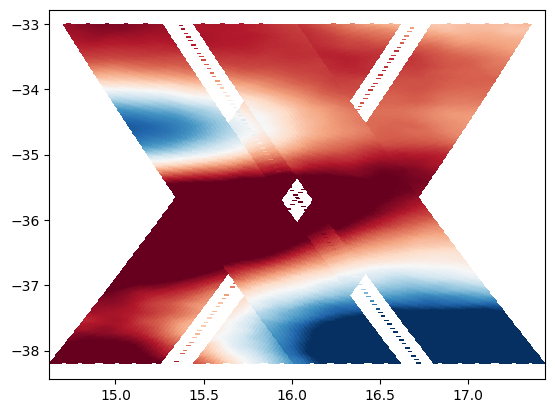

In [14]:
fig, ax = plt.subplots()
ax.pcolormesh(g01_exterp.longitude, g01_exterp.latitude,
              g01_exterp.isel(cycle_num=11),
              vmax=.3, vmin=-.3, cmap="RdBu_r",
              rasterized=True
             )
ax.pcolormesh(g16_exterp.longitude, g16_exterp.latitude,
              g16_exterp.isel(cycle_num=11),
              vmax=.3, vmin=-.3, cmap="RdBu_r",
              rasterized=True
             )

In [180]:
for cc in low01.cycle_num:
    if cc == low01.cycle_num[0]:
        ar_g1 = g01_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a1 = a01_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])

        ar_g6 = g16_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a6 = a16_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
    else:
        ar_g1 = xr.concat([ar_g1, 
                          g01_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a1 = xr.concat([ar_a1, 
                          a01_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_g6 = xr.concat([ar_g6, 
                          g16_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a6 = xr.concat([ar_a6, 
                          a16_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")

ar_g1.coords["time"] = ("time",np.arange(len(ar_g1.time))*24*60.*60)
ar_a1.coords["time"] = ("time",np.arange(len(ar_a1.time))*24*60.*60)
ar_g6.coords["time"] = ("time",np.arange(len(ar_g6.time))*24*60.*60)
ar_a6.coords["time"] = ("time",np.arange(len(ar_a6.time))*24*60.*60)
ar_g1.coords["num_lines"] = ("num_lines",np.arange(len(ar_g1.num_lines))*2e3)
ar_a1.coords["num_lines"] = ("num_lines",np.arange(len(ar_a1.num_lines))*2e3)
ar_g6.coords["num_lines"] = ("num_lines",np.arange(len(ar_g6.num_lines))*2e3)
ar_a6.coords["num_lines"] = ("num_lines",np.arange(len(ar_a6.num_lines))*2e3)

ar_g1, ar_a6

(<xarray.DataArray 'ssha' (time: 105, num_lines: 283, num_pixels: 2)> Size: 475kB
 array([[[-0.04069551, -0.30028431],
         [-0.04346493, -0.29600186],
         [-0.04425719, -0.29273473],
         ...,
         [ 0.1939396 ,  0.14683527],
         [ 0.19450138,  0.14700308],
         [ 0.19512314,  0.14566583]],
 
        [[ 0.14328106, -0.28826803],
         [ 0.14083391, -0.28262377],
         [ 0.13961104, -0.27713832],
         ...,
         [ 0.1839095 ,  0.1088834 ],
         [ 0.1832461 ,  0.10840801],
         [ 0.18246323,  0.10711957]],
 
        [[ 0.20604808, -0.30712103],
         [ 0.20504666, -0.30009065],
         [ 0.20474143, -0.29260492],
         ...,
 ...
         ...,
         [ 0.03747999,  0.09770962],
         [ 0.04030186,  0.09723225],
         [ 0.04323615,  0.09572853]],
 
        [[ 0.0787505 , -0.31511513],
         [ 0.07595077, -0.31825273],
         [ 0.0733572 , -0.32125182],
         ...,
         [ 0.03641056,  0.09731996],
         [ 0.0392140

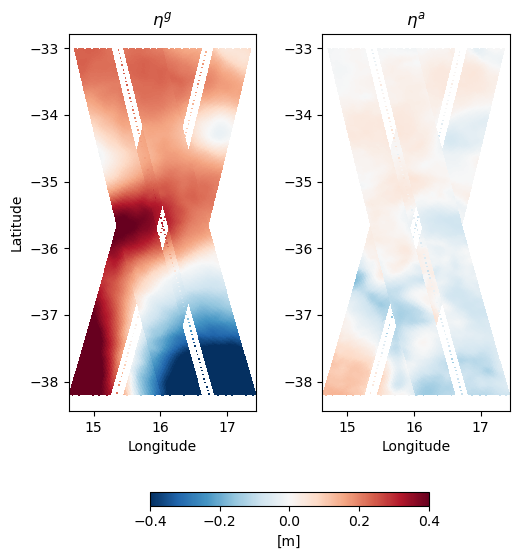

In [181]:
cnum = 20
fig, axes = plt.subplots(figsize=(6,7), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].pcolormesh(g01_exterp.isel(cycle_num=cnum).longitude, g01_exterp.isel(cycle_num=cnum).latitude,
               g01_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[0].pcolormesh(g16_exterp.isel(cycle_num=cnum).longitude, g16_exterp.isel(cycle_num=cnum).latitude,
               g16_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[1].pcolormesh(a01_exterp.isel(cycle_num=cnum).longitude, a01_exterp.isel(cycle_num=cnum).latitude,
               a01_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[1].pcolormesh(a16_exterp.isel(cycle_num=cnum).longitude, a16_exterp.isel(cycle_num=cnum).latitude,
               a16_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[0].set_aspect("equal")
axes[1].set_aspect("equal")
axes[0].set_xlabel(r"Longitude")
axes[0].set_ylabel(r"Latitude")
axes[1].set_xlabel(r"Longitude")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.6)
cbar.set_label(r"[m]")
axes[0].set_title(r"$\eta^g$")
axes[1].set_title(r"$\eta^a$")
plt.savefig(op.join(ddir,"../Figs/ssha-AR.pdf"))

In [182]:
# Fg = xrft.power_spectrum(ar_g.reset_coords(drop=True).chunk({"num_pixels":1}), 
#                          dim=["time"], 
#                          detrend="linear", window="hann",
#                          window_correction=True
#                         )
# Fg = xrft.power_spectrum(Fg.reset_coords(drop=True), 
#                          dim=["num_lines"], 
#                          detrend="linear", window="hann",
#                          window_correction=True
#                         ).mean("num_pixels")
# Fa = xrft.power_spectrum(ar_a.reset_coords(drop=True).chunk({"num_pixels":1}), 
#                          dim=["time"], 
#                          detrend="linear", window="hann",
#                          window_correction=True
#                         )
# Fa = xrft.power_spectrum(Fa.reset_coords(drop=True), 
#                          dim=["num_lines"], 
#                          detrend="linear", window="hann",
#                          window_correction=True
#                         ).mean("num_pixels")
Fg1 = xrft.power_spectrum(ar_g1.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg1 = xrft.power_spectrum(Fg1.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa1 = xrft.power_spectrum(ar_a1.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa1 = xrft.power_spectrum(Fa1.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fg6 = xrft.power_spectrum(ar_g6.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg6 = xrft.power_spectrum(Fg6.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa6 = xrft.power_spectrum(ar_a6.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa6 = xrft.power_spectrum(Fa6.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa = .5*(Fa1 + Fa6)
Fg = .5*(Fg1 + Fg6)
Fg, Fa

(<xarray.DataArray (freq_time: 105, freq_num_lines: 283)> Size: 238kB
 dask.array<mul, shape=(105, 283), dtype=float64, chunksize=(105, 283), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.0002491 ... 0.0002491,
 <xarray.DataArray (freq_time: 105, freq_num_lines: 283)> Size: 238kB
 dask.array<mul, shape=(105, 283), dtype=float64, chunksize=(105, 283), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.0002491 ... 0.0002491)

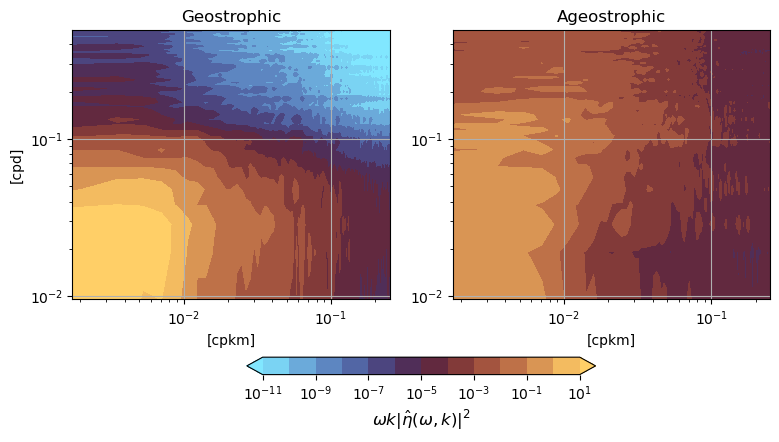

In [15]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fg.freq_num_lines.isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fg.freq_time.isel(freq_time=slice(len(Fg.freq_time)//2,
                                                 None)).values*86400,
               (Fg.freq_num_lines*Fg.freq_time*Fg
               ).isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,None),
                      freq_time=slice(len(Fg.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fa.freq_num_lines.isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fa.freq_time.isel(freq_time=slice(len(Fa.freq_time)//2,
                                                 None)).values*86400,
               (Fa.freq_num_lines*Fa.freq_time*Fa
               ).isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,None),
                      freq_time=slice(len(Fa.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fg.freq_num_lines.where(Fg.freq_num_lines>0.).min()*1e3,
              Fg.freq_num_lines.where(Fg.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fg.freq_time.where(Fg.freq_time>0.).min()*86400,
              Fg.freq_time.where(Fg.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fa.freq_num_lines.where(Fa.freq_num_lines>0.).min()*1e3,
              Fa.freq_num_lines.where(Fa.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fa.freq_time.where(Fa.freq_time>0.).min()*86400,
              Fa.freq_time.where(Fa.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"$\omega k |\hat{\eta}(\omega,k)|^2$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_AR.pdf"))

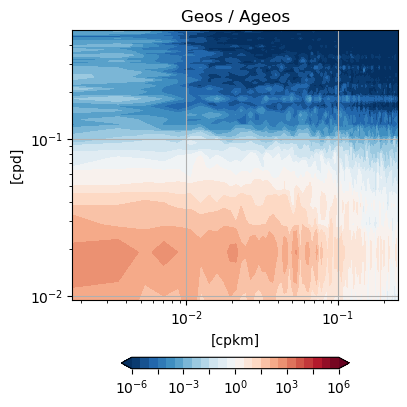

In [183]:
fig, ax = plt.subplots(figsize=(4.2,5))
# fig.set_tight_layout(True)
im = ax.contourf(Fg.freq_num_lines.isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fg.freq_time.isel(freq_time=slice(len(Fg.freq_time)//2,
                                                 None)).values*86400,
               ((Fg.freq_num_lines*Fg.freq_time*Fg
                ).isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,None),
                       freq_time=slice(len(Fg.freq_time)//2,None)
                      ).values.T
                / (Fa.freq_num_lines*Fa.freq_time*Fa
               ).isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,None),
                      freq_time=slice(len(Fa.freq_time)//2,None)
                     ).values.T
               ),
               levels=np.logspace(-6,6,25),
               norm=clr.LogNorm(), cmap="RdBu_r",
               extend="both",
               rasterized=True
              )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([Fg.freq_num_lines.where(Fg.freq_num_lines>0.).min()*1e3,
              Fg.freq_num_lines.where(Fg.freq_num_lines>0.).max()*1e3])
ax.set_ylim([Fg.freq_time.where(Fg.freq_time>0.).min()*86400,
              Fg.freq_time.where(Fg.freq_time>0.).max()*86400])
ax.set_xlabel(r"[cpkm]")
ax.set_ylabel(r"[cpd]")
ax.grid(True)
ax.set_title(r"Geos / Ageos")
cbar = fig.colorbar(im, ax=ax, orientation="horizontal", shrink=.7)
plt.savefig(op.join(ddir,"../Figs/omega-k_AR-ratio.pdf"))

In [27]:
dsv1 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass001/SSVs_SwotDiag.zarr"))
dsv6 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass016/SSVs_SwotDiag.zarr"))
dsv1r = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass001/SSVs_rawSwotDiag.zarr"))
dsv6r = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass016/SSVs_rawSwotDiag.zarr"))
dsv1, dsv6

(<xarray.Dataset> Size: 3GB
 Dimensions:     (cycle_num: 105, num_lines: 9310, num_pixels: 61)
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
     longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
 Data variables:
     strain      (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     ucg         (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     ug          (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     vcg         (cycle_num, num_lines, num_pixels) float64 477MB das

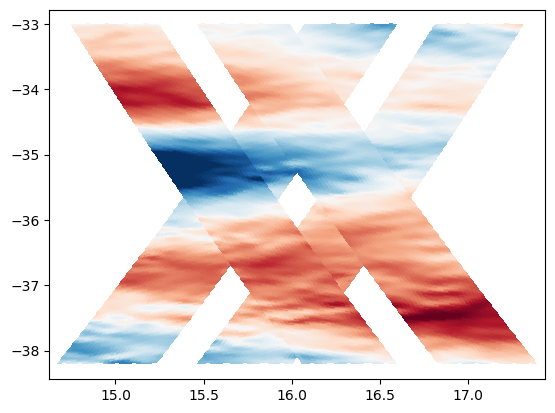

In [28]:
# u1 = dsv1.ucg.where(~maskn1,drop=True).where(~masks1,drop=True)
# u6 = dsv6.ucg.where(~maskn6,drop=True).where(~masks6,drop=True)
u1 = dsv1.ug.where(~maskn1,drop=True).where(~masks1,drop=True)
u6 = dsv6.ug.where(~maskn6,drop=True).where(~masks6,drop=True)

fig, ax = plt.subplots()
ax.pcolormesh(u1.longitude, u1.latitude,
              u1.isel(cycle_num=11),
              vmax=.8, vmin=-.8, cmap="RdBu_r",
              rasterized=True
             )
ax.pcolormesh(u6.longitude, u6.latitude,
              u6.isel(cycle_num=11),
              vmax=.8, vmin=-.8, cmap="RdBu_r",
              rasterized=True
             )

In [29]:
# sp1 = np.sqrt(dsv1.ucg**2 + dsv1.vcg**2).where(~maskn1,drop=True).where(~masks1,drop=True)
# sp6 = np.sqrt(dsv6.ucg**2 + dsv6.vcg**2).where(~maskn6,drop=True).where(~masks6,drop=True)
sp1 = np.sqrt(dsv1.ug**2 + dsv1.vg**2).where(~maskn1,drop=True).where(~masks1,drop=True)
sp6 = np.sqrt(dsv6.ug**2 + dsv6.vg**2).where(~maskn6,drop=True).where(~masks6,drop=True)
v1 = dsv1.vort.where(~maskn1,drop=True).where(~masks1,drop=True)
s1 = dsv1.strain.where(~maskn1,drop=True).where(~masks1,drop=True)
v6 = dsv6.vort.where(~maskn6,drop=True).where(~masks6,drop=True)
s6 = dsv6.strain.where(~maskn6,drop=True).where(~masks6,drop=True)
v1r = dsv1r.vort.where(~maskn1,drop=True
                      ).where(~masks1,drop=True
                             ).isel(num_pixels=slice(4,-4),
                                    num_lines=slice(1,-1)
                                   ).dropna("cycle_num", how="all")
s1r = dsv1r.strain.where(~maskn1,drop=True
                        ).where(~masks1,drop=True
                               ).isel(num_pixels=slice(4,-4),
                                      num_lines=slice(1,-1)
                                     ).dropna("cycle_num", how="all")
v6r = dsv6r.vort.where(~maskn6,drop=True
                      ).where(~masks6,drop=True
                             ).isel(num_pixels=slice(4,-4),
                                    num_lines=slice(1,-1)
                                   ).dropna("cycle_num", how="all")
s6r = dsv6r.strain.where(~maskn6,drop=True
                        ).where(~masks6,drop=True
                               ).isel(num_pixels=slice(4,-4),
                                      num_lines=slice(1,-1)
                                     ).dropna("cycle_num", how="all")
v1, v1r

(<xarray.DataArray 'vort' (cycle_num: 105, num_lines: 308, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 308, 61), dtype=float64, chunksize=(1, 308, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 2kB 2778 2779 2780 2781 ... 3083 3084 3085
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 150kB -38.19 -38.19 ... -33.01
     longitude   (num_lines, num_pixels) float64 150kB 14.64 14.66 ... 17.35,
 <xarray.DataArray 'vort' (cycle_num: 95, num_lines: 308, num_pixels: 61)> Size: 14MB
 dask.array<getitem, shape=(95, 308, 61), dtype=float64, chunksize=(1, 308, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 760B 475 478 479 480 481 ... 575 576 577 578
   * num_lines   (num_lines) int64 2kB 2778 2779 2780 2781 ... 3083 3084 3085
   * num_pixels  (num_pixels) int

In [30]:
vort = xr.concat([v1.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  v6.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
strain = xr.concat([s1.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  s6.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
f = gsw.f(vort.latitude)
vort_raw = xr.concat([v1r.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  v6r.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
str_raw = xr.concat([s1r.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  s6r.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
fr = gsw.f(vort_raw.latitude)
vort, strain, f

(<xarray.DataArray 'vort' (cycle_num: 210, num_lines: 308, num_pixels: 61)> Size: 32MB
 dask.array<concatenate, shape=(210, 308, 61), dtype=float64, chunksize=(1, 308, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (cycle_num, num_lines, num_pixels) float64 32MB -38.19 ... -38.43
     longitude  (cycle_num, num_lines, num_pixels) float64 32MB 14.64 ... 16.09
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'strain' (cycle_num: 210, num_lines: 308, num_pixels: 61)> Size: 32MB
 dask.array<concatenate, shape=(210, 308, 61), dtype=float64, chunksize=(1, 308, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (cycle_num, num_lines, num_pixels) float64 32MB -38.19 ... -38.43
     longitude  (cycle_num, num_lines, num_pixels) float64 32MB 14.64 ... 16.09
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'latitude' (cycle_num: 210, num_lines: 308, num_pixels: 61)> Size: 32MB
 array([[[-9.01716164e-05

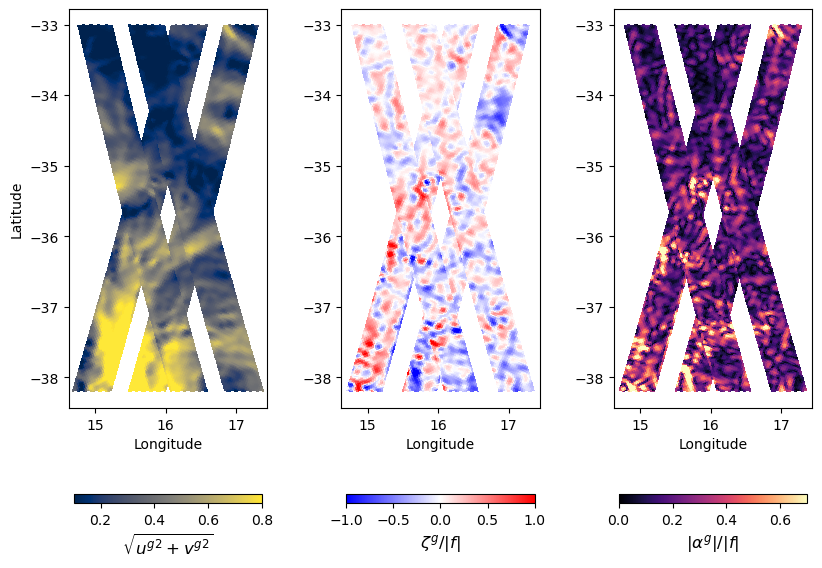

In [33]:
fig, (ax0, ax1,ax2) = plt.subplots(figsize=(9,6), nrows=1, ncols=3)
fig.set_tight_layout(True)
im0 = ax0.pcolormesh(sp1.isel(cycle_num=cnum).longitude, sp1.isel(cycle_num=cnum).latitude,
               sp1.isel(cycle_num=cnum),
               vmin=.1, vmax=.8, cmap="cividis",
               rasterized=True)
ax0.pcolormesh(sp6.isel(cycle_num=cnum).longitude, sp6.isel(cycle_num=cnum).latitude,
               sp6.isel(cycle_num=cnum),
               vmin=.1, vmax=.8, cmap="cividis",
               rasterized=True)
im1 = ax1.pcolormesh(v1.isel(cycle_num=cnum).longitude, v1.isel(cycle_num=cnum).latitude,
               (v1.isel(cycle_num=cnum) 
                / np.abs(gsw.f(v1.isel(cycle_num=cnum).latitude))),
               vmin=-1, vmax=1, cmap="bwr",
               rasterized=True)
ax1.pcolormesh(v6.isel(cycle_num=cnum).longitude, v6.isel(cycle_num=cnum).latitude,
               (v6.isel(cycle_num=cnum) 
                / np.abs(gsw.f(v6.isel(cycle_num=cnum).latitude))),
               vmin=-1, vmax=1, cmap="bwr",
               rasterized=True)
im2 = ax2.pcolormesh(s1.isel(cycle_num=cnum).longitude, s1.isel(cycle_num=cnum).latitude,
               (s1.isel(cycle_num=cnum) 
                / np.abs(gsw.f(s1.isel(cycle_num=cnum).latitude))),
               vmax=.7, vmin=0., cmap="magma",
               rasterized=True)
ax2.pcolormesh(s6.isel(cycle_num=cnum).longitude, s6.isel(cycle_num=cnum).latitude,
               (s6.isel(cycle_num=cnum) 
                / np.abs(gsw.f(s6.isel(cycle_num=cnum).latitude))),
               vmax=.7, vmin=0., cmap="magma",
               rasterized=True)
ax0.set_aspect("equal")
ax1.set_aspect("equal")
ax2.set_aspect("equal")
ax0.set_xlabel(r"Longitude")
ax1.set_xlabel(r"Longitude")
ax0.set_ylabel(r"Latitude")
ax2.set_xlabel(r"Longitude")
cbar0 = fig.colorbar(im0, ax=ax0, orientation="horizontal", shrink=.6)
cbar1 = fig.colorbar(im1, ax=ax1, orientation="horizontal", shrink=.6)
cbar2 = fig.colorbar(im2, ax=ax2, orientation="horizontal", shrink=.6)
cbar0.set_label(r"$\sqrt{{u^g}^2 + {v^g}^2}$", fontsize=12)
cbar1.set_label(r"$\zeta^g/|f|$", fontsize=12)
cbar2.set_label(r"$|\alpha^g|/|f|$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/vort-strain-AR.pdf"))

In [20]:
vbins = np.linspace(-3e0,3e0,60)
sbins = np.linspace(0,3e0,30)
hist_c = xhist((strain / np.abs(f)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort / np.abs(f)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()
hist_r = xhist((str_raw / np.abs(fr)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort_raw / np.abs(fr)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()

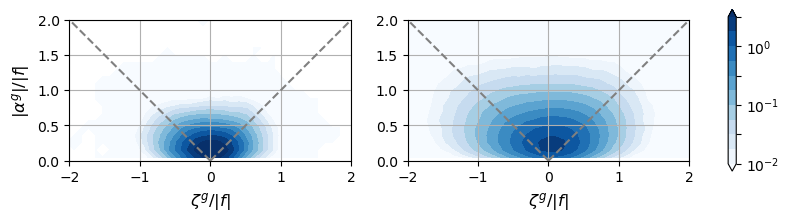

In [21]:
fig, axes = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
# fig.set_tight_layout(True)

im = axes[0].contourf(hist_c.vort_bin,
                 hist_c.strain_bin,
                 hist_c, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )
axes[1].contourf(hist_r.vort_bin,
                 hist_r.strain_bin,
                 hist_r, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )

# for c in im.collections:
#     c.set_rasterized(True)

axes[0].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[0].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')
axes[1].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[1].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')

axes[0].set_xlim([-2,2])
axes[0].set_ylim([0,2])
axes[1].set_xlim([-2,2])
axes[1].set_ylim([0,2])

axes[0].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[1].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[0].set_ylabel(r"$|\alpha^g|/|f|$", fontsize=12)

axes[0].grid(True)
axes[0].set_aspect('equal')
axes[1].grid(True)
axes[1].set_aspect('equal')

# fig.subplots_adjust(hspace=.06, wspace=.12)
# cbar = fig.colorbar(im, orientation='horizontal', ax=axes, shrink=.4, 
#                     ticks=[1e-4,1e-3,1e-2,1e-1,1e0])
cbar = fig.colorbar(im, ax=axes, shrink=.7)
# cbar.set_ticks([1e-2,1e-1,0,1])

plt.savefig(op.join(ddir,"../Figs/vort-strain-ARjointPDF.pdf"))

# Kuroshio

## SWOT

In [4]:
ds04 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/HYCOM/CalVal_pass%03d_v2.0.1.zarr"
                            % 4))
ds04.coords["num_lines"] = ("num_lines",range(len(ds04.num_lines)))
ds04.coords["num_pixels"] = ("num_pixels",range(len(ds04.num_pixels)))

ds19 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/HYCOM/CalVal_pass%03d_v2.0.1.zarr"
                            % 19))
ds19.coords["num_lines"] = ("num_lines",range(len(ds19.num_lines)))
ds19.coords["num_pixels"] = ("num_pixels",range(len(ds19.num_pixels)))
ds04,ds19

(<xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
     longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 571MB dask.array<chunksize=(1, 9860, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels  

In [5]:
maskn4 = xr.DataArray(ds04.latitude.where(ds04.latitude<38.4).to_masked_array().mask,
                     dims=ds04.latitude.dims,
                     coords=ds04.latitude.coords
                    )
masks4 = xr.DataArray(ds04.latitude.where(ds04.latitude>33).to_masked_array().mask,
                     dims=ds04.latitude.dims,
                     coords=ds04.latitude.coords
                    )
xo04 = ds04.where(~maskn4,drop=True).where(~masks4,drop=True)

maskn9 = xr.DataArray(ds19.latitude.where(ds19.latitude<38.4).to_masked_array().mask,
                     dims=ds19.latitude.dims,
                     coords=ds19.latitude.coords
                    )
masks9 = xr.DataArray(ds19.latitude.where(ds19.latitude>33).to_masked_array().mask,
                     dims=ds19.latitude.dims,
                     coords=ds19.latitude.coords
                    )
xo19 = ds19.where(~maskn9,drop=True).where(~masks9,drop=True)
xo04, xo19

(<xarray.Dataset> Size: 19MB
 Dimensions:       (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 3kB 2766 2767 2768 2769 ... 3084 3085 3086
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 177kB 38.65 38.65 ... 32.76
     longitude     (num_lines, num_pixels) float64 177kB 157.4 157.4 ... 157.5
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 19MB dask.array<chunksize=(1, 321, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 19MB
 Dimensions:       (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 3kB 6775 6776 6777 6778 ... 7093 7094 7095
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 6

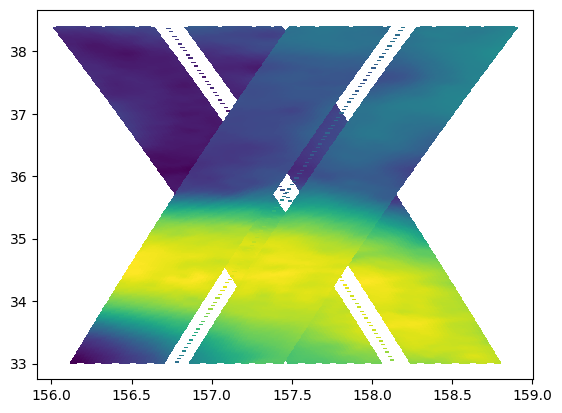

In [26]:
fig, ax = plt.subplots()
ax.pcolormesh(xo04.longitude, xo04.latitude,
              xo04.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )
ax.pcolormesh(xo19.longitude, xo19.latitude,
              xo19.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )

In [6]:
inp = 3

mask04 = xr.DataArray(xo04.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo04.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo04.ssha_detided.isel(cycle_num=0).coords
                    )
mm04 = xr.DataArray(mask04.where(mask04<.5
                              ).to_masked_array().mask,
                   dims=xo04.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo04.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mask19 = xr.DataArray(xo19.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo19.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo19.ssha_detided.isel(cycle_num=0).coords
                    )
mm19 = xr.DataArray(mask19.where(mask19<.5
                              ).to_masked_array().mask,
                   dims=xo19.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo19.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mm04, mm19

(<xarray.DataArray (num_lines: 321, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ..., False, False,  True],
        ...,
        [ True, False, False, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]], shape=(321, 63))
 Coordinates:
   * num_lines   (num_lines) int64 3kB 2766 2767 2768 2769 ... 3084 3085 3086
   * num_pixels  (num_pixels) int64 504B 3 4 5 6 7 8 9 ... 59 60 61 62 63 64 65
     cycle_num   int64 8B 474
     latitude    (num_lines, num_pixels) float64 162kB 38.64 38.64 ... 32.77
     longitude   (num_lines, num_pixels) float64 162kB 157.4 157.4 ... 157.5,
 <xarray.DataArray (num_lines: 321, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        [ True, False, False

In [7]:
low04 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass%03d/SSHa.zarr" 
                               % 4)
                      ).ssha.where(~maskn4,drop=True).where(~masks4,drop=True)
low19 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass%03d/SSHa.zarr" 
                               % 19)
                      ).ssha.where(~maskn9,drop=True).where(~masks9,drop=True)
low04h = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass%03d/HRET/SSHa.zarr" 
                               % 4)
                      ).ssha.where(~maskn4,drop=True).where(~masks4,drop=True)
low19h = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass%03d/HRET/SSHa.zarr" 
                               % 19)
                      ).ssha.where(~maskn9,drop=True).where(~masks9,drop=True)
low04d = xr.open_zarr(op.join(ddir,"SWOT_no_IT/10D_rolling/CalVal_pass%03d_v2.0.1.zarr"
                              % 4)
                     ).ssha_detided.where(~maskn4,drop=True
                                         ).where(~masks4,drop=True
                                                ).isel(num_pixels=slice(inp+1,-inp-1),
                                                       num_lines=slice(1,-1)
                                                      )*1e-2
low19d = xr.open_zarr(op.join(ddir,"SWOT_no_IT/10D_rolling/CalVal_pass%03d_v2.0.1.zarr"
                              % 19)
                     ).ssha_detided.where(~maskn9,drop=True
                                         ).where(~masks9,drop=True
                                                ).isel(num_pixels=slice(inp+1,-inp-1),
                                                       num_lines=slice(1,-1)
                                                      )*1e-2
low04, low19, low04d, low19d

(<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 2767 2768 2769 2770 ... 3083 3084 3085
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 156kB 38.62 38.62 ... 32.79
     longitude   (num_lines, num_pixels) float64 156kB 157.4 157.3 ... 157.5,
 <xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 6776 6777 6778 6779 ... 7092 7093 7094
   * num_pixels  (num_pixels) int64 

In [8]:
r_ref4 = (~mm04).sum() / np.prod(mm04.shape)
r_ref9 = (~mm19).sum() / np.prod(mm19.shape)
r_ref9

<xarray.DataArray ()> Size: 8B
array(0.80724917)
Coordinates:
    cycle_num  int64 8B 474

In [9]:
ageo = (1e-2*ds04.ssha_detided
        - low04
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low04.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r04 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r04 = xr.concat([r04, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref4:
        if ic == 0:
            a04 = ssha
        else:
            try:
                a04 = xr.concat([a04, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a04.coords["cycle_num"] = ("cycle_num",
                           r04.where(r04>0.7*r_ref4, drop=True).cycle_num.data
                          )

dsa04 = a04.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa04.coords["y"] = ("y",range(len(dsa04.y)))
dsa04.coords["x"] = ("x",range(len(dsa04.x)))
if not dsa04.rio.crs:
    dsa04 = dsa04.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa04.ssha.rio.nodata is None:
    dsa04["ssha"] = dsa04.ssha.rio.write_nodata(np.nan)
_a04_exterp = dsa04.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a04_interp = _a04_exterp.interp(cycle_num=ds04.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a04_exterp = _a04_exterp.where(mm04.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds04.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa04.close()

dsg04 = low04.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg04.coords["y"] = ("y",range(len(dsg04.y)))
dsg04.coords["x"] = ("x",range(len(dsg04.x)))
if not dsg04.rio.crs:
    dsg04 = dsg04.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg04.ssha.rio.nodata is None:
    dsg04["ssha"] = dsg04.ssha.rio.write_nodata(np.nan)
_g04_exterp = dsg04.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g04_interp = _g04_exterp.interp(cycle_num=ds04.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g04_exterp = _g04_exterp.where(mm04.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds04.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg04.close()

In [10]:
ageo = (1e-2*ds19.ssha_detided
        - low19
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low19.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r19 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r19 = xr.concat([r19, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref9:
        if ic == 0:
            a19 = ssha
        else:
            try:
                a19 = xr.concat([a19, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a19.coords["cycle_num"] = ("cycle_num",
                           r19.where(r19>0.7*r_ref9, drop=True).cycle_num.data
                          )

dsa19 = a19.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa19.coords["y"] = ("y",range(len(dsa19.y)))
dsa19.coords["x"] = ("x",range(len(dsa19.x)))
if not dsa19.rio.crs:
    dsa19 = dsa19.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa19.ssha.rio.nodata is None:
    dsa19["ssha"] = dsa19.ssha.rio.write_nodata(np.nan)
_a19_exterp = dsa19.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a19_interp = _a19_exterp.interp(cycle_num=ds19.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a19_exterp = _a19_exterp.where(mm19.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds19.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa19.close()

dsg19 = low19.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg19.coords["y"] = ("y",range(len(dsg19.y)))
dsg19.coords["x"] = ("x",range(len(dsg19.x)))
if not dsg19.rio.crs:
    dsg19 = dsg19.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg19.ssha.rio.nodata is None:
    dsg19["ssha"] = dsg19.ssha.rio.write_nodata(np.nan)
_g19_exterp = dsg19.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g19_interp = _g19_exterp.interp(cycle_num=ds19.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g19_exterp = _g19_exterp.where(mm19.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds19.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg19.close()

In [11]:
for cc in low04.cycle_num:
    if cc == low04.cycle_num[0]:
        ar_g4 = g04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a4 = a04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])

        ar_g9 = g19_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a9 = a19_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
    else:
        ar_g4 = xr.concat([ar_g4, 
                          g04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a4 = xr.concat([ar_a4, 
                          a04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_g9 = xr.concat([ar_g9, 
                          g19_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a9 = xr.concat([ar_a9, 
                          a19_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")

ar_g4.coords["time"] = ("time",np.arange(len(ar_g4.time))*24*60.*60)
ar_a4.coords["time"] = ("time",np.arange(len(ar_a4.time))*24*60.*60)
ar_g9.coords["time"] = ("time",np.arange(len(ar_g9.time))*24*60.*60)
ar_a9.coords["time"] = ("time",np.arange(len(ar_a9.time))*24*60.*60)
ar_g4.coords["num_lines"] = ("num_lines",np.arange(len(ar_g4.num_lines))*2e3)
ar_a4.coords["num_lines"] = ("num_lines",np.arange(len(ar_a4.num_lines))*2e3)
ar_g9.coords["num_lines"] = ("num_lines",np.arange(len(ar_g9.num_lines))*2e3)
ar_a9.coords["num_lines"] = ("num_lines",np.arange(len(ar_a9.num_lines))*2e3)

ar_g4, ar_a9

(<xarray.DataArray 'ssha' (time: 105, num_lines: 294, num_pixels: 2)> Size: 494kB
 array([[[-0.08128967, -0.08233746],
         [-0.08241828, -0.08140355],
         [-0.0841654 , -0.08006125],
         ...,
         [ 0.31831134,  0.27476109],
         [ 0.31446492,  0.27228893],
         [ 0.3103847 ,  0.2697889 ]],
 
        [[-0.08770048, -0.08329737],
         [-0.08900584, -0.08143524],
         [-0.09075608, -0.07931117],
         ...,
         [ 0.32754773,  0.27508456],
         [ 0.32390835,  0.27274461],
         [ 0.31993306,  0.27037116]],
 
        [[-0.09231995, -0.08584548],
         [-0.09394   , -0.08327787],
         [-0.09577118, -0.0805897 ],
         ...,
 ...
         ...,
         [ 0.41015999,  0.30598885],
         [ 0.4075253 ,  0.30456748],
         [ 0.40363146,  0.30296421]],
 
        [[-0.06867356,  0.20870402],
         [-0.06900454,  0.21676122],
         [-0.0697737 ,  0.22460936],
         ...,
         [ 0.40633065,  0.30190832],
         [ 0.4039005

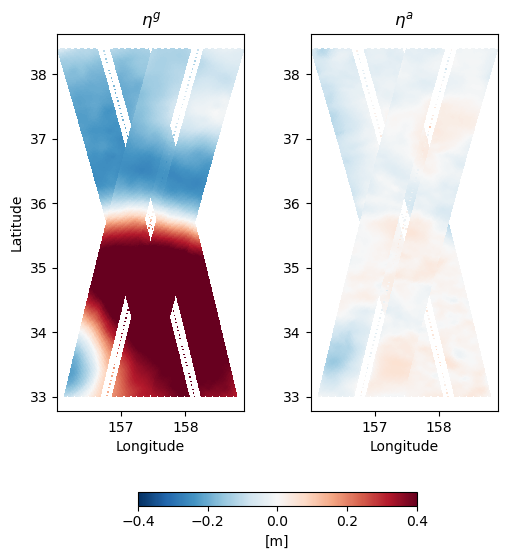

In [170]:
cnum = 20
fig, axes = plt.subplots(figsize=(6,7), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].pcolormesh(g04_exterp.isel(cycle_num=cnum).longitude, g04_exterp.isel(cycle_num=cnum).latitude,
               g04_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[0].pcolormesh(g19_exterp.isel(cycle_num=cnum).longitude, g19_exterp.isel(cycle_num=cnum).latitude,
               g19_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[1].pcolormesh(a04_exterp.isel(cycle_num=cnum).longitude, a04_exterp.isel(cycle_num=cnum).latitude,
               a04_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[1].pcolormesh(a19_exterp.isel(cycle_num=cnum).longitude, a19_exterp.isel(cycle_num=cnum).latitude,
               a19_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[0].set_aspect("equal")
axes[1].set_aspect("equal")
axes[0].set_xlabel(r"Longitude")
axes[0].set_ylabel(r"Latitude")
axes[1].set_xlabel(r"Longitude")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.6)
cbar.set_label(r"[m]")
axes[0].set_title(r"$\eta^g$")
axes[1].set_title(r"$\eta^a$")
plt.savefig(op.join(ddir,"../Figs/ssha-Kx.pdf"))

In [12]:
Fg4 = xrft.power_spectrum(ar_g4.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg4 = xrft.power_spectrum(Fg4.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa4 = xrft.power_spectrum(ar_a4.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa4 = xrft.power_spectrum(Fa4.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fg9 = xrft.power_spectrum(ar_g9.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg9 = xrft.power_spectrum(Fg9.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa9 = xrft.power_spectrum(ar_a9.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa9 = xrft.power_spectrum(Fa9.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa = .5*(Fa4 + Fa9)
Fg = .5*(Fg4 + Fg9)
Fg, Fa

(<xarray.DataArray (freq_time: 105, freq_num_lines: 294)> Size: 247kB
 dask.array<mul, shape=(105, 294), dtype=float64, chunksize=(105, 294), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483,
 <xarray.DataArray (freq_time: 105, freq_num_lines: 294)> Size: 247kB
 dask.array<mul, shape=(105, 294), dtype=float64, chunksize=(105, 294), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483)

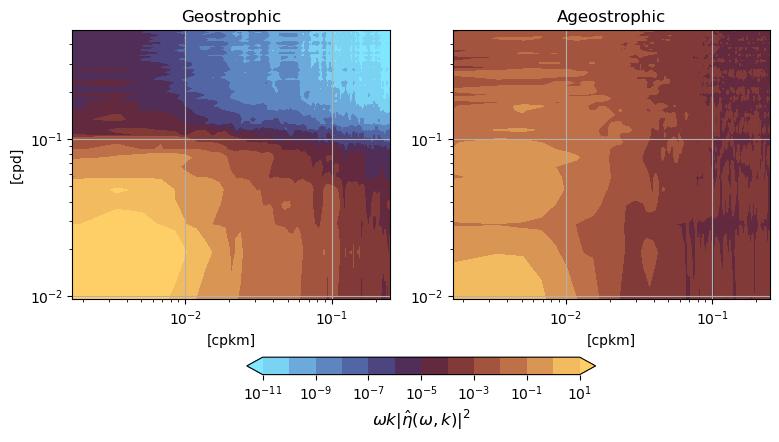

In [32]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fg.freq_num_lines.isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fg.freq_time.isel(freq_time=slice(len(Fg.freq_time)//2,
                                                 None)).values*86400,
               (Fg.freq_num_lines*Fg.freq_time*Fg
               ).isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,None),
                      freq_time=slice(len(Fg.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fa.freq_num_lines.isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fa.freq_time.isel(freq_time=slice(len(Fa.freq_time)//2,
                                                 None)).values*86400,
               (Fa.freq_num_lines*Fa.freq_time*Fa
               ).isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,None),
                      freq_time=slice(len(Fa.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fg.freq_num_lines.where(Fg.freq_num_lines>0.).min()*1e3,
              Fg.freq_num_lines.where(Fg.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fg.freq_time.where(Fg.freq_time>0.).min()*86400,
              Fg.freq_time.where(Fg.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fa.freq_num_lines.where(Fa.freq_num_lines>0.).min()*1e3,
              Fa.freq_num_lines.where(Fa.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fa.freq_time.where(Fa.freq_time>0.).min()*86400,
              Fa.freq_time.where(Fa.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"$\omega k |\hat{\eta}(\omega,k)|^2$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_Kx.pdf"))

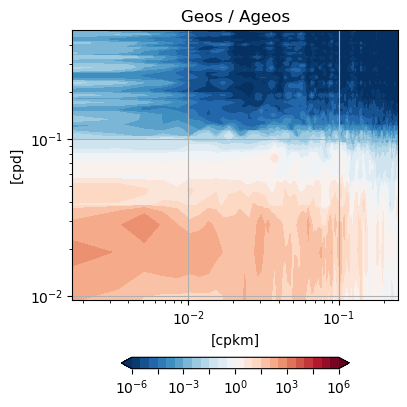

In [172]:
fig, ax = plt.subplots(figsize=(4.2,5))
# fig.set_tight_layout(True)
im = ax.contourf(Fg.freq_num_lines.isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fg.freq_time.isel(freq_time=slice(len(Fg.freq_time)//2,
                                                 None)).values*86400,
               ((Fg.freq_num_lines*Fg.freq_time*Fg
                ).isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,None),
                       freq_time=slice(len(Fg.freq_time)//2,None)
                      ).values.T
                / (Fa.freq_num_lines*Fa.freq_time*Fa
               ).isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,None),
                      freq_time=slice(len(Fa.freq_time)//2,None)
                     ).values.T
               ),
               levels=np.logspace(-6,6,25),
               norm=clr.LogNorm(), cmap="RdBu_r",
               extend="both",
               rasterized=True
              )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([Fg.freq_num_lines.where(Fg.freq_num_lines>0.).min()*1e3,
              Fg.freq_num_lines.where(Fg.freq_num_lines>0.).max()*1e3])
ax.set_ylim([Fg.freq_time.where(Fg.freq_time>0.).min()*86400,
              Fg.freq_time.where(Fg.freq_time>0.).max()*86400])
ax.set_xlabel(r"[cpkm]")
ax.set_ylabel(r"[cpd]")
ax.grid(True)
ax.set_title(r"Geos / Ageos")
cbar = fig.colorbar(im, ax=ax, orientation="horizontal", shrink=.7)
plt.savefig(op.join(ddir,"../Figs/omega-k_Kx-ratio.pdf"))

In [13]:
ageo = (1e-2*ds04.ssha_detided
        - low04d
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low04d.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r04 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r04 = xr.concat([r04, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref4:
        if ic == 0:
            a04 = ssha
        else:
            try:
                a04 = xr.concat([a04, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a04.coords["cycle_num"] = ("cycle_num",
                           r04.where(r04>0.7*r_ref4, drop=True).cycle_num.data
                          )

dsa04 = a04.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa04.coords["y"] = ("y",range(len(dsa04.y)))
dsa04.coords["x"] = ("x",range(len(dsa04.x)))
if not dsa04.rio.crs:
    dsa04 = dsa04.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa04.ssha.rio.nodata is None:
    dsa04["ssha"] = dsa04.ssha.rio.write_nodata(np.nan)
_a04d_exterp = dsa04.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a04d_interp = _a04d_exterp.interp(cycle_num=low04d.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a04d_exterp = _a04d_exterp.where(mm04.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=low04d.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa04.close()

dsg04 = low04d.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg04.coords["y"] = ("y",range(len(dsg04.y)))
dsg04.coords["x"] = ("x",range(len(dsg04.x)))
if not dsg04.rio.crs:
    dsg04 = dsg04.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg04.ssha.rio.nodata is None:
    dsg04["ssha"] = dsg04.ssha.rio.write_nodata(np.nan)
_g04d_exterp = dsg04.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g04d_interp = _g04d_exterp.interp(cycle_num=low04d.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g04d_exterp = _g04d_exterp.where(mm04.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=low04d.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg04.close()

In [14]:
ageo = (1e-2*ds19.ssha_detided
        - low19d
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low19d.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r19 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r19 = xr.concat([r19, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref9:
        if ic == 0:
            a19 = ssha
        else:
            try:
                a19 = xr.concat([a19, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a19.coords["cycle_num"] = ("cycle_num",
                           r19.where(r19>0.7*r_ref9, drop=True).cycle_num.data
                          )

dsa19 = a19.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa19.coords["y"] = ("y",range(len(dsa19.y)))
dsa19.coords["x"] = ("x",range(len(dsa19.x)))
if not dsa19.rio.crs:
    dsa19 = dsa19.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa19.ssha.rio.nodata is None:
    dsa19["ssha"] = dsa19.ssha.rio.write_nodata(np.nan)
_a19d_exterp = dsa19.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a19d_interp = _a19d_exterp.interp(cycle_num=low19d.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a19d_exterp = _a19d_exterp.where(mm19.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=low19d.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa19.close()

dsg19 = low19d.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg19.coords["y"] = ("y",range(len(dsg04.y)))
dsg19.coords["x"] = ("x",range(len(dsg04.x)))
if not dsg19.rio.crs:
    dsg19 = dsg19.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg19.ssha.rio.nodata is None:
    dsg19["ssha"] = dsg19.ssha.rio.write_nodata(np.nan)
_g19d_exterp = dsg19.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g19d_interp = _g19d_exterp.interp(cycle_num=low19d.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g19d_exterp = _g19d_exterp.where(mm19.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=low19d.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg19.close()

In [15]:
for cc in low19d.cycle_num:
    if cc == low19d.cycle_num[0]:
        ar_g4d = g04d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a4d = a04d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])

        ar_g9d = g19d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a9d = a19d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
    else:
        ar_g4d = xr.concat([ar_g4d, 
                          g04d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a4d = xr.concat([ar_a4d, 
                          a04d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_g9d = xr.concat([ar_g9d, 
                          g19d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a9d = xr.concat([ar_a9d, 
                          a19d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")

ar_g4d.coords["time"] = ("time",np.arange(len(ar_g4d.time))*24*60.*60)
ar_a4d.coords["time"] = ("time",np.arange(len(ar_a4d.time))*24*60.*60)
ar_g9d.coords["time"] = ("time",np.arange(len(ar_g9d.time))*24*60.*60)
ar_a9d.coords["time"] = ("time",np.arange(len(ar_a9d.time))*24*60.*60)
ar_g4d.coords["num_lines"] = ("num_lines",np.arange(len(ar_g4d.num_lines))*2e3)
ar_a4d.coords["num_lines"] = ("num_lines",np.arange(len(ar_a4d.num_lines))*2e3)
ar_g9d.coords["num_lines"] = ("num_lines",np.arange(len(ar_g9d.num_lines))*2e3)
ar_a9d.coords["num_lines"] = ("num_lines",np.arange(len(ar_a9d.num_lines))*2e3)

Fg4d = xrft.power_spectrum(ar_g4d.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg4d = xrft.power_spectrum(Fg4d.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa4d = xrft.power_spectrum(ar_a4d.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa4d = xrft.power_spectrum(Fa4d.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fg9d = xrft.power_spectrum(ar_g9d.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg9d = xrft.power_spectrum(Fg9d.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa9d = xrft.power_spectrum(ar_a9d.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa9d = xrft.power_spectrum(Fa9d.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fad = .5*(Fa4d + Fa9d)
Fgd = .5*(Fg4d + Fg9d)
Fgd, Fad

(<xarray.DataArray (freq_time: 96, freq_num_lines: 294)> Size: 226kB
 dask.array<mul, shape=(96, 294), dtype=float64, chunksize=(96, 294), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 768B -5.787e-06 -5.666e-06 ... 5.666e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483,
 <xarray.DataArray (freq_time: 96, freq_num_lines: 294)> Size: 226kB
 dask.array<mul, shape=(96, 294), dtype=float64, chunksize=(96, 294), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 768B -5.787e-06 -5.666e-06 ... 5.666e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483)

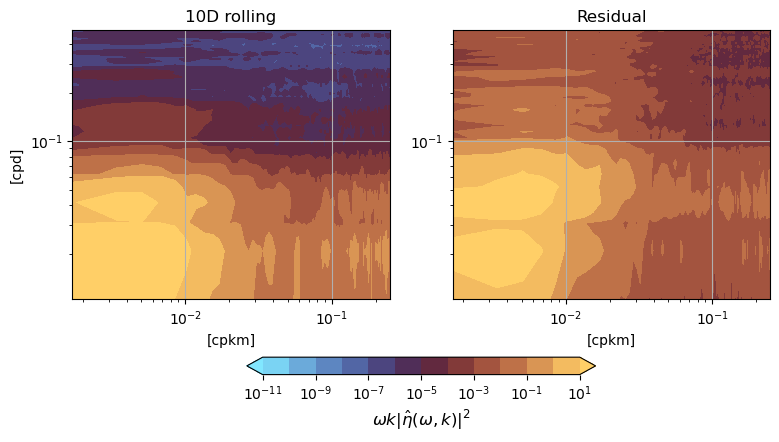

In [25]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fgd.freq_num_lines.isel(freq_num_lines=slice(len(Fgd.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fgd.freq_time.isel(freq_time=slice(len(Fgd.freq_time)//2,
                                                 None)).values*86400,
               (Fgd.freq_num_lines*Fgd.freq_time*Fgd
               ).isel(freq_num_lines=slice(len(Fgd.freq_num_lines)//2,None),
                      freq_time=slice(len(Fgd.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fad.freq_num_lines.isel(freq_num_lines=slice(len(Fad.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fad.freq_time.isel(freq_time=slice(len(Fad.freq_time)//2,
                                                 None)).values*86400,
               (Fad.freq_num_lines*Fad.freq_time*Fad
               ).isel(freq_num_lines=slice(len(Fad.freq_num_lines)//2,None),
                      freq_time=slice(len(Fad.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fgd.freq_num_lines.where(Fgd.freq_num_lines>0.).min()*1e3,
              Fgd.freq_num_lines.where(Fgd.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fgd.freq_time.where(Fgd.freq_time>0.).min()*86400,
              Fgd.freq_time.where(Fgd.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fad.freq_num_lines.where(Fad.freq_num_lines>0.).min()*1e3,
              Fad.freq_num_lines.where(Fad.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fad.freq_time.where(Fad.freq_time>0.).min()*86400,
              Fad.freq_time.where(Fad.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"10D rolling")
axes[1].set_title(r"Residual")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"$\omega k |\hat{\eta}(\omega,k)|^2$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_Kx_10D.pdf"))

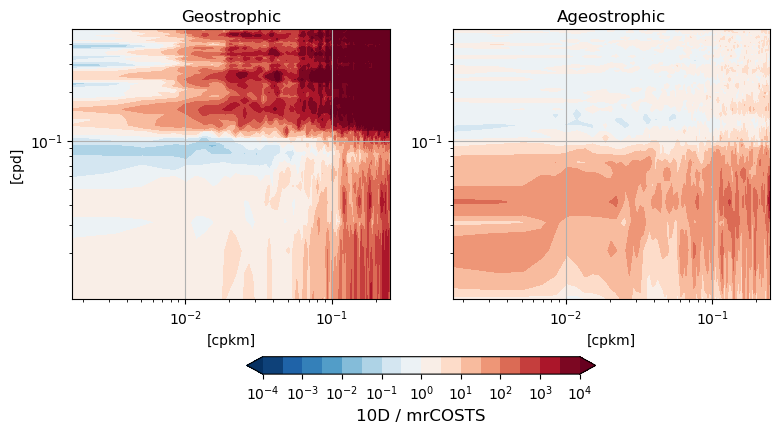

In [16]:
# Fgd, Fg.interp(freq_num_lines=Fgd.freq_num_lines,freq_time=Fgd.freq_time)
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fgd.freq_num_lines.isel(freq_num_lines=slice(len(Fgd.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fgd.freq_time.isel(freq_time=slice(len(Fgd.freq_time)//2,
                                                 None)).values*86400,
               (Fgd/Fg.interp(freq_time=Fgd.freq_time,
                              freq_num_lines=Fgd.freq_num_lines).data
               ).isel(freq_num_lines=slice(len(Fgd.freq_num_lines)//2,None),
                      freq_time=slice(len(Fgd.freq_time)//2,None)
                     ).values,
               levels=np.logspace(-4,4,17),
               norm=clr.LogNorm(), cmap="RdBu_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fad.freq_num_lines.isel(freq_num_lines=slice(len(Fad.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fad.freq_time.isel(freq_time=slice(len(Fad.freq_time)//2,
                                                 None)).values*86400,
               (Fad/Fa.interp(freq_time=Fgd.freq_time,
                              freq_num_lines=Fgd.freq_num_lines).data
               ).isel(freq_num_lines=slice(len(Fad.freq_num_lines)//2,None),
                      freq_time=slice(len(Fad.freq_time)//2,None)
                     ).values,
               levels=np.logspace(-4,4,17),
               norm=clr.LogNorm(), cmap="RdBu_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fgd.freq_num_lines.where(Fgd.freq_num_lines>0.).min()*1e3,
              Fgd.freq_num_lines.where(Fgd.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fgd.freq_time.where(Fgd.freq_time>0.).min()*86400,
              Fgd.freq_time.where(Fgd.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fad.freq_num_lines.where(Fad.freq_num_lines>0.).min()*1e3,
              Fad.freq_num_lines.where(Fad.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fad.freq_time.where(Fad.freq_time>0.).min()*86400,
              Fad.freq_time.where(Fad.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"10D / mrCOSTS", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_Kx_10Dratio.pdf"))

In [17]:
ageo = (1e-2*ds04.ssha_detided
        - low04h
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low04h.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r04 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r04 = xr.concat([r04, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref4:
        if ic == 0:
            a04 = ssha
        else:
            try:
                a04 = xr.concat([a04, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a04.coords["cycle_num"] = ("cycle_num",
                           r04.where(r04>0.7*r_ref4, drop=True).cycle_num.data
                          )

dsa04 = a04.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa04.coords["y"] = ("y",range(len(dsa04.y)))
dsa04.coords["x"] = ("x",range(len(dsa04.x)))
if not dsa04.rio.crs:
    dsa04 = dsa04.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa04.ssha.rio.nodata is None:
    dsa04["ssha"] = dsa04.ssha.rio.write_nodata(np.nan)
_a04h_exterp = dsa04.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a04h_interp = _a04h_exterp.interp(cycle_num=low04h.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a04h_exterp = _a04h_exterp.where(mm04.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=low04h.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa04.close()

dsg04 = low04h.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg04.coords["y"] = ("y",range(len(dsg04.y)))
dsg04.coords["x"] = ("x",range(len(dsg04.x)))
if not dsg04.rio.crs:
    dsg04 = dsg04.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg04.ssha.rio.nodata is None:
    dsg04["ssha"] = dsg04.ssha.rio.write_nodata(np.nan)
_g04h_exterp = dsg04.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g04h_interp = _g04h_exterp.interp(cycle_num=low04h.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g04h_exterp = _g04h_exterp.where(mm04.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=low04h.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg04.close()

In [18]:
ageo = (1e-2*ds19.ssha_detided
        - low19h
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low19h.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r19 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r19 = xr.concat([r19, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref9:
        if ic == 0:
            a19 = ssha
        else:
            try:
                a19 = xr.concat([a19, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a19.coords["cycle_num"] = ("cycle_num",
                           r19.where(r19>0.7*r_ref9, drop=True).cycle_num.data
                          )

dsa19 = a19.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa19.coords["y"] = ("y",range(len(dsa19.y)))
dsa19.coords["x"] = ("x",range(len(dsa19.x)))
if not dsa19.rio.crs:
    dsa19 = dsa19.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa19.ssha.rio.nodata is None:
    dsa19["ssha"] = dsa19.ssha.rio.write_nodata(np.nan)
_a19h_exterp = dsa19.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a19h_interp = _a19h_exterp.interp(cycle_num=low19h.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a19h_exterp = _a19h_exterp.where(mm19.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=low19h.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa19.close()

dsg19 = low19h.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg19.coords["y"] = ("y",range(len(dsg04.y)))
dsg19.coords["x"] = ("x",range(len(dsg04.x)))
if not dsg19.rio.crs:
    dsg19 = dsg19.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg19.ssha.rio.nodata is None:
    dsg19["ssha"] = dsg19.ssha.rio.write_nodata(np.nan)
_g19h_exterp = dsg19.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g19h_interp = _g19h_exterp.interp(cycle_num=low19h.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g19h_exterp = _g19h_exterp.where(mm19.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=low19h.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg19.close()

In [19]:
for cc in low19h.cycle_num:
    if cc == low19h.cycle_num[0]:
        ar_g4h = g04h_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a4h = a04h_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])

        ar_g9h = g19h_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a9h = a19h_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
    else:
        ar_g4h = xr.concat([ar_g4h, 
                          g04h_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a4h = xr.concat([ar_a4h, 
                          a04h_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_g9h = xr.concat([ar_g9h, 
                          g19h_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a9h = xr.concat([ar_a9h, 
                          a19h_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")

ar_g4h.coords["time"] = ("time",np.arange(len(ar_g4h.time))*24*60.*60)
ar_a4h.coords["time"] = ("time",np.arange(len(ar_a4h.time))*24*60.*60)
ar_g9h.coords["time"] = ("time",np.arange(len(ar_g9h.time))*24*60.*60)
ar_a9h.coords["time"] = ("time",np.arange(len(ar_a9h.time))*24*60.*60)
ar_g4h.coords["num_lines"] = ("num_lines",np.arange(len(ar_g4h.num_lines))*2e3)
ar_a4h.coords["num_lines"] = ("num_lines",np.arange(len(ar_a4h.num_lines))*2e3)
ar_g9h.coords["num_lines"] = ("num_lines",np.arange(len(ar_g9h.num_lines))*2e3)
ar_a9h.coords["num_lines"] = ("num_lines",np.arange(len(ar_a9h.num_lines))*2e3)

Fg4h = xrft.power_spectrum(ar_g4h.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg4h = xrft.power_spectrum(Fg4h.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa4h = xrft.power_spectrum(ar_a4h.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa4h = xrft.power_spectrum(Fa4h.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fg9h = xrft.power_spectrum(ar_g9h.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg9h = xrft.power_spectrum(Fg9h.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa9h = xrft.power_spectrum(ar_a9h.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa9h = xrft.power_spectrum(Fa9h.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fah = .5*(Fa4h + Fa9h)
Fgh = .5*(Fg4h + Fg9h)
Fgh, Fah

(<xarray.DataArray (freq_time: 105, freq_num_lines: 294)> Size: 247kB
 dask.array<mul, shape=(105, 294), dtype=float64, chunksize=(105, 294), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483,
 <xarray.DataArray (freq_time: 105, freq_num_lines: 294)> Size: 247kB
 dask.array<mul, shape=(105, 294), dtype=float64, chunksize=(105, 294), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483)

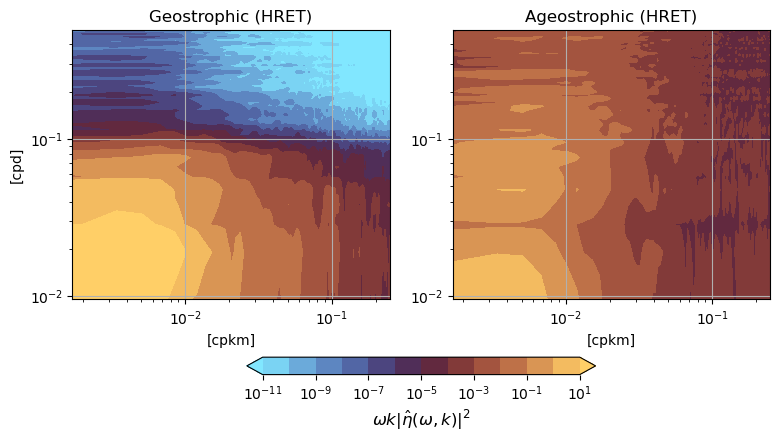

In [24]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fgh.freq_num_lines.isel(freq_num_lines=slice(len(Fgh.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fgh.freq_time.isel(freq_time=slice(len(Fgh.freq_time)//2,
                                                 None)).values*86400,
               (Fgh.freq_num_lines*Fgh.freq_time*Fgh
               ).isel(freq_num_lines=slice(len(Fgh.freq_num_lines)//2,None),
                      freq_time=slice(len(Fgh.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fah.freq_num_lines.isel(freq_num_lines=slice(len(Fah.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fah.freq_time.isel(freq_time=slice(len(Fah.freq_time)//2,
                                                 None)).values*86400,
               (Fah.freq_num_lines*Fah.freq_time*Fah
               ).isel(freq_num_lines=slice(len(Fah.freq_num_lines)//2,None),
                      freq_time=slice(len(Fah.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fgh.freq_num_lines.where(Fgh.freq_num_lines>0.).min()*1e3,
              Fgh.freq_num_lines.where(Fgh.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fgh.freq_time.where(Fgh.freq_time>0.).min()*86400,
              Fgh.freq_time.where(Fgh.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fah.freq_num_lines.where(Fah.freq_num_lines>0.).min()*1e3,
              Fah.freq_num_lines.where(Fah.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fah.freq_time.where(Fah.freq_time>0.).min()*86400,
              Fah.freq_time.where(Fah.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic (HRET)")
axes[1].set_title(r"Ageostrophic (HRET)")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"$\omega k |\hat{\eta}(\omega,k)|^2$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_Kx_HRET.pdf"))

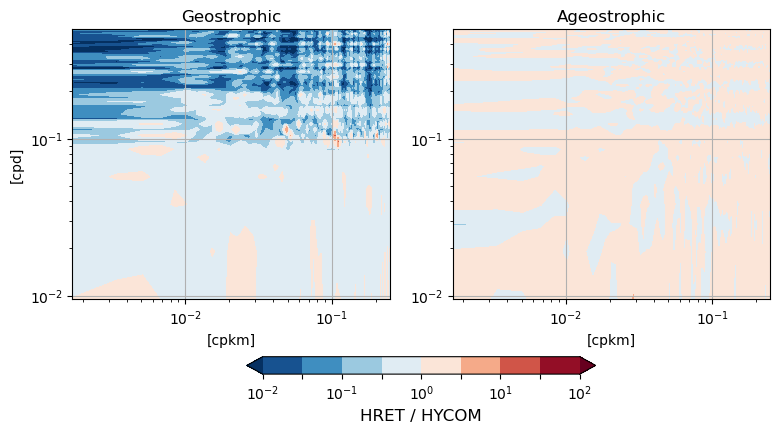

In [20]:
# Fgd, Fg.interp(freq_num_lines=Fgd.freq_num_lines,freq_time=Fgd.freq_time)
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fgh.freq_num_lines.isel(freq_num_lines=slice(len(Fgh.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fgh.freq_time.isel(freq_time=slice(len(Fgh.freq_time)//2,
                                                 None)).values*86400,
               (Fgh/Fg.interp(freq_time=Fgh.freq_time,
                              freq_num_lines=Fgh.freq_num_lines).data
               ).isel(freq_num_lines=slice(len(Fgh.freq_num_lines)//2,None),
                      freq_time=slice(len(Fgh.freq_time)//2,None)
                     ).values,
               levels=np.logspace(-2,2,9),
               norm=clr.LogNorm(), cmap="RdBu_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fah.freq_num_lines.isel(freq_num_lines=slice(len(Fah.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fah.freq_time.isel(freq_time=slice(len(Fah.freq_time)//2,
                                                 None)).values*86400,
               (Fah/Fa.interp(freq_time=Fgh.freq_time,
                              freq_num_lines=Fgh.freq_num_lines).data
               ).isel(freq_num_lines=slice(len(Fah.freq_num_lines)//2,None),
                      freq_time=slice(len(Fah.freq_time)//2,None)
                     ).values,
               levels=np.logspace(-2,2,9),
               norm=clr.LogNorm(), cmap="RdBu_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fgh.freq_num_lines.where(Fgh.freq_num_lines>0.).min()*1e3,
              Fgh.freq_num_lines.where(Fgh.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fgh.freq_time.where(Fgh.freq_time>0.).min()*86400,
              Fgh.freq_time.where(Fgh.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fah.freq_num_lines.where(Fah.freq_num_lines>0.).min()*1e3,
              Fah.freq_num_lines.where(Fah.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fah.freq_time.where(Fah.freq_time>0.).min()*86400,
              Fah.freq_time.where(Fah.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
# cbar.set_ticks([.5,1,2])
cbar.set_label(r"HRET / HYCOM", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_Kx_HRETratio.pdf"))

In [44]:
dsv4 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass004/SSVs_SwotDiag.zarr"))
dsv9 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass019/SSVs_SwotDiag.zarr"))
dsv4r = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass004/SSVs_rawSwotDiag.zarr"))
dsv9r = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass019/SSVs_rawSwotDiag.zarr"))
dsv4, dsv9

(<xarray.Dataset> Size: 3GB
 Dimensions:     (cycle_num: 105, num_lines: 9310, num_pixels: 61)
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
     longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
 Data variables:
     strain      (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     ucg         (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     ug          (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     vcg         (cycle_num, num_lines, num_pixels) float64 477MB das

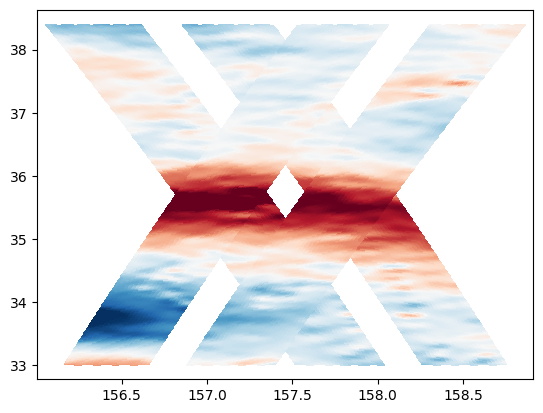

In [45]:
# u4 = dsv4.ucg.where(~maskn4,drop=True).where(~masks4,drop=True)
# u9 = dsv9.ucg.where(~maskn9,drop=True).where(~masks9,drop=True)
u4 = dsv4.ug.where(~maskn4,drop=True).where(~masks4,drop=True)
u9 = dsv9.ug.where(~maskn9,drop=True).where(~masks9,drop=True)

fig, ax = plt.subplots()
ax.pcolormesh(u4.longitude, u4.latitude,
              u4.isel(cycle_num=11),
              vmax=.8, vmin=-.8, cmap="RdBu_r",
              rasterized=True
             )
ax.pcolormesh(u9.longitude, u9.latitude,
              u9.isel(cycle_num=11),
              vmax=.8, vmin=-.8, cmap="RdBu_r",
              rasterized=True
             )

In [75]:
# sp4 = np.sqrt(dsv4.ucg**2 + dsv4.vcg**2).where(~maskn4,drop=True).where(~masks4,drop=True)
# sp9 = np.sqrt(dsv9.ucg**2 + dsv9.vcg**2).where(~maskn9,drop=True).where(~masks9,drop=True)
sp4 = np.sqrt(dsv4.ug**2 + dsv4.vg**2).where(~maskn4,drop=True).where(~masks4,drop=True)
sp9 = np.sqrt(dsv9.ug**2 + dsv9.vg**2).where(~maskn9,drop=True).where(~masks9,drop=True)
v4 = dsv4.vort.where(~maskn4,drop=True).where(~masks4,drop=True)
s4 = dsv4.strain.where(~maskn4,drop=True).where(~masks4,drop=True)
v9 = dsv9.vort.where(~maskn9,drop=True).where(~masks9,drop=True)
s9 = dsv9.strain.where(~maskn9,drop=True).where(~masks9,drop=True)
v4r = dsv4r.vort.where(~maskn4,drop=True
                      ).where(~masks4,drop=True
                             ).isel(num_pixels=slice(4,-4),
                                    num_lines=slice(1,-1)
                                   ).dropna("cycle_num", how="all")
s4r = dsv4r.strain.where(~maskn4,drop=True
                        ).where(~masks4,drop=True
                               ).isel(num_pixels=slice(4,-4),
                                      num_lines=slice(1,-1)
                                     ).dropna("cycle_num", how="all")
v9r = dsv9r.vort.where(~maskn9,drop=True
                      ).where(~masks9,drop=True
                             ).isel(num_pixels=slice(4,-4),
                                    num_lines=slice(1,-1)
                                   ).dropna("cycle_num", how="all")
s9r = dsv9r.strain.where(~maskn9,drop=True
                        ).where(~masks9,drop=True
                               ).isel(num_pixels=slice(4,-4),
                                      num_lines=slice(1,-1)
                                     ).dropna("cycle_num", how="all")
v4, v4r

(<xarray.DataArray 'vort' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 2767 2768 2769 2770 ... 3083 3084 3085
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 156kB 38.62 38.62 ... 32.79
     longitude   (num_lines, num_pixels) float64 156kB 157.4 157.3 ... 157.5,
 <xarray.DataArray 'vort' (cycle_num: 94, num_lines: 319, num_pixels: 61)> Size: 15MB
 dask.array<getitem, shape=(94, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 752B 475 478 479 480 481 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 2767 2768 2769 2770 ... 3083 3084 3085
   * num_pixels  (num_pixels) int64 

In [76]:
vort = xr.concat([v4.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  v9.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
strain = xr.concat([s4.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  s9.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
f = gsw.f(vort.latitude)
vort_raw = xr.concat([v4r.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  v9r.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
str_raw = xr.concat([s4r.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  s9r.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
fr = gsw.f(vort_raw.latitude)
vort, strain, f

(<xarray.DataArray 'vort' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 dask.array<concatenate, shape=(210, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (cycle_num, num_lines, num_pixels) float64 33MB 38.62 ... 38.38
     longitude  (cycle_num, num_lines, num_pixels) float64 33MB 157.4 ... 158.9
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'strain' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 dask.array<concatenate, shape=(210, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (cycle_num, num_lines, num_pixels) float64 33MB 38.62 ... 38.38
     longitude  (cycle_num, num_lines, num_pixels) float64 33MB 157.4 ... 158.9
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'latitude' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 array([[[9.10315109e-05, 9.1

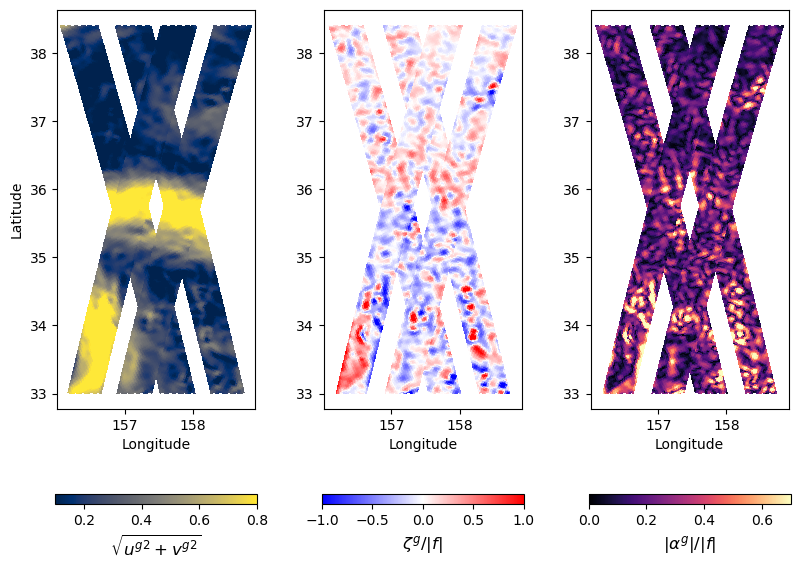

In [77]:
fig, (ax0, ax1,ax2) = plt.subplots(figsize=(9,6), nrows=1, ncols=3)
fig.set_tight_layout(True)
im0 = ax0.pcolormesh(sp4.isel(cycle_num=cnum).longitude, sp4.isel(cycle_num=cnum).latitude,
               sp4.isel(cycle_num=cnum),
               vmin=.1, vmax=.8, cmap="cividis",
               rasterized=True)
ax0.pcolormesh(sp9.isel(cycle_num=cnum).longitude, sp9.isel(cycle_num=cnum).latitude,
               sp9.isel(cycle_num=cnum),
               vmin=.1, vmax=.8, cmap="cividis",
               rasterized=True)
im1 = ax1.pcolormesh(v4.isel(cycle_num=cnum).longitude, v4.isel(cycle_num=cnum).latitude,
               (v4.isel(cycle_num=cnum) 
                / np.abs(gsw.f(v4.isel(cycle_num=cnum).latitude))),
               vmin=-1, vmax=1, cmap="bwr",
               rasterized=True)
ax1.pcolormesh(v9.isel(cycle_num=cnum).longitude, v9.isel(cycle_num=cnum).latitude,
               (v9.isel(cycle_num=cnum) 
                / np.abs(gsw.f(v9.isel(cycle_num=cnum).latitude))),
               vmin=-1, vmax=1, cmap="bwr",
               rasterized=True)
im2 = ax2.pcolormesh(s4.isel(cycle_num=cnum).longitude, s4.isel(cycle_num=cnum).latitude,
               (s4.isel(cycle_num=cnum) 
                / np.abs(gsw.f(s4.isel(cycle_num=cnum).latitude))),
               vmax=.7, vmin=0., cmap="magma",
               rasterized=True)
ax2.pcolormesh(s9.isel(cycle_num=cnum).longitude, s9.isel(cycle_num=cnum).latitude,
               (s9.isel(cycle_num=cnum) 
                / np.abs(gsw.f(s9.isel(cycle_num=cnum).latitude))),
               vmax=.7, vmin=0., cmap="magma",
               rasterized=True)
ax0.set_aspect("equal")
ax1.set_aspect("equal")
ax2.set_aspect("equal")
ax0.set_xlabel(r"Longitude")
ax1.set_xlabel(r"Longitude")
ax0.set_ylabel(r"Latitude")
ax2.set_xlabel(r"Longitude")
cbar0 = fig.colorbar(im0, ax=ax0, orientation="horizontal", shrink=.6)
cbar1 = fig.colorbar(im1, ax=ax1, orientation="horizontal", shrink=.6)
cbar2 = fig.colorbar(im2, ax=ax2, orientation="horizontal", shrink=.6)
cbar0.set_label(r"$\sqrt{{u^g}^2 + {v^g}^2}$", fontsize=12)
cbar1.set_label(r"$\zeta^g/|f|$", fontsize=12)
cbar2.set_label(r"$|\alpha^g|/|f|$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/vort-strain-Kx.pdf"))

In [37]:
vbins = np.linspace(-3e0,3e0,60)
sbins = np.linspace(0,3e0,30)
hist_c = xhist((strain / np.abs(f)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort / np.abs(f)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()
hist_r = xhist((str_raw / np.abs(fr)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort_raw / np.abs(fr)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()

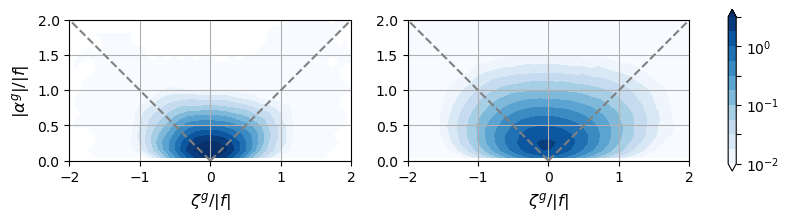

In [38]:
fig, axes = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
# fig.set_tight_layout(True)

im = axes[0].contourf(hist_c.vort_bin,
                 hist_c.strain_bin,
                 hist_c, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )
axes[1].contourf(hist_r.vort_bin,
                 hist_r.strain_bin,
                 hist_r, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )

# for c in im.collections:
#     c.set_rasterized(True)

axes[0].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[0].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')
axes[1].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[1].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')

axes[0].set_xlim([-2,2])
axes[0].set_ylim([0,2])
axes[1].set_xlim([-2,2])
axes[1].set_ylim([0,2])

axes[0].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[1].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[0].set_ylabel(r"$|\alpha^g|/|f|$", fontsize=12)

axes[0].grid(True)
axes[0].set_aspect('equal')
axes[1].grid(True)
axes[1].set_aspect('equal')

# fig.subplots_adjust(hspace=.06, wspace=.12)
# cbar = fig.colorbar(im, orientation='horizontal', ax=axes, shrink=.4, 
#                     ticks=[1e-4,1e-3,1e-2,1e-1,1e0])
cbar = fig.colorbar(im, ax=axes, shrink=.7)
# cbar.set_ticks([1e-2,1e-1,0,1])

plt.savefig(op.join(ddir,"../Figs/vort-strain-KxjointPDF.pdf"))

## HYCOM

In [4]:
reg = "Kx"
ds04t = xr.open_zarr(op.join(ddir, "tssh_swot1day/Pass%03d/"
                             % 4)
                     + reg + "/ssh-total_rawgrid.zarr"
                    )
maskn = xr.DataArray(ds04t.latitude.where(ds04t.latitude<38.4).to_masked_array().mask,
                     dims=ds04t.latitude.dims,
                     coords=ds04t.latitude.coords
                    )
ds04t = ds04t.where(~maskn,drop=True)
masks = xr.DataArray(ds04t.latitude.where(ds04t.latitude>33.).to_masked_array().mask,
                     dims=ds04t.latitude.dims,
                     coords=ds04t.latitude.coords
                    )

ds04t = ds04t.where(~masks,drop=True)

mm04t = xr.DataArray(ds04t.ssha.mean(axis=0).to_masked_array().mask, 
                     dims=ds04t.ssha.isel(cycle_num=0).dims, 
                     coords=ds04t.ssha.isel(cycle_num=0).coords
                    )

ds04d = xr.open_zarr(op.join(ddir, "tssh_swot1day/Pass%03d/"
                             % 4)
                     + reg + "/ssh-detided_rawgrid.zarr"
                    )
maskn = xr.DataArray(ds04d.latitude.where(ds04d.latitude<38.4).to_masked_array().mask,
                     dims=ds04d.latitude.dims,
                     coords=ds04d.latitude.coords
                    )
ds04d = ds04d.where(~maskn,drop=True)
masks = xr.DataArray(ds04d.latitude.where(ds04d.latitude>33.).to_masked_array().mask,
                     dims=ds04d.latitude.dims,
                     coords=ds04d.latitude.coords
                    )

ds04d = ds04d.where(~masks,drop=True)

mm04d = xr.DataArray(ds04d.ssha.mean(axis=0).to_masked_array().mask, 
                     dims=ds04d.ssha.isel(cycle_num=0).dims, 
                     coords=ds04d.ssha.isel(cycle_num=0).coords
                    )
ds04t, ds04d

(<xarray.Dataset> Size: 19MB
 Dimensions:     (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 2766 2767 2768 2769 ... 3084 3085 3086
   * num_pixels  (num_pixels) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
     latitude    (num_lines, num_pixels) float64 177kB dask.array<chunksize=(321, 69), meta=np.ndarray>
     longitude   (num_lines, num_pixels) float64 177kB dask.array<chunksize=(321, 69), meta=np.ndarray>
     pass_num    int64 8B 4
 Data variables:
     ssha        (cycle_num, num_lines, num_pixels) float64 19MB dask.array<chunksize=(14, 321, 18), meta=np.ndarray>,
 <xarray.Dataset> Size: 19MB
 Dimensions:     (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 2766 2767 2768 2769 ... 3084 3085 3086
   * num_pix

In [5]:
ds19t = xr.open_zarr(op.join(ddir, "tssh_swot1day/Pass%03d/"
                             % 19)
                     + reg + "/ssh-total_rawgrid.zarr"
                    )
maskn = xr.DataArray(ds19t.latitude.where(ds19t.latitude<38.4).to_masked_array().mask,
                     dims=ds19t.latitude.dims,
                     coords=ds19t.latitude.coords
                    )
ds19t = ds19t.where(~maskn,drop=True)
masks = xr.DataArray(ds19t.latitude.where(ds19t.latitude>33.).to_masked_array().mask,
                     dims=ds19t.latitude.dims,
                     coords=ds19t.latitude.coords
                    )

ds19t = ds19t.where(~masks,drop=True)

mm19t = xr.DataArray(ds19t.ssha.mean(axis=0).to_masked_array().mask, 
                     dims=ds19t.ssha.isel(cycle_num=0).dims, 
                     coords=ds19t.ssha.isel(cycle_num=0).coords
                    )

ds19d = xr.open_zarr(op.join(ddir, "tssh_swot1day/Pass%03d/"
                             % 19)
                     + reg + "/ssh-detided_rawgrid.zarr"
                    )
maskn = xr.DataArray(ds19d.latitude.where(ds19d.latitude<38.4).to_masked_array().mask,
                     dims=ds19d.latitude.dims,
                     coords=ds19d.latitude.coords
                    )
ds19d = ds19d.where(~maskn,drop=True)
masks = xr.DataArray(ds19d.latitude.where(ds19d.latitude>33.).to_masked_array().mask,
                     dims=ds19d.latitude.dims,
                     coords=ds19d.latitude.coords
                    )

ds19d = ds19d.where(~masks,drop=True)

mm19d = xr.DataArray(ds19d.ssha.mean(axis=0).to_masked_array().mask, 
                     dims=ds19d.ssha.isel(cycle_num=0).dims, 
                     coords=ds19d.ssha.isel(cycle_num=0).coords
                    )
ds19t, ds19d

(<xarray.Dataset> Size: 19MB
 Dimensions:     (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 6775 6776 6777 6778 ... 7093 7094 7095
   * num_pixels  (num_pixels) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
     latitude    (num_lines, num_pixels) float64 177kB dask.array<chunksize=(321, 69), meta=np.ndarray>
     longitude   (num_lines, num_pixels) float64 177kB dask.array<chunksize=(321, 69), meta=np.ndarray>
     pass_num    int64 8B 19
 Data variables:
     ssha        (cycle_num, num_lines, num_pixels) float64 19MB dask.array<chunksize=(14, 321, 18), meta=np.ndarray>,
 <xarray.Dataset> Size: 19MB
 Dimensions:     (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 6775 6776 6777 6778 ... 7093 7094 7095
   * num_pi

In [6]:
low04t = xr.open_zarr(op.join(ddir,"tssh_swot1day/geos/Pass%03d/%2s/SSHa-total.zarr" 
                              % (4,reg))
                     )
maskn = xr.DataArray(low04t.latitude.where(low04t.latitude<38.4).to_masked_array().mask,
                     dims=low04t.latitude.dims,
                     coords=low04t.latitude.coords
                    )
low04t = low04t.where(~maskn,drop=True)
masks = xr.DataArray(low04t.latitude.where(low04t.latitude>33.).to_masked_array().mask,
                     dims=low04t.latitude.dims,
                     coords=low04t.latitude.coords
                    )

low04t = low04t.where(~masks,drop=True).ssha  

low04d = xr.open_zarr(op.join(ddir,"tssh_swot1day/geos/Pass%03d/%2s/SSHa-detided.zarr" 
                              % (4,reg))
                     )
maskn = xr.DataArray(low04d.latitude.where(low04d.latitude<38.4).to_masked_array().mask,
                     dims=low04d.latitude.dims,
                     coords=low04d.latitude.coords
                    )
low04d = low04d.where(~maskn,drop=True)
masks = xr.DataArray(low04d.latitude.where(low04d.latitude>33.).to_masked_array().mask,
                     dims=low04d.latitude.dims,
                     coords=low04d.latitude.coords
                    )

low04d = low04d.where(~masks,drop=True).ssha
low04d

<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 321, num_pixels: 69)> Size: 19MB
dask.array<where, shape=(105, 321, 69), dtype=float64, chunksize=(1, 321, 69), chunktype=numpy.ndarray>
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 3kB 2766 2767 2768 2769 ... 3084 3085 3086
  * num_pixels  (num_pixels) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
    latitude    (num_lines, num_pixels) float64 177kB dask.array<chunksize=(321, 69), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 177kB dask.array<chunksize=(321, 69), meta=np.ndarray>
    pass_num    int64 8B 4

In [7]:
low19t = xr.open_zarr(op.join(ddir,"tssh_swot1day/geos/Pass%03d/%2s/SSHa-total.zarr" 
                              % (19,reg))
                     )
maskn = xr.DataArray(low19t.latitude.where(low19t.latitude<38.4).to_masked_array().mask,
                     dims=low19t.latitude.dims,
                     coords=low19t.latitude.coords
                    )
low19t = low19t.where(~maskn,drop=True)
masks = xr.DataArray(low19t.latitude.where(low19t.latitude>33.).to_masked_array().mask,
                     dims=low19t.latitude.dims,
                     coords=low19t.latitude.coords
                    )

low19t = low19t.where(~masks,drop=True).ssha

low19d = xr.open_zarr(op.join(ddir,"tssh_swot1day/geos/Pass%03d/%2s/SSHa-detided.zarr" 
                              % (19,reg))
                     )
maskn = xr.DataArray(low19d.latitude.where(low19d.latitude<38.4).to_masked_array().mask,
                     dims=low19d.latitude.dims,
                     coords=low19d.latitude.coords
                    )
low19d = low19d.where(~maskn,drop=True)
masks = xr.DataArray(low19d.latitude.where(low19d.latitude>33.).to_masked_array().mask,
                     dims=low19d.latitude.dims,
                     coords=low19d.latitude.coords
                    )

low19d = low19d.where(~masks,drop=True).ssha
low19d

<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 321, num_pixels: 69)> Size: 19MB
dask.array<where, shape=(105, 321, 69), dtype=float64, chunksize=(1, 321, 69), chunktype=numpy.ndarray>
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 3kB 6775 6776 6777 6778 ... 7093 7094 7095
  * num_pixels  (num_pixels) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
    latitude    (num_lines, num_pixels) float64 177kB dask.array<chunksize=(321, 69), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 177kB dask.array<chunksize=(321, 69), meta=np.ndarray>
    pass_num    int64 8B 19

In [8]:
ageo = (1e-2*ds04t.ssha
        - low04t
       )

dsa04 = ageo.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa04.coords["y"] = ("y",range(len(dsa04.y)))
dsa04.coords["x"] = ("x",range(len(dsa04.x)))
if not dsa04.rio.crs:
    dsa04 = dsa04.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa04.ssha.rio.nodata is None:
    dsa04["ssha"] = dsa04.ssha.rio.write_nodata(np.nan)
_a04t_exterp = dsa04.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
# _a21_interp = _a21_exterp.interp(cycle_num=ds21.cycle_num, 
#                                    method="slinear",
#                                    kwargs={"fill_value": "extrapolate"}
#                                   )
a04t_exterp = _a04t_exterp.where(mm04t!=1)
dsa04.close()

dsg04 = low04t.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 
                                                 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg04.coords["y"] = ("y",range(len(dsg04.y)))
dsg04.coords["x"] = ("x",range(len(dsg04.x)))
if not dsg04.rio.crs:
    dsg04 = dsg04.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg04.ssha.rio.nodata is None:
    dsg04["ssha"] = dsg04.ssha.rio.write_nodata(np.nan)
_g04t_exterp = dsg04.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
# _g21_interp = _g21_exterp.interp(cycle_num=ds21.cycle_num, 
#                                    method="slinear",
#                                    kwargs={"fill_value": "extrapolate"}
#                                   )
g04t_exterp = _g04t_exterp.where(mm04t!=1)
dsg04.close()

ageo = (1e-2*ds04d.ssha
        - low04d
       )

dsa04 = ageo.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa04.coords["y"] = ("y",range(len(dsa04.y)))
dsa04.coords["x"] = ("x",range(len(dsa04.x)))
if not dsa04.rio.crs:
    dsa04 = dsa04.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa04.ssha.rio.nodata is None:
    dsa04["ssha"] = dsa04.ssha.rio.write_nodata(np.nan)
_a04d_exterp = dsa04.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
# _a21_interp = _a21_exterp.interp(cycle_num=ds21.cycle_num, 
#                                    method="slinear",
#                                    kwargs={"fill_value": "extrapolate"}
#                                   )
a04d_exterp = _a04d_exterp.where(mm04d!=1)
dsa04.close()

dsg04 = low04d.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 
                                                 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg04.coords["y"] = ("y",range(len(dsg04.y)))
dsg04.coords["x"] = ("x",range(len(dsg04.x)))
if not dsg04.rio.crs:
    dsg04 = dsg04.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg04.ssha.rio.nodata is None:
    dsg04["ssha"] = dsg04.ssha.rio.write_nodata(np.nan)
_g04d_exterp = dsg04.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
# _g21_interp = _g21_exterp.interp(cycle_num=ds21.cycle_num, 
#                                    method="slinear",
#                                    kwargs={"fill_value": "extrapolate"}
#                                   )
g04d_exterp = _g04d_exterp.where(mm04d!=1)
dsg04.close()

In [9]:
ageo = (1e-2*ds19t.ssha
        - low19t
       )

dsa19 = ageo.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa19.coords["y"] = ("y",range(len(dsa19.y)))
dsa19.coords["x"] = ("x",range(len(dsa19.x)))
if not dsa19.rio.crs:
    dsa19 = dsa19.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa19.ssha.rio.nodata is None:
    dsa19["ssha"] = dsa19.ssha.rio.write_nodata(np.nan)
_a19t_exterp = dsa19.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
# _a21_interp = _a21_exterp.interp(cycle_num=ds21.cycle_num, 
#                                    method="slinear",
#                                    kwargs={"fill_value": "extrapolate"}
#                                   )
a19t_exterp = _a19t_exterp.where(mm19t!=1)
dsa19.close()

dsg19 = low19t.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 
                                                 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg19.coords["y"] = ("y",range(len(dsg19.y)))
dsg19.coords["x"] = ("x",range(len(dsg19.x)))
if not dsg19.rio.crs:
    dsg19 = dsg19.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg19.ssha.rio.nodata is None:
    dsg19["ssha"] = dsg19.ssha.rio.write_nodata(np.nan)
_g19t_exterp = dsg19.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
# _g21_interp = _g21_exterp.interp(cycle_num=ds21.cycle_num, 
#                                    method="slinear",
#                                    kwargs={"fill_value": "extrapolate"}
#                                   )
g19t_exterp = _g19t_exterp.where(mm19t!=1)
dsg19.close()

ageo = (1e-2*ds19d.ssha
        - low19d
       )

dsa19 = ageo.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa19.coords["y"] = ("y",range(len(dsa19.y)))
dsa19.coords["x"] = ("x",range(len(dsa19.x)))
if not dsa19.rio.crs:
    dsa19 = dsa19.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa19.ssha.rio.nodata is None:
    dsa19["ssha"] = dsa19.ssha.rio.write_nodata(np.nan)
_a19d_exterp = dsa19.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
# _a21_interp = _a21_exterp.interp(cycle_num=ds21.cycle_num, 
#                                    method="slinear",
#                                    kwargs={"fill_value": "extrapolate"}
#                                   )
a19d_exterp = _a19d_exterp.where(mm19d!=1)
dsa19.close()

dsg19 = low19d.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 
                                                 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg19.coords["y"] = ("y",range(len(dsg19.y)))
dsg19.coords["x"] = ("x",range(len(dsg19.x)))
if not dsg19.rio.crs:
    dsg19 = dsg19.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg19.ssha.rio.nodata is None:
    dsg19["ssha"] = dsg19.ssha.rio.write_nodata(np.nan)
_g19d_exterp = dsg19.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
# _g21_interp = _g21_exterp.interp(cycle_num=ds21.cycle_num, 
#                                    method="slinear",
#                                    kwargs={"fill_value": "extrapolate"}
#                                   )
g19d_exterp = _g19d_exterp.where(mm19d!=1)
dsg19.close()

In [10]:
for cc in low04d.cycle_num:
    if cc == low04d.cycle_num[0]:
        ar_g4d = g04d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a4d = a04d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_g9d = g19d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a9d = a19d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_g4t = g04t_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a4t = a04t_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_g9t = g19t_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a9t = a19t_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
    else:
        ar_g4d = xr.concat([ar_g4d, 
                          g04d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a4d = xr.concat([ar_a4d, 
                          a04d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_g9d = xr.concat([ar_g9d, 
                          g19d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a9d = xr.concat([ar_a9d, 
                          a19d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_g4t = xr.concat([ar_g4t, 
                          g04t_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a4t = xr.concat([ar_a4t, 
                          a04t_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_g9t = xr.concat([ar_g9t, 
                          g19t_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a9t = xr.concat([ar_a9t, 
                          a19t_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")

ar_g4d.coords["time"] = ("time",np.arange(len(ar_g4d.time))*24*60.*60)
ar_a4d.coords["time"] = ("time",np.arange(len(ar_a4d.time))*24*60.*60)
ar_g4d.coords["num_lines"] = ("num_lines",np.arange(len(ar_g4d.num_lines))*2e3)
ar_a4d.coords["num_lines"] = ("num_lines",np.arange(len(ar_a4d.num_lines))*2e3)
ar_g9d.coords["time"] = ("time",np.arange(len(ar_g9d.time))*24*60.*60)
ar_a9d.coords["time"] = ("time",np.arange(len(ar_a9d.time))*24*60.*60)
ar_g9d.coords["num_lines"] = ("num_lines",np.arange(len(ar_g9d.num_lines))*2e3)
ar_a9d.coords["num_lines"] = ("num_lines",np.arange(len(ar_a9d.num_lines))*2e3)
ar_g4t.coords["time"] = ("time",np.arange(len(ar_g4t.time))*24*60.*60)
ar_a4t.coords["time"] = ("time",np.arange(len(ar_a4t.time))*24*60.*60)
ar_g4t.coords["num_lines"] = ("num_lines",np.arange(len(ar_g4t.num_lines))*2e3)
ar_a4t.coords["num_lines"] = ("num_lines",np.arange(len(ar_a4t.num_lines))*2e3)
ar_g9t.coords["time"] = ("time",np.arange(len(ar_g9t.time))*24*60.*60)
ar_a9t.coords["time"] = ("time",np.arange(len(ar_a9t.time))*24*60.*60)
ar_g9t.coords["num_lines"] = ("num_lines",np.arange(len(ar_g9t.num_lines))*2e3)
ar_a9t.coords["num_lines"] = ("num_lines",np.arange(len(ar_a9t.num_lines))*2e3)

Fg4d = xrft.power_spectrum(ar_g4d.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg4d = xrft.power_spectrum(Fg4d.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa4d = xrft.power_spectrum(ar_a4d.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa4d = xrft.power_spectrum(Fa4d.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fg9d = xrft.power_spectrum(ar_g9d.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg9d = xrft.power_spectrum(Fg9d.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa9d = xrft.power_spectrum(ar_a9d.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa9d = xrft.power_spectrum(Fa9d.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fad = .5*(Fa4d + Fa9d)
Fgd = .5*(Fg4d + Fg9d)

Fg4t = xrft.power_spectrum(ar_g4t.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg4t = xrft.power_spectrum(Fg4t.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa4t = xrft.power_spectrum(ar_a4t.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa4t = xrft.power_spectrum(Fa4t.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fg9t = xrft.power_spectrum(ar_g9t.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg9t = xrft.power_spectrum(Fg9t.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa9t = xrft.power_spectrum(ar_a9t.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa9t = xrft.power_spectrum(Fa9t.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fat = .5*(Fa4t + Fa9t)
Fgt = .5*(Fg4t + Fg9t)
Fgd, Fad

(<xarray.DataArray (freq_time: 105, freq_num_lines: 292)> Size: 245kB
 dask.array<mul, shape=(105, 292), dtype=float64, chunksize=(105, 292), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483,
 <xarray.DataArray (freq_time: 105, freq_num_lines: 292)> Size: 245kB
 dask.array<mul, shape=(105, 292), dtype=float64, chunksize=(105, 292), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483)

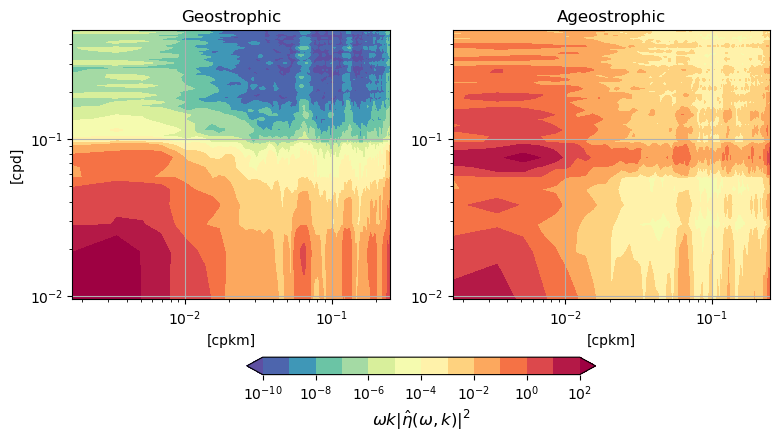

In [12]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fgd.freq_num_lines.isel(freq_num_lines=slice(len(Fgd.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fgd.freq_time.isel(freq_time=slice(len(Fgd.freq_time)//2,
                                                 None)).values*86400,
               (Fgd.freq_num_lines*Fgd.freq_time*Fgd
               ).isel(freq_num_lines=slice(len(Fgd.freq_num_lines)//2,None),
                      freq_time=slice(len(Fgd.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-10,2,13),
               norm=clr.LogNorm(), cmap="Spectral_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fad.freq_num_lines.isel(freq_num_lines=slice(len(Fad.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fad.freq_time.isel(freq_time=slice(len(Fad.freq_time)//2,
                                                 None)).values*86400,
               (Fad.freq_num_lines*Fad.freq_time*Fad
               ).isel(freq_num_lines=slice(len(Fad.freq_num_lines)//2,None),
                      freq_time=slice(len(Fad.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-10,2,13),
               norm=clr.LogNorm(), cmap="Spectral_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fgd.freq_num_lines.where(Fgd.freq_num_lines>0.).min()*1e3,
              Fgd.freq_num_lines.where(Fgd.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fgd.freq_time.where(Fgd.freq_time>0.).min()*86400,
              Fgd.freq_time.where(Fgd.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fad.freq_num_lines.where(Fad.freq_num_lines>0.).min()*1e3,
              Fad.freq_num_lines.where(Fad.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fad.freq_time.where(Fad.freq_time>0.).min()*86400,
              Fad.freq_time.where(Fad.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"$\omega k |\hat{\eta}(\omega,k)|^2$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_Kx_HYCOMdetided.pdf"))

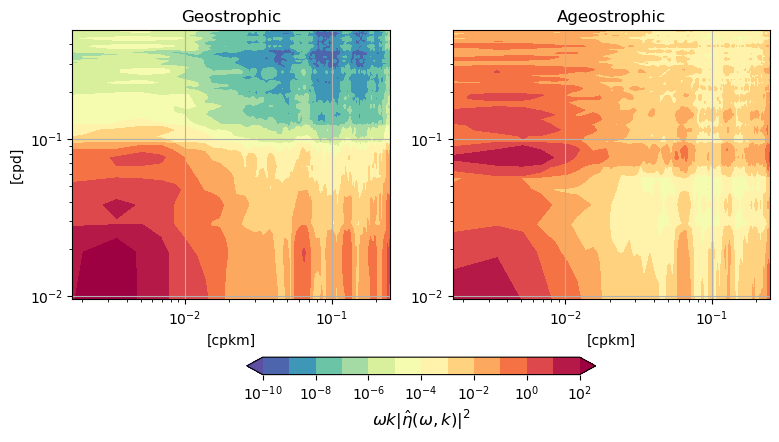

In [11]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fgt.freq_num_lines.isel(freq_num_lines=slice(len(Fgt.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fgt.freq_time.isel(freq_time=slice(len(Fgt.freq_time)//2,
                                                 None)).values*86400,
               (Fgt.freq_num_lines*Fgt.freq_time*Fgt
               ).isel(freq_num_lines=slice(len(Fgt.freq_num_lines)//2,None),
                      freq_time=slice(len(Fgt.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-10,2,13),
               norm=clr.LogNorm(), cmap="Spectral_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fat.freq_num_lines.isel(freq_num_lines=slice(len(Fat.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fat.freq_time.isel(freq_time=slice(len(Fat.freq_time)//2,
                                                 None)).values*86400,
               (Fat.freq_num_lines*Fat.freq_time*Fat
               ).isel(freq_num_lines=slice(len(Fat.freq_num_lines)//2,None),
                      freq_time=slice(len(Fat.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-10,2,13),
               norm=clr.LogNorm(), cmap="Spectral_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fgt.freq_num_lines.where(Fgt.freq_num_lines>0.).min()*1e3,
              Fgt.freq_num_lines.where(Fgt.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fgt.freq_time.where(Fgt.freq_time>0.).min()*86400,
              Fgt.freq_time.where(Fgt.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fat.freq_num_lines.where(Fat.freq_num_lines>0.).min()*1e3,
              Fat.freq_num_lines.where(Fat.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fat.freq_time.where(Fat.freq_time>0.).min()*86400,
              Fat.freq_time.where(Fat.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"$\omega k |\hat{\eta}(\omega,k)|^2$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_Kx_HYCOMtotal.pdf"))

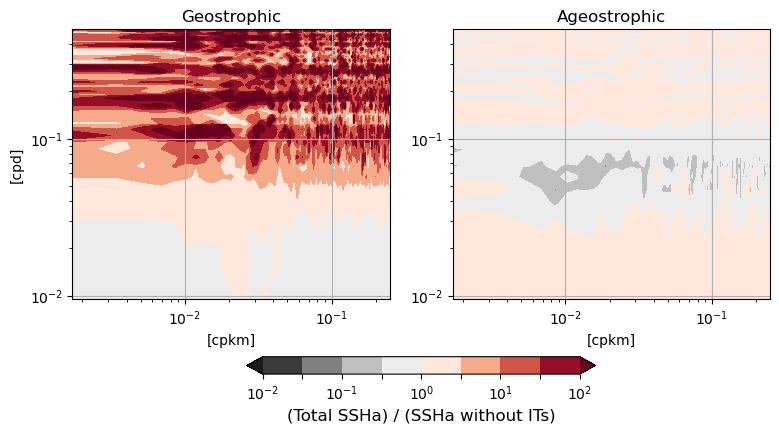

In [12]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fgt.freq_num_lines.isel(freq_num_lines=slice(len(Fgt.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fgt.freq_time.isel(freq_time=slice(len(Fgt.freq_time)//2,
                                                 None)).values*86400,
               (Fgt / Fgd
               ).isel(freq_num_lines=slice(len(Fgt.freq_num_lines)//2,None),
                      freq_time=slice(len(Fgt.freq_time)//2,None)
                     ).values,
               levels=np.logspace(-2,2,9),
               norm=clr.LogNorm(), cmap="RdGy_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fat.freq_num_lines.isel(freq_num_lines=slice(len(Fat.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fat.freq_time.isel(freq_time=slice(len(Fat.freq_time)//2,
                                                 None)).values*86400,
               (Fat / Fad
               ).isel(freq_num_lines=slice(len(Fat.freq_num_lines)//2,None),
                      freq_time=slice(len(Fat.freq_time)//2,None)
                     ).values,
               levels=np.logspace(-2,2,9),
               norm=clr.LogNorm(), cmap="RdGy_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fgt.freq_num_lines.where(Fgt.freq_num_lines>0.).min()*1e3,
              Fgt.freq_num_lines.where(Fgt.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fgt.freq_time.where(Fgt.freq_time>0.).min()*86400,
              Fgt.freq_time.where(Fgt.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fat.freq_num_lines.where(Fat.freq_num_lines>0.).min()*1e3,
              Fat.freq_num_lines.where(Fat.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fat.freq_time.where(Fat.freq_time>0.).min()*86400,
              Fat.freq_time.where(Fat.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"(Total SSHa) / (SSHa without ITs)", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_Kx_HYCOMratio.pdf"))

# Gulf Stream

In [240]:
ds09 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 9))
ds09.coords["num_lines"] = ("num_lines",range(len(ds09.num_lines)))
ds09.coords["num_pixels"] = ("num_pixels",range(len(ds09.num_pixels)))

ds22 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 22))
ds22.coords["num_lines"] = ("num_lines",range(len(ds22.num_lines)))
ds22.coords["num_pixels"] = ("num_pixels",range(len(ds22.num_pixels)))
ds09,ds22

(<xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
     longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 571MB dask.array<chunksize=(1, 9860, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels  

In [241]:
maskn9 = xr.DataArray(ds09.latitude.where(ds09.latitude<37.9).to_masked_array().mask,
                     dims=ds09.latitude.dims,
                     coords=ds09.latitude.coords
                    )
masks9 = xr.DataArray(ds09.latitude.where(ds09.latitude>32.5).to_masked_array().mask,
                     dims=ds09.latitude.dims,
                     coords=ds09.latitude.coords
                    )
xo09 = ds09.where(~maskn9,drop=True).where(~masks9,drop=True)

maskn2 = xr.DataArray(ds22.latitude.where(ds22.latitude<37.9).to_masked_array().mask,
                     dims=ds22.latitude.dims,
                     coords=ds22.latitude.coords
                    )
masks2 = xr.DataArray(ds22.latitude.where(ds22.latitude>32.5).to_masked_array().mask,
                     dims=ds22.latitude.dims,
                     coords=ds22.latitude.coords
                    )
xo22 = ds22.where(~maskn2,drop=True).where(~masks2,drop=True)
xo09, xo22

(<xarray.Dataset> Size: 19MB
 Dimensions:       (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 3kB 6747 6748 6749 6750 ... 7065 7066 7067
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 177kB 32.5 32.5 ... 37.9 37.89
     longitude     (num_lines, num_pixels) float64 177kB 284.5 284.5 ... 287.4
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 19MB dask.array<chunksize=(1, 321, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 19MB
 Dimensions:       (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 3kB 2794 2795 2796 2797 ... 3112 3113 3114
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 6

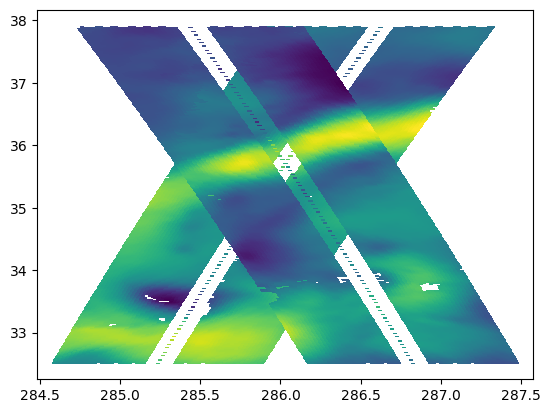

In [242]:
fig, ax = plt.subplots()
ax.pcolormesh(xo09.longitude, xo09.latitude,
              xo09.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )
ax.pcolormesh(xo22.longitude, xo22.latitude,
              xo22.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )

In [243]:
inp = 3

mask09 = xr.DataArray(xo09.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo09.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo09.ssha_detided.isel(cycle_num=0).coords
                    )
mm09 = xr.DataArray(mask09.where(mask09<.5
                              ).to_masked_array().mask,
                   dims=xo09.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo09.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mask22 = xr.DataArray(xo22.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo22.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo22.ssha_detided.isel(cycle_num=0).coords
                    )
mm22 = xr.DataArray(mask22.where(mask22<.5
                              ).to_masked_array().mask,
                   dims=xo22.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo22.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mm09, mm22

(<xarray.DataArray (num_lines: 321, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ...,  True,  True,  True]], shape=(321, 63))
 Coordinates:
   * num_lines   (num_lines) int64 3kB 6747 6748 6749 6750 ... 7065 7066 7067
   * num_pixels  (num_pixels) int64 504B 3 4 5 6 7 8 9 ... 59 60 61 62 63 64 65
     cycle_num   int64 8B 474
     latitude    (num_lines, num_pixels) float64 162kB 32.49 32.49 ... 37.91
     longitude   (num_lines, num_pixels) float64 162kB 284.6 284.6 ... 287.4,
 <xarray.DataArray (num_lines: 321, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ..., False,  True,  True],
        [ True,  True,  True

In [244]:
low09 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass%03d/SSHa.zarr" 
                               % 9)
                      ).ssha.where(~maskn9,drop=True).where(~masks9,drop=True)
low22 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass%03d/SSHa.zarr" 
                               % 22)
                      ).ssha.where(~maskn2,drop=True).where(~masks2,drop=True)
low09, low22

(<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 6748 6749 6750 6751 ... 7064 7065 7066
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 156kB 32.51 32.51 ... 37.9 37.89
     longitude   (num_lines, num_pixels) float64 156kB 284.6 284.6 ... 287.3,
 <xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 2795 2796 2797 2798 ... 3111 3112 3113
   * num_pixels  (num_pixels) i

In [245]:
r_ref9 = (~mm09).sum() / np.prod(mm09.shape)
r_ref2 = (~mm22).sum() / np.prod(mm22.shape)
r_ref2

<xarray.DataArray ()> Size: 8B
array(0.80660634)
Coordinates:
    cycle_num  int64 8B 474

In [246]:
ageo = (1e-2*ds09.ssha_detided
        - low09
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low09.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r09 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r09 = xr.concat([r09, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref9:
        if ic == 0:
            a09 = ssha
        else:
            try:
                a09 = xr.concat([a09, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a09.coords["cycle_num"] = ("cycle_num",
                           r09.where(r09>0.7*r_ref9, drop=True).cycle_num.data
                          )

dsa09 = a09.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa09.coords["y"] = ("y",range(len(dsa09.y)))
dsa09.coords["x"] = ("x",range(len(dsa09.x)))
if not dsa09.rio.crs:
    dsa09 = dsa09.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa09.ssha.rio.nodata is None:
    dsa09["ssha"] = dsa09.ssha.rio.write_nodata(np.nan)
_a09_exterp = dsa09.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a09_interp = _a09_exterp.interp(cycle_num=ds09.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a09_exterp = _a09_exterp.where(mm09.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds09.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa09.close()

dsg09 = low09.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg09.coords["y"] = ("y",range(len(dsg09.y)))
dsg09.coords["x"] = ("x",range(len(dsg09.x)))
if not dsg09.rio.crs:
    dsg09 = dsg09.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg09.ssha.rio.nodata is None:
    dsg09["ssha"] = dsg09.ssha.rio.write_nodata(np.nan)
_g09_exterp = dsg09.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g09_interp = _g09_exterp.interp(cycle_num=ds09.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g09_exterp = _g09_exterp.where(mm09.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds09.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg09.close()

In [247]:
ageo = (1e-2*ds22.ssha_detided
        - low22
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low22.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r22 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r22 = xr.concat([r22, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref2:
        if ic == 0:
            a22 = ssha
        else:
            try:
                a22 = xr.concat([a22, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a22.coords["cycle_num"] = ("cycle_num",
                           r22.where(r22>0.7*r_ref2, drop=True).cycle_num.data
                          )

dsa22 = a22.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa22.coords["y"] = ("y",range(len(dsa22.y)))
dsa22.coords["x"] = ("x",range(len(dsa22.x)))
if not dsa22.rio.crs:
    dsa22 = dsa22.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa22.ssha.rio.nodata is None:
    dsa22["ssha"] = dsa22.ssha.rio.write_nodata(np.nan)
_a22_exterp = dsa22.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a22_interp = _a22_exterp.interp(cycle_num=ds22.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a22_exterp = _a22_exterp.where(mm22.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds22.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa22.close()

dsg22 = low22.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg22.coords["y"] = ("y",range(len(dsg22.y)))
dsg22.coords["x"] = ("x",range(len(dsg22.x)))
if not dsg22.rio.crs:
    dsg22 = dsg22.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg22.ssha.rio.nodata is None:
    dsg22["ssha"] = dsg22.ssha.rio.write_nodata(np.nan)
_g22_exterp = dsg22.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g22_interp = _g22_exterp.interp(cycle_num=ds22.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g22_exterp = _g22_exterp.where(mm22.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds22.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg22.close()

In [248]:
for cc in low09.cycle_num:
    if cc == low09.cycle_num[0]:
        ar_g9 = g09_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a9 = a09_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])

        ar_g2 = g22_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a2 = a22_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
    else:
        ar_g9 = xr.concat([ar_g9, 
                          g09_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a9 = xr.concat([ar_a9, 
                          a09_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_g2 = xr.concat([ar_g2, 
                          g22_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a2 = xr.concat([ar_a2, 
                          a22_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")

ar_g9.coords["time"] = ("time",np.arange(len(ar_g9.time))*24*60.*60)
ar_a9.coords["time"] = ("time",np.arange(len(ar_a9.time))*24*60.*60)
ar_g2.coords["time"] = ("time",np.arange(len(ar_g2.time))*24*60.*60)
ar_a2.coords["time"] = ("time",np.arange(len(ar_a2.time))*24*60.*60)
ar_g9.coords["num_lines"] = ("num_lines",np.arange(len(ar_g9.num_lines))*2e3)
ar_a9.coords["num_lines"] = ("num_lines",np.arange(len(ar_a9.num_lines))*2e3)
ar_g2.coords["num_lines"] = ("num_lines",np.arange(len(ar_g2.num_lines))*2e3)
ar_a2.coords["num_lines"] = ("num_lines",np.arange(len(ar_a2.num_lines))*2e3)

ar_g9, ar_a2

(<xarray.DataArray 'ssha' (time: 105, num_lines: 294, num_pixels: 2)> Size: 494kB
 array([[[-0.01159815,  0.22678214],
         [-0.01328404,  0.22183781],
         [-0.01426868,  0.21685487],
         ...,
         [ 0.05864427,  0.05514356],
         [ 0.05970473,  0.05512229],
         [ 0.06058492,  0.05496467]],
 
        [[-0.01187026,  0.21478142],
         [-0.01413821,  0.21087999],
         [-0.01587318,  0.2069253 ],
         ...,
         [ 0.0542359 ,  0.02979481],
         [ 0.05551091,  0.02981698],
         [ 0.056437  ,  0.02967546]],
 
        [[ 0.00687169,  0.212486  ],
         [ 0.00453572,  0.20956886],
         [ 0.00253806,  0.20654591],
         ...,
 ...
         ...,
         [ 0.10068784,  0.24503463],
         [ 0.10083745,  0.23500745],
         [ 0.10083365,  0.22527078]],
 
        [[ 0.1267555 ,  0.13781288],
         [ 0.12988053,  0.12687892],
         [ 0.1332867 ,  0.11613282],
         ...,
         [ 0.10541569,  0.22044041],
         [ 0.1055753

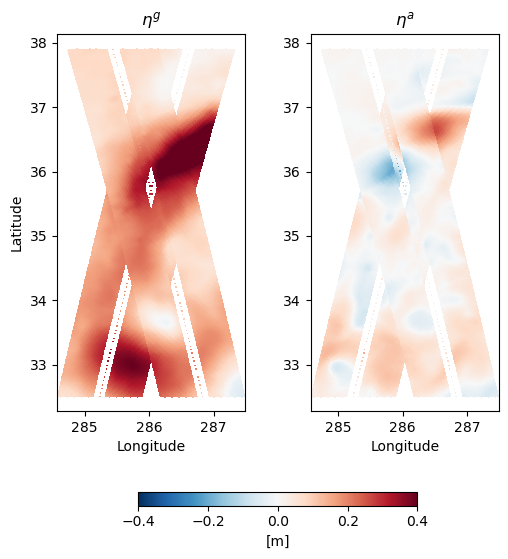

In [249]:
cnum = 20
fig, axes = plt.subplots(figsize=(6,7), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].pcolormesh(g09_exterp.isel(cycle_num=cnum).longitude, 
                        g09_exterp.isel(cycle_num=cnum).latitude,
               g09_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[0].pcolormesh(g22_exterp.isel(cycle_num=cnum).longitude, 
                   g22_exterp.isel(cycle_num=cnum).latitude,
               g22_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[1].pcolormesh(a09_exterp.isel(cycle_num=cnum).longitude, 
                   a09_exterp.isel(cycle_num=cnum).latitude,
               a09_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[1].pcolormesh(a22_exterp.isel(cycle_num=cnum).longitude, 
                   a22_exterp.isel(cycle_num=cnum).latitude,
               a22_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[0].set_aspect("equal")
axes[1].set_aspect("equal")
axes[0].set_xlabel(r"Longitude")
axes[0].set_ylabel(r"Latitude")
axes[1].set_xlabel(r"Longitude")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.6)
cbar.set_label(r"[m]")
axes[0].set_title(r"$\eta^g$")
axes[1].set_title(r"$\eta^a$")
plt.savefig(op.join(ddir,"../Figs/ssha-GS.pdf"))

In [250]:
Fg2 = xrft.power_spectrum(ar_g2.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg2 = xrft.power_spectrum(Fg2.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa2 = xrft.power_spectrum(ar_a2.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa2 = xrft.power_spectrum(Fa2.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fg9 = xrft.power_spectrum(ar_g9.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg9 = xrft.power_spectrum(Fg9.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa9 = xrft.power_spectrum(ar_a9.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa9 = xrft.power_spectrum(Fa9.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa = .5*(Fa2 + Fa9)
Fg = .5*(Fg2 + Fg9)
Fg, Fa

(<xarray.DataArray (freq_time: 105, freq_num_lines: 294)> Size: 247kB
 dask.array<mul, shape=(105, 294), dtype=float64, chunksize=(105, 294), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483,
 <xarray.DataArray (freq_time: 105, freq_num_lines: 294)> Size: 247kB
 dask.array<mul, shape=(105, 294), dtype=float64, chunksize=(105, 294), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483)

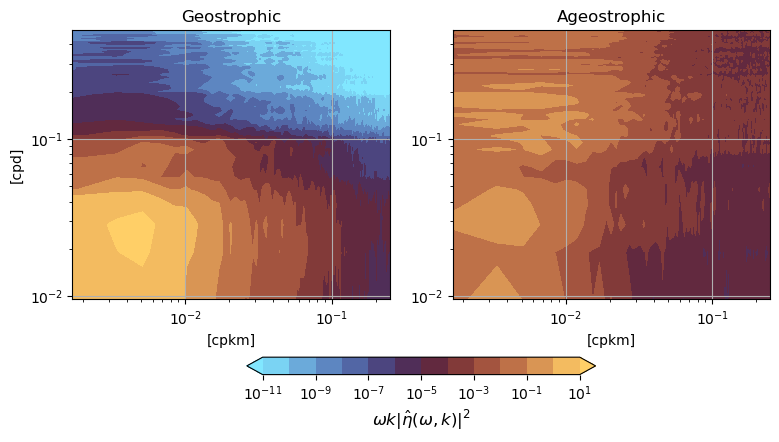

In [49]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fg.freq_num_lines.isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fg.freq_time.isel(freq_time=slice(len(Fg.freq_time)//2,
                                                 None)).values*86400,
               (Fg.freq_num_lines*Fg.freq_time*Fg
               ).isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,None),
                      freq_time=slice(len(Fg.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fa.freq_num_lines.isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fa.freq_time.isel(freq_time=slice(len(Fa.freq_time)//2,
                                                 None)).values*86400,
               (Fa.freq_num_lines*Fa.freq_time*Fa
               ).isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,None),
                      freq_time=slice(len(Fa.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fg.freq_num_lines.where(Fg.freq_num_lines>0.).min()*1e3,
              Fg.freq_num_lines.where(Fg.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fg.freq_time.where(Fg.freq_time>0.).min()*86400,
              Fg.freq_time.where(Fg.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fa.freq_num_lines.where(Fa.freq_num_lines>0.).min()*1e3,
              Fa.freq_num_lines.where(Fa.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fa.freq_time.where(Fa.freq_time>0.).min()*86400,
              Fa.freq_time.where(Fa.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"$\omega k |\hat{\eta}(\omega,k)|^2$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_GS.pdf"))

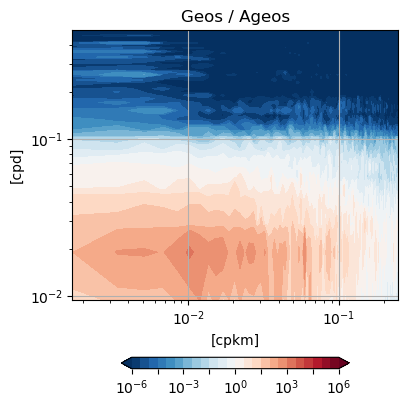

In [256]:
fig, ax = plt.subplots(figsize=(4.2,5))
# fig.set_tight_layout(True)
im = ax.contourf(Fg.freq_num_lines.isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fg.freq_time.isel(freq_time=slice(len(Fg.freq_time)//2,
                                                 None)).values*86400,
               ((Fg.freq_num_lines*Fg.freq_time*Fg
                ).isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,None),
                       freq_time=slice(len(Fg.freq_time)//2,None)
                      ).values.T
                / (Fa.freq_num_lines*Fa.freq_time*Fa
               ).isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,None),
                      freq_time=slice(len(Fa.freq_time)//2,None)
                     ).values.T
               ),
               levels=np.logspace(-6,6,25),
               norm=clr.LogNorm(), cmap="RdBu_r",
               extend="both",
               rasterized=True
              )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([Fg.freq_num_lines.where(Fg.freq_num_lines>0.).min()*1e3,
              Fg.freq_num_lines.where(Fg.freq_num_lines>0.).max()*1e3])
ax.set_ylim([Fg.freq_time.where(Fg.freq_time>0.).min()*86400,
              Fg.freq_time.where(Fg.freq_time>0.).max()*86400])
ax.set_xlabel(r"[cpkm]")
ax.set_ylabel(r"[cpd]")
ax.grid(True)
ax.set_title(r"Geos / Ageos")
cbar = fig.colorbar(im, ax=ax, orientation="horizontal", shrink=.7)
plt.savefig(op.join(ddir,"../Figs/omega-k_GS-ratio.pdf"))

In [252]:
dsv2 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass022/SSVs_SwotDiag.zarr"))
dsv9 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass009/SSVs_SwotDiag.zarr"))
dsv2r = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass022/SSVs_rawSwotDiag.zarr"))
dsv9r = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass009/SSVs_rawSwotDiag.zarr"))
dsv2, dsv9

(<xarray.Dataset> Size: 3GB
 Dimensions:     (cycle_num: 105, num_lines: 9310, num_pixels: 61)
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
     longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
 Data variables:
     strain      (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     ucg         (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     ug          (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     vcg         (cycle_num, num_lines, num_pixels) float64 477MB das

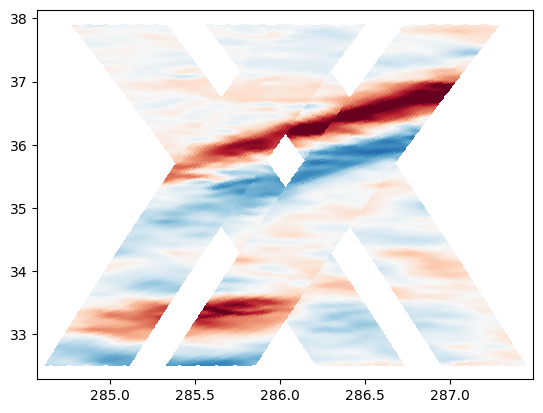

In [253]:
u2 = dsv2.ug.where(~maskn2,drop=True).where(~masks2,drop=True)
u9 = dsv9.ug.where(~maskn9,drop=True).where(~masks9,drop=True)

fig, ax = plt.subplots()
ax.pcolormesh(u2.longitude, u2.latitude,
              u2.isel(cycle_num=11),
              vmax=.8, vmin=-.8, cmap="RdBu_r",
              rasterized=True
             )
ax.pcolormesh(u9.longitude, u9.latitude,
              u9.isel(cycle_num=11),
              vmax=.8, vmin=-.8, cmap="RdBu_r",
              rasterized=True
             )

In [254]:
sp2 = np.sqrt(dsv2.ug**2 + dsv2.vg**2).where(~maskn2,drop=True).where(~masks2,drop=True)
sp9 = np.sqrt(dsv9.ug**2 + dsv9.vg**2).where(~maskn9,drop=True).where(~masks9,drop=True)
v2 = dsv2.vort.where(~maskn2,drop=True).where(~masks2,drop=True)
s2 = dsv2.strain.where(~maskn2,drop=True).where(~masks2,drop=True)
v9 = dsv9.vort.where(~maskn9,drop=True).where(~masks9,drop=True)
s9 = dsv9.strain.where(~maskn9,drop=True).where(~masks9,drop=True)
v2r = dsv2r.vort.where(~maskn2,drop=True
                      ).where(~masks2,drop=True
                             ).isel(num_pixels=slice(4,-4),
                                    num_lines=slice(1,-1)
                                   ).dropna("cycle_num", how="all")
s2r = dsv2r.strain.where(~maskn2,drop=True
                        ).where(~masks2,drop=True
                               ).isel(num_pixels=slice(4,-4),
                                      num_lines=slice(1,-1)
                                     ).dropna("cycle_num", how="all")
v9r = dsv9r.vort.where(~maskn9,drop=True
                      ).where(~masks9,drop=True
                             ).isel(num_pixels=slice(4,-4),
                                    num_lines=slice(1,-1)
                                   ).dropna("cycle_num", how="all")
s9r = dsv9r.strain.where(~maskn9,drop=True
                        ).where(~masks9,drop=True
                               ).isel(num_pixels=slice(4,-4),
                                      num_lines=slice(1,-1)
                                     ).dropna("cycle_num", how="all")
v2, v2r

(<xarray.DataArray 'vort' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 2795 2796 2797 2798 ... 3111 3112 3113
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 156kB 38.13 38.12 ... 32.3 32.3
     longitude   (num_lines, num_pixels) float64 156kB 286.1 286.0 ... 286.2,
 <xarray.DataArray 'vort' (cycle_num: 97, num_lines: 319, num_pixels: 61)> Size: 15MB
 dask.array<getitem, shape=(97, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 776B 474 476 478 479 480 ... 574 575 576 577
   * num_lines   (num_lines) int64 3kB 2795 2796 2797 2798 ... 3111 3112 3113
   * num_pixels  (num_pixels) in

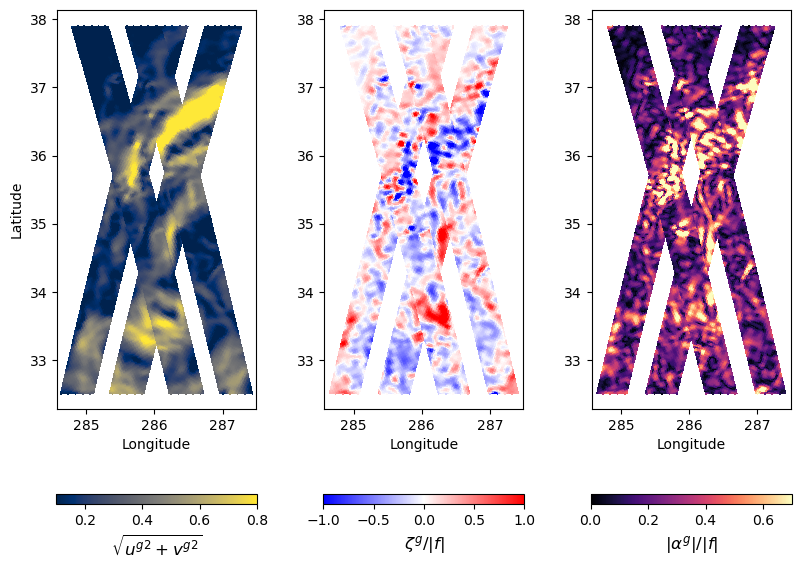

In [255]:
fig, (ax0, ax1,ax2) = plt.subplots(figsize=(9,6), nrows=1, ncols=3)
fig.set_tight_layout(True)
ax0.pcolormesh(sp9.isel(cycle_num=cnum).longitude, sp9.isel(cycle_num=cnum).latitude,
               sp9.isel(cycle_num=cnum),
               vmin=.1, vmax=.8, cmap="cividis",
               rasterized=True)
im0 = ax0.pcolormesh(sp2.isel(cycle_num=cnum).longitude, sp2.isel(cycle_num=cnum).latitude,
               sp2.isel(cycle_num=cnum),
               vmin=.1, vmax=.8, cmap="cividis",
               rasterized=True)
ax1.pcolormesh(v9.isel(cycle_num=cnum).longitude, v9.isel(cycle_num=cnum).latitude,
               (v9.isel(cycle_num=cnum) 
                / np.abs(gsw.f(v9.isel(cycle_num=cnum).latitude))),
               vmin=-1, vmax=1, cmap="bwr",
               rasterized=True)
im1 = ax1.pcolormesh(v2.isel(cycle_num=cnum).longitude, v2.isel(cycle_num=cnum).latitude,
               (v2.isel(cycle_num=cnum) 
                / np.abs(gsw.f(v2.isel(cycle_num=cnum).latitude))),
               vmin=-1, vmax=1, cmap="bwr",
               rasterized=True)
ax2.pcolormesh(s9.isel(cycle_num=cnum).longitude, s9.isel(cycle_num=cnum).latitude,
               (s9.isel(cycle_num=cnum) 
                / np.abs(gsw.f(s9.isel(cycle_num=cnum).latitude))),
               vmax=.7, vmin=0., cmap="magma",
               rasterized=True)
im2 = ax2.pcolormesh(s2.isel(cycle_num=cnum).longitude, s2.isel(cycle_num=cnum).latitude,
               (s2.isel(cycle_num=cnum) 
                / np.abs(gsw.f(s2.isel(cycle_num=cnum).latitude))),
               vmax=.7, vmin=0., cmap="magma",
               rasterized=True)
ax0.set_aspect("equal")
ax1.set_aspect("equal")
ax2.set_aspect("equal")
ax0.set_xlabel(r"Longitude")
ax1.set_xlabel(r"Longitude")
ax0.set_ylabel(r"Latitude")
ax2.set_xlabel(r"Longitude")
cbar0 = fig.colorbar(im0, ax=ax0, orientation="horizontal", shrink=.6)
cbar1 = fig.colorbar(im1, ax=ax1, orientation="horizontal", shrink=.6)
cbar2 = fig.colorbar(im2, ax=ax2, orientation="horizontal", shrink=.6)
cbar0.set_label(r"$\sqrt{{u^g}^2 + {v^g}^2}$", fontsize=12)
cbar1.set_label(r"$\zeta^g/|f|$", fontsize=12)
cbar2.set_label(r"$|\alpha^g|/|f|$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/vort-strain-GS.pdf"))

In [53]:
vort = xr.concat([v2.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  v9.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
strain = xr.concat([s2.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  s9.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
f = gsw.f(vort.latitude)
vort_raw = xr.concat([v2r.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  v9r.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
str_raw = xr.concat([s2r.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  s9r.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
fr = gsw.f(vort_raw.latitude)
vort, strain, f

(<xarray.DataArray 'vort' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 dask.array<concatenate, shape=(210, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (cycle_num, num_lines, num_pixels) float64 33MB 38.13 ... 37.89
     longitude  (cycle_num, num_lines, num_pixels) float64 33MB 286.1 ... 287.3
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'strain' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 dask.array<concatenate, shape=(210, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (cycle_num, num_lines, num_pixels) float64 33MB 38.13 ... 37.89
     longitude  (cycle_num, num_lines, num_pixels) float64 33MB 286.1 ... 287.3
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'latitude' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 array([[[9.00471062e-05, 9.0

In [54]:
vbins = np.linspace(-3e0,3e0,60)
sbins = np.linspace(0,3e0,30)
hist_c = xhist((strain / np.abs(f)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort / np.abs(f)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()
hist_r = xhist((str_raw / np.abs(fr)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort_raw / np.abs(fr)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()

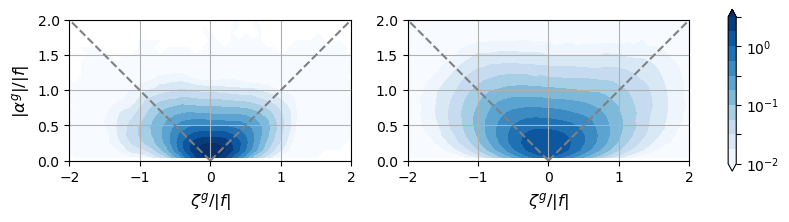

In [55]:
fig, axes = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
# fig.set_tight_layout(True)

im = axes[0].contourf(hist_c.vort_bin,
                 hist_c.strain_bin,
                 hist_c, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )
axes[1].contourf(hist_r.vort_bin,
                 hist_r.strain_bin,
                 hist_r, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )

# for c in im.collections:
#     c.set_rasterized(True)

axes[0].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[0].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')
axes[1].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[1].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')

axes[0].set_xlim([-2,2])
axes[0].set_ylim([0,2])
axes[1].set_xlim([-2,2])
axes[1].set_ylim([0,2])

axes[0].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[1].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[0].set_ylabel(r"$|\alpha^g|/|f|$", fontsize=12)

axes[0].grid(True)
axes[0].set_aspect('equal')
axes[1].grid(True)
axes[1].set_aspect('equal')

# fig.subplots_adjust(hspace=.06, wspace=.12)
# cbar = fig.colorbar(im, orientation='horizontal', ax=axes, shrink=.4, 
#                     ticks=[1e-4,1e-3,1e-2,1e-1,1e0])
cbar = fig.colorbar(im, ax=axes, shrink=.7)
# cbar.set_ticks([1e-2,1e-1,0,1])

plt.savefig(op.join(ddir,"../Figs/vort-strain-GSjointPDF.pdf"))

# California

In [152]:
ds13 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 13))
ds13.coords["num_lines"] = ("num_lines",range(len(ds13.num_lines)))
ds13.coords["num_pixels"] = ("num_pixels",range(len(ds13.num_pixels)))

ds26 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 26))
ds26.coords["num_lines"] = ("num_lines",range(len(ds26.num_lines)))
ds26.coords["num_pixels"] = ("num_pixels",range(len(ds26.num_pixels)))
ds13,ds26

(<xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
     longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 571MB dask.array<chunksize=(1, 9860, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels  

In [153]:
maskn3 = xr.DataArray(ds13.latitude.where(ds13.latitude<38.4).to_masked_array().mask,
                     dims=ds13.latitude.dims,
                     coords=ds13.latitude.coords
                    )
masks3 = xr.DataArray(ds13.latitude.where(ds13.latitude>33.).to_masked_array().mask,
                     dims=ds13.latitude.dims,
                     coords=ds13.latitude.coords
                    )
xo13 = ds13.where(~maskn3,drop=True).where(~masks3,drop=True)

maskn6 = xr.DataArray(ds26.latitude.where(ds26.latitude<38.4).to_masked_array().mask,
                     dims=ds26.latitude.dims,
                     coords=ds26.latitude.coords
                    )
masks6 = xr.DataArray(ds26.latitude.where(ds26.latitude>33.).to_masked_array().mask,
                     dims=ds26.latitude.dims,
                     coords=ds26.latitude.coords
                    )
xo26 = ds26.where(~maskn6,drop=True).where(~masks6,drop=True)
xo13, xo26

(<xarray.Dataset> Size: 19MB
 Dimensions:       (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 3kB 6775 6776 6777 6778 ... 7093 7094 7095
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 177kB 33.0 33.0 ... 38.38
     longitude     (num_lines, num_pixels) float64 177kB 233.2 233.2 ... 236.1
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 19MB dask.array<chunksize=(1, 321, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 19MB
 Dimensions:       (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 3kB 2766 2767 2768 2769 ... 3084 3085 3086
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 

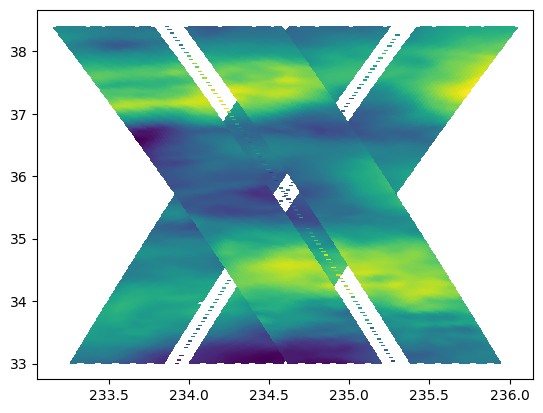

In [51]:
fig, ax = plt.subplots()
ax.pcolormesh(xo13.longitude, xo13.latitude,
              xo13.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )
ax.pcolormesh(xo26.longitude, xo26.latitude,
              xo26.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )

In [154]:
inp = 3

mask13 = xr.DataArray(xo13.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo13.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo13.ssha_detided.isel(cycle_num=0).coords
                    )
mm13 = xr.DataArray(mask13.where(mask13<.5
                              ).to_masked_array().mask,
                   dims=xo13.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo13.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mask26 = xr.DataArray(xo26.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo26.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo26.ssha_detided.isel(cycle_num=0).coords
                    )
mm26 = xr.DataArray(mask26.where(mask26<.5
                              ).to_masked_array().mask,
                   dims=xo26.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo26.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mm13, mm26

(<xarray.DataArray (num_lines: 321, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ...,  True,  True,  True]], shape=(321, 63))
 Coordinates:
   * num_lines   (num_lines) int64 3kB 6775 6776 6777 6778 ... 7093 7094 7095
   * num_pixels  (num_pixels) int64 504B 3 4 5 6 7 8 9 ... 59 60 61 62 63 64 65
     cycle_num   int64 8B 474
     latitude    (num_lines, num_pixels) float64 162kB 32.99 32.99 ... 38.4 38.4
     longitude   (num_lines, num_pixels) float64 162kB 233.2 233.3 ... 236.1,
 <xarray.DataArray (num_lines: 321, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  

In [155]:
low13 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass%03d/SSHa.zarr" 
                               % 13)
                      ).ssha.where(~maskn3,drop=True).where(~masks3,drop=True)
low26 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass%03d/SSHa.zarr" 
                               % 26)
                      ).ssha.where(~maskn6,drop=True).where(~masks6,drop=True)
low13, low26

(<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 6776 6777 6778 6779 ... 7092 7093 7094
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 156kB 33.0 33.0 ... 38.39 38.38
     longitude   (num_lines, num_pixels) float64 156kB 233.3 233.3 ... 236.0,
 <xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 2767 2768 2769 2770 ... 3083 3084 3085
   * num_pixels  (num_pixels) in

In [156]:
r_ref3 = (~mm13).sum() / np.prod(mm13.shape)
r_ref6 = (~mm26).sum() / np.prod(mm26.shape)
r_ref6

<xarray.DataArray ()> Size: 8B
array(0.82247936)
Coordinates:
    cycle_num  int64 8B 474

In [157]:
ageo = (1e-2*ds13.ssha_detided
        - low13
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low13.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r13 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r13 = xr.concat([r13, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref3:
        if ic == 0:
            a13 = ssha
        else:
            try:
                a13 = xr.concat([a13, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a13.coords["cycle_num"] = ("cycle_num",
                           r13.where(r13>0.7*r_ref3, drop=True).cycle_num.data
                          )

dsa13 = a13.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa13.coords["y"] = ("y",range(len(dsa13.y)))
dsa13.coords["x"] = ("x",range(len(dsa13.x)))
if not dsa13.rio.crs:
    dsa13 = dsa13.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa13.ssha.rio.nodata is None:
    dsa13["ssha"] = dsa13.ssha.rio.write_nodata(np.nan)
_a13_exterp = dsa13.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a13_interp = _a13_exterp.interp(cycle_num=ds13.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a13_exterp = _a13_exterp.where(mm13.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds13.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa13.close()

dsg13 = low13.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg13.coords["y"] = ("y",range(len(dsg13.y)))
dsg13.coords["x"] = ("x",range(len(dsg13.x)))
if not dsg13.rio.crs:
    dsg13 = dsg13.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg13.ssha.rio.nodata is None:
    dsg13["ssha"] = dsg13.ssha.rio.write_nodata(np.nan)
_g13_exterp = dsg13.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g13_interp = _g13_exterp.interp(cycle_num=ds13.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g13_exterp = _g13_exterp.where(mm13.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds13.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg13.close()

In [158]:
ageo = (1e-2*ds26.ssha_detided
        - low26
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low26.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r26 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r26 = xr.concat([r26, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref6:
        if ic == 0:
            a26 = ssha
        else:
            try:
                a26 = xr.concat([a26, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a26.coords["cycle_num"] = ("cycle_num",
                           r26.where(r26>0.7*r_ref6, drop=True).cycle_num.data
                          )

dsa26 = a26.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa26.coords["y"] = ("y",range(len(dsa26.y)))
dsa26.coords["x"] = ("x",range(len(dsa26.x)))
if not dsa26.rio.crs:
    dsa26 = dsa26.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa26.ssha.rio.nodata is None:
    dsa26["ssha"] = dsa26.ssha.rio.write_nodata(np.nan)
_a26_exterp = dsa26.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a26_interp = _a26_exterp.interp(cycle_num=ds26.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a26_exterp = _a26_exterp.where(mm26.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds26.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa26.close()

dsg26 = low26.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg26.coords["y"] = ("y",range(len(dsg26.y)))
dsg26.coords["x"] = ("x",range(len(dsg26.x)))
if not dsg26.rio.crs:
    dsg26 = dsg26.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg26.ssha.rio.nodata is None:
    dsg26["ssha"] = dsg26.ssha.rio.write_nodata(np.nan)
_g26_exterp = dsg26.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g26_interp = _g26_exterp.interp(cycle_num=ds26.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g26_exterp = _g26_exterp.where(mm26.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds26.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg26.close()

In [159]:
for cc in low13.cycle_num:
    if cc == low13.cycle_num[0]:
        ar_g3 = g13_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a3 = a13_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])

        ar_g6 = g26_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a6 = a26_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
    else:
        ar_g3 = xr.concat([ar_g3, 
                          g13_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a3 = xr.concat([ar_a3, 
                          a13_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_g6 = xr.concat([ar_g6, 
                          g26_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a6 = xr.concat([ar_a6, 
                          a26_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")

ar_g3.coords["time"] = ("time",np.arange(len(ar_g3.time))*24*60.*60)
ar_a3.coords["time"] = ("time",np.arange(len(ar_a3.time))*24*60.*60)
ar_g6.coords["time"] = ("time",np.arange(len(ar_g6.time))*24*60.*60)
ar_a6.coords["time"] = ("time",np.arange(len(ar_a6.time))*24*60.*60)
ar_g3.coords["num_lines"] = ("num_lines",np.arange(len(ar_g3.num_lines))*2e3)
ar_a3.coords["num_lines"] = ("num_lines",np.arange(len(ar_a3.num_lines))*2e3)
ar_g6.coords["num_lines"] = ("num_lines",np.arange(len(ar_g6.num_lines))*2e3)
ar_a6.coords["num_lines"] = ("num_lines",np.arange(len(ar_a6.num_lines))*2e3)

ar_g3, ar_a6

(<xarray.DataArray 'ssha' (time: 105, num_lines: 294, num_pixels: 2)> Size: 494kB
 array([[[ 0.00194147, -0.010597  ],
         [ 0.00275221, -0.008817  ],
         [ 0.00389293, -0.00713606],
         ...,
         [ 0.05732099,  0.13294741],
         [ 0.05614786,  0.13256777],
         [ 0.0545497 ,  0.1329403 ]],
 
        [[ 0.00792372, -0.02387864],
         [ 0.00878302, -0.02159485],
         [ 0.00997976, -0.01944514],
         ...,
         [ 0.04641611,  0.12968883],
         [ 0.04525525,  0.12872823],
         [ 0.04381471,  0.12841049]],
 
        [[ 0.01325687, -0.03351986],
         [ 0.01418785, -0.0309146 ],
         [ 0.01547532, -0.02845191],
         ...,
 ...
         ...,
         [ 0.02847812,  0.13561191],
         [ 0.02729987,  0.1351321 ],
         [ 0.02629937,  0.13487066]],
 
        [[ 0.03693759,  0.07861905],
         [ 0.03890571,  0.07911629],
         [ 0.04122119,  0.07947975],
         ...,
         [ 0.02755469,  0.13546924],
         [ 0.0264640

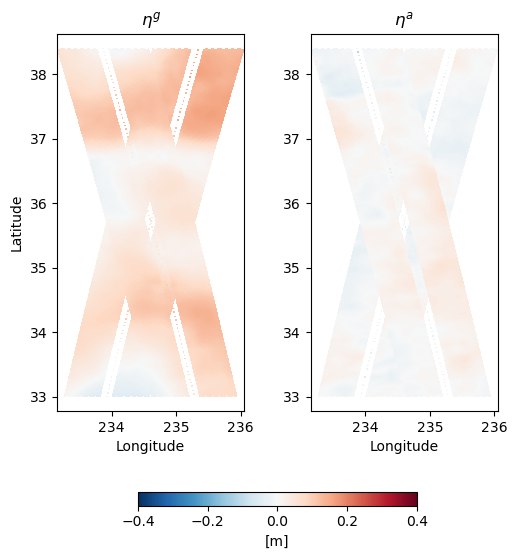

In [58]:
cnum = 20
fig, axes = plt.subplots(figsize=(6,7), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].pcolormesh(g13_exterp.isel(cycle_num=cnum).longitude, 
                        g13_exterp.isel(cycle_num=cnum).latitude,
               g13_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[0].pcolormesh(g26_exterp.isel(cycle_num=cnum).longitude, 
                   g26_exterp.isel(cycle_num=cnum).latitude,
               g26_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[1].pcolormesh(a13_exterp.isel(cycle_num=cnum).longitude, 
                   a13_exterp.isel(cycle_num=cnum).latitude,
               a13_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[1].pcolormesh(a26_exterp.isel(cycle_num=cnum).longitude, 
                   a26_exterp.isel(cycle_num=cnum).latitude,
               a26_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[0].set_aspect("equal")
axes[1].set_aspect("equal")
axes[0].set_xlabel(r"Longitude")
axes[0].set_ylabel(r"Latitude")
axes[1].set_xlabel(r"Longitude")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.6)
cbar.set_label(r"[m]")
axes[0].set_title(r"$\eta^g$")
axes[1].set_title(r"$\eta^a$")
plt.savefig(op.join(ddir,"../Figs/ssha-CC.pdf"))

In [160]:
Fg3 = xrft.power_spectrum(ar_g3.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg3 = xrft.power_spectrum(Fg3.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa3 = xrft.power_spectrum(ar_a3.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa3 = xrft.power_spectrum(Fa3.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fg6 = xrft.power_spectrum(ar_g6.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg6 = xrft.power_spectrum(Fg6.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa6 = xrft.power_spectrum(ar_a6.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa6 = xrft.power_spectrum(Fa6.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa = .5*(Fa3 + Fa6)
Fg = .5*(Fg3 + Fg6)
Fg, Fa

(<xarray.DataArray (freq_time: 105, freq_num_lines: 294)> Size: 247kB
 dask.array<mul, shape=(105, 294), dtype=float64, chunksize=(105, 294), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483,
 <xarray.DataArray (freq_time: 105, freq_num_lines: 294)> Size: 247kB
 dask.array<mul, shape=(105, 294), dtype=float64, chunksize=(105, 294), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483)

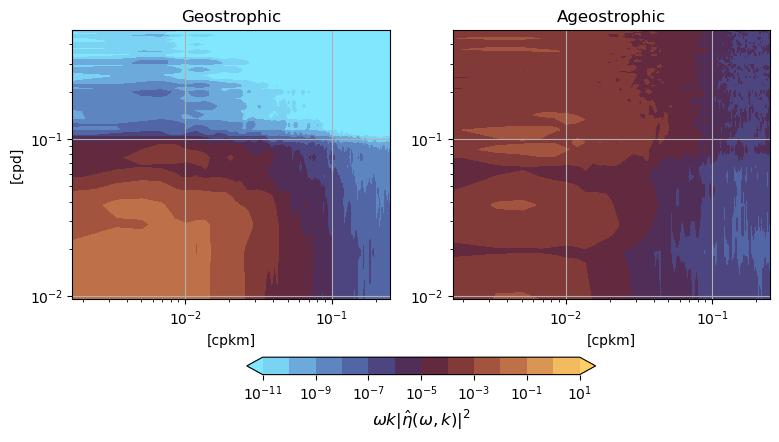

In [66]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fg.freq_num_lines.isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fg.freq_time.isel(freq_time=slice(len(Fg.freq_time)//2,
                                                 None)).values*86400,
               (Fg.freq_num_lines*Fg.freq_time*Fg
               ).isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,None),
                      freq_time=slice(len(Fg.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fa.freq_num_lines.isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fa.freq_time.isel(freq_time=slice(len(Fa.freq_time)//2,
                                                 None)).values*86400,
               (Fa.freq_num_lines*Fa.freq_time*Fa
               ).isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,None),
                      freq_time=slice(len(Fa.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fg.freq_num_lines.where(Fg.freq_num_lines>0.).min()*1e3,
              Fg.freq_num_lines.where(Fg.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fg.freq_time.where(Fg.freq_time>0.).min()*86400,
              Fg.freq_time.where(Fg.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fa.freq_num_lines.where(Fa.freq_num_lines>0.).min()*1e3,
              Fa.freq_num_lines.where(Fa.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fa.freq_time.where(Fa.freq_time>0.).min()*86400,
              Fa.freq_time.where(Fa.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"$\omega k |\hat{\eta}(\omega,k)|^2$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_CC.pdf"))

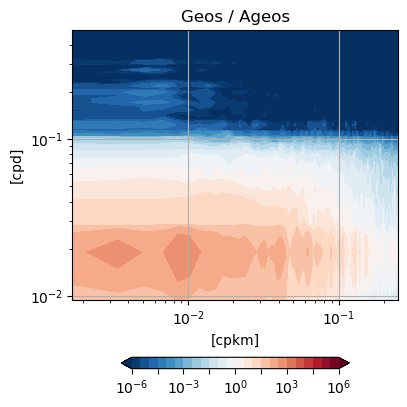

In [161]:
fig, ax = plt.subplots(figsize=(4.2,5))
# fig.set_tight_layout(True)
im = ax.contourf(Fg.freq_num_lines.isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fg.freq_time.isel(freq_time=slice(len(Fg.freq_time)//2,
                                                 None)).values*86400,
               ((Fg.freq_num_lines*Fg.freq_time*Fg
                ).isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,None),
                       freq_time=slice(len(Fg.freq_time)//2,None)
                      ).values.T
                / (Fa.freq_num_lines*Fa.freq_time*Fa
               ).isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,None),
                      freq_time=slice(len(Fa.freq_time)//2,None)
                     ).values.T
               ),
               levels=np.logspace(-6,6,25),
               norm=clr.LogNorm(), cmap="RdBu_r",
               extend="both",
               rasterized=True
              )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([Fg.freq_num_lines.where(Fg.freq_num_lines>0.).min()*1e3,
              Fg.freq_num_lines.where(Fg.freq_num_lines>0.).max()*1e3])
ax.set_ylim([Fg.freq_time.where(Fg.freq_time>0.).min()*86400,
              Fg.freq_time.where(Fg.freq_time>0.).max()*86400])
ax.set_xlabel(r"[cpkm]")
ax.set_ylabel(r"[cpd]")
ax.grid(True)
ax.set_title(r"Geos / Ageos")
cbar = fig.colorbar(im, ax=ax, orientation="horizontal", shrink=.7)
plt.savefig(op.join(ddir,"../Figs/omega-k_CC-ratio.pdf"))

In [61]:
dsv6 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass026/SSVs_SwotDiag.zarr"))
dsv3 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass013/SSVs_SwotDiag.zarr"))
dsv6r = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass026/SSVs_rawSwotDiag.zarr"))
dsv3r = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass013/SSVs_rawSwotDiag.zarr"))
dsv6, dsv3

(<xarray.Dataset> Size: 3GB
 Dimensions:     (cycle_num: 105, num_lines: 9310, num_pixels: 61)
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
     longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
 Data variables:
     strain      (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     ucg         (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     ug          (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     vcg         (cycle_num, num_lines, num_pixels) float64 477MB das

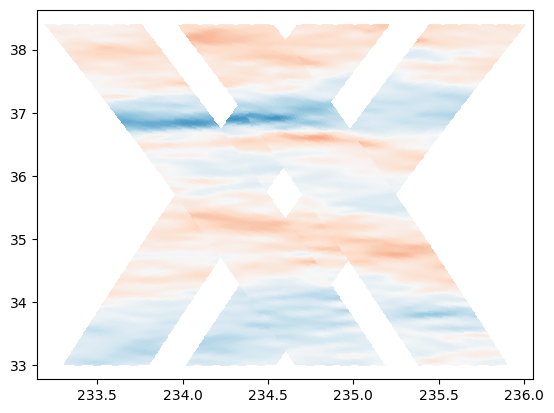

In [62]:
# u3 = dsv3.ucg.where(~maskn3,drop=True).where(~masks3,drop=True)
# u6 = dsv6.ucg.where(~maskn6,drop=True).where(~masks6,drop=True)
u3 = dsv3.ug.where(~maskn3,drop=True).where(~masks3,drop=True)
u6 = dsv6.ug.where(~maskn6,drop=True).where(~masks6,drop=True)

fig, ax = plt.subplots()
ax.pcolormesh(u3.longitude, u3.latitude,
              u3.isel(cycle_num=11),
              vmax=.8, vmin=-.8, cmap="RdBu_r",
              rasterized=True
             )
ax.pcolormesh(u6.longitude, u6.latitude,
              u6.isel(cycle_num=11),
              vmax=.8, vmin=-.8, cmap="RdBu_r",
              rasterized=True
             )

In [64]:
# sp3 = np.sqrt(dsv3.ucg**2 + dsv3.vcg**2).where(~maskn3,drop=True).where(~masks3,drop=True)
# sp6 = np.sqrt(dsv6.ucg**2 + dsv6.vcg**2).where(~maskn6,drop=True).where(~masks6,drop=True)
sp3 = np.sqrt(dsv3.ug**2 + dsv3.vg**2).where(~maskn3,drop=True).where(~masks3,drop=True)
sp6 = np.sqrt(dsv6.ug**2 + dsv6.vg**2).where(~maskn6,drop=True).where(~masks6,drop=True)
v3 = dsv3.vort.where(~maskn3,drop=True).where(~masks3,drop=True)
s3 = dsv3.strain.where(~maskn3,drop=True).where(~masks3,drop=True)
v6 = dsv6.vort.where(~maskn6,drop=True).where(~masks6,drop=True)
s6 = dsv6.strain.where(~maskn6,drop=True).where(~masks6,drop=True)
v3r = dsv3r.vort.where(~maskn3,drop=True
                      ).where(~masks3,drop=True
                             ).isel(num_pixels=slice(4,-4),
                                    num_lines=slice(1,-1)
                                   ).dropna("cycle_num", how="all")
s3r = dsv3r.strain.where(~maskn3,drop=True
                        ).where(~masks3,drop=True
                               ).isel(num_pixels=slice(4,-4),
                                      num_lines=slice(1,-1)
                                     ).dropna("cycle_num", how="all")
v6r = dsv6r.vort.where(~maskn6,drop=True
                      ).where(~masks6,drop=True
                             ).isel(num_pixels=slice(4,-4),
                                    num_lines=slice(1,-1)
                                   ).dropna("cycle_num", how="all")
s6r = dsv6r.strain.where(~maskn6,drop=True
                        ).where(~masks6,drop=True
                               ).isel(num_pixels=slice(4,-4),
                                      num_lines=slice(1,-1)
                                     ).dropna("cycle_num", how="all")
v3, v3r

(<xarray.DataArray 'vort' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 6776 6777 6778 6779 ... 7092 7093 7094
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 156kB 33.0 33.0 ... 38.39 38.38
     longitude   (num_lines, num_pixels) float64 156kB 233.3 233.3 ... 236.0,
 <xarray.DataArray 'vort' (cycle_num: 91, num_lines: 319, num_pixels: 61)> Size: 14MB
 dask.array<getitem, shape=(91, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 728B 474 478 479 480 481 ... 574 575 576 577
   * num_lines   (num_lines) int64 3kB 6776 6777 6778 6779 ... 7092 7093 7094
   * num_pixels  (num_pixels) in

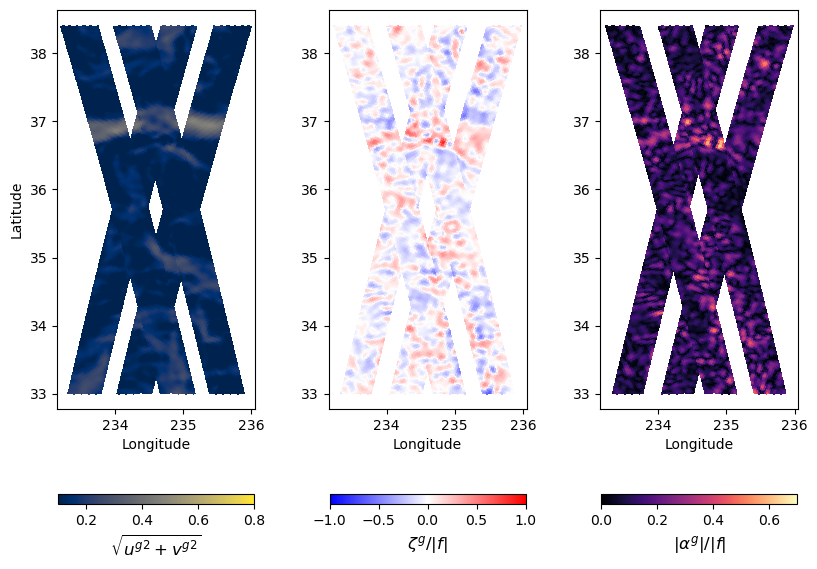

In [65]:
fig, (ax0, ax1,ax2) = plt.subplots(figsize=(9,6), nrows=1, ncols=3)
fig.set_tight_layout(True)
ax0.pcolormesh(sp3.isel(cycle_num=cnum).longitude, sp3.isel(cycle_num=cnum).latitude,
               sp3.isel(cycle_num=cnum),
               vmin=.1, vmax=.8, cmap="cividis",
               rasterized=True)
im0 = ax0.pcolormesh(sp6.isel(cycle_num=cnum).longitude, sp6.isel(cycle_num=cnum).latitude,
               sp6.isel(cycle_num=cnum),
               vmin=.1, vmax=.8, cmap="cividis",
               rasterized=True)
ax1.pcolormesh(v3.isel(cycle_num=cnum).longitude, v3.isel(cycle_num=cnum).latitude,
               (v3.isel(cycle_num=cnum) 
                / np.abs(gsw.f(v3.isel(cycle_num=cnum).latitude))),
               vmin=-1, vmax=1, cmap="bwr",
               rasterized=True)
im1 = ax1.pcolormesh(v6.isel(cycle_num=cnum).longitude, v6.isel(cycle_num=cnum).latitude,
               (v6.isel(cycle_num=cnum) 
                / np.abs(gsw.f(v6.isel(cycle_num=cnum).latitude))),
               vmin=-1, vmax=1, cmap="bwr",
               rasterized=True)
ax2.pcolormesh(s3.isel(cycle_num=cnum).longitude, s3.isel(cycle_num=cnum).latitude,
               (s3.isel(cycle_num=cnum) 
                / np.abs(gsw.f(s3.isel(cycle_num=cnum).latitude))),
               vmax=.7, vmin=0., cmap="magma",
               rasterized=True)
im2 = ax2.pcolormesh(s6.isel(cycle_num=cnum).longitude, s6.isel(cycle_num=cnum).latitude,
               (s6.isel(cycle_num=cnum) 
                / np.abs(gsw.f(s6.isel(cycle_num=cnum).latitude))),
               vmax=.7, vmin=0., cmap="magma",
               rasterized=True)
ax0.set_aspect("equal")
ax1.set_aspect("equal")
ax2.set_aspect("equal")
ax0.set_xlabel(r"Longitude")
ax1.set_xlabel(r"Longitude")
ax0.set_ylabel(r"Latitude")
ax2.set_xlabel(r"Longitude")
cbar0 = fig.colorbar(im0, ax=ax0, orientation="horizontal", shrink=.6)
cbar1 = fig.colorbar(im1, ax=ax1, orientation="horizontal", shrink=.6)
cbar2 = fig.colorbar(im2, ax=ax2, orientation="horizontal", shrink=.6)
cbar0.set_label(r"$\sqrt{{u^g}^2 + {v^g}^2}$", fontsize=12)
cbar1.set_label(r"$\zeta^g/|f|$", fontsize=12)
cbar2.set_label(r"$|\alpha^g|/|f|$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/vort-strain-CC.pdf"))

In [70]:
vort = xr.concat([v3.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  v6.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
strain = xr.concat([s3.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  s6.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
f = gsw.f(vort.latitude)
vort_raw = xr.concat([v3r.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  v6r.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
str_raw = xr.concat([s3r.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  s6r.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
fr = gsw.f(vort_raw.latitude)
vort, strain, f

(<xarray.DataArray 'vort' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 dask.array<concatenate, shape=(210, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (cycle_num, num_lines, num_pixels) float64 33MB 33.0 ... 32.79
     longitude  (cycle_num, num_lines, num_pixels) float64 33MB 233.3 ... 234.7
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'strain' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 dask.array<concatenate, shape=(210, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (cycle_num, num_lines, num_pixels) float64 33MB 33.0 ... 32.79
     longitude  (cycle_num, num_lines, num_pixels) float64 33MB 233.3 ... 234.7
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'latitude' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 array([[[7.94417138e-05, 7.943

In [71]:
vbins = np.linspace(-3e0,3e0,60)
sbins = np.linspace(0,3e0,30)
hist_c = xhist((strain / np.abs(f)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort / np.abs(f)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()
hist_r = xhist((str_raw / np.abs(fr)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort_raw / np.abs(fr)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()

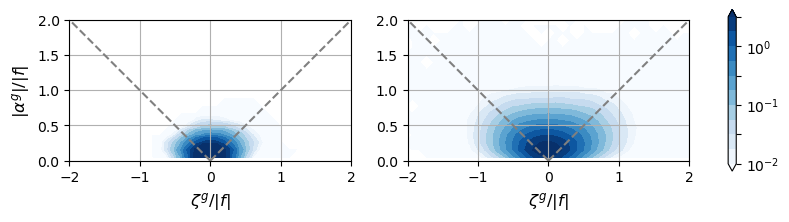

In [72]:
fig, axes = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
# fig.set_tight_layout(True)

im = axes[0].contourf(hist_c.vort_bin,
                 hist_c.strain_bin,
                 hist_c, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )
axes[1].contourf(hist_r.vort_bin,
                 hist_r.strain_bin,
                 hist_r, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )

# for c in im.collections:
#     c.set_rasterized(True)

axes[0].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[0].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')
axes[1].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[1].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')

axes[0].set_xlim([-2,2])
axes[0].set_ylim([0,2])
axes[1].set_xlim([-2,2])
axes[1].set_ylim([0,2])

axes[0].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[1].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[0].set_ylabel(r"$|\alpha^g|/|f|$", fontsize=12)

axes[0].grid(True)
axes[0].set_aspect('equal')
axes[1].grid(True)
axes[1].set_aspect('equal')

# fig.subplots_adjust(hspace=.06, wspace=.12)
# cbar = fig.colorbar(im, orientation='horizontal', ax=axes, shrink=.4, 
#                     ticks=[1e-4,1e-3,1e-2,1e-1,1e0])
cbar = fig.colorbar(im, ax=axes, shrink=.7)
# cbar.set_ticks([1e-2,1e-1,0,1])

plt.savefig(op.join(ddir,"../Figs/vort-strain-CCjointPDF.pdf"))

# Med Sea

In [4]:
ds03 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 3))
ds03.coords["num_lines"] = ("num_lines",range(len(ds03.num_lines)))
ds03.coords["num_pixels"] = ("num_pixels",range(len(ds03.num_pixels)))

ds16 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 16))
ds16.coords["num_lines"] = ("num_lines",range(len(ds16.num_lines)))
ds16.coords["num_pixels"] = ("num_pixels",range(len(ds16.num_pixels)))
ds03,ds16

(<xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
     longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 571MB dask.array<chunksize=(1, 9860, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels  

In [5]:
maskn3 = xr.DataArray(ds03.latitude.where(ds03.latitude<43.5).where(ds03.longitude>0.).to_masked_array().mask,
                     dims=ds03.latitude.dims,
                     coords=ds03.latitude.coords
                    )
masks3 = xr.DataArray(ds03.latitude.where(ds03.latitude>36.5).where(ds03.longitude>0.).to_masked_array().mask,
                     dims=ds03.latitude.dims,
                     coords=ds03.latitude.coords
                    )
# maskh3 = xr.DataArray(ds03.ssha_detided.to_masked_array().mask,
#                       dims=ds03.ssha_detided.dims,
#                       coords=ds03.ssha_detided.coords
#                      )

maskn6 = xr.DataArray(ds16.latitude.where(ds16.latitude<43.5).where(ds16.longitude>0.).to_masked_array().mask,
                     dims=ds16.latitude.dims,
                     coords=ds16.latitude.coords
                    )
masks6 = xr.DataArray(ds16.latitude.where(ds16.latitude>36.5).where(ds16.longitude>0.).to_masked_array().mask,
                     dims=ds16.latitude.dims,
                     coords=ds16.latitude.coords
                    )
# maskh6 = xr.DataArray(ds16.ssha_detided.to_masked_array().mask,
#                       dims=ds16.ssha_detided.dims,
#                       coords=ds16.ssha_detided.coords
#                      )
low03 = xr.open_zarr(op.join(ddir,"CalVal/geos/wMedSea/Pass%03d/SSHa.zarr" 
                               % 3)
                      ).ssha.where(~maskn3,drop=True).where(~masks3,drop=True)
low16 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
                               % 16)
                      ).ssha.where(~maskn6,drop=True).where(~masks6,drop=True)
# low03 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
#                                % 3)
#                       ).ssha.where(~maskh3).where(~maskn3,drop=True).where(~masks3,drop=True)
# low16 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
#                                % 16)
#                       ).ssha.where(~maskh6).where(~maskn6,drop=True).where(~masks6,drop=True)
low03, low16

(<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 414, num_pixels: 61)> Size: 21MB
 dask.array<where, shape=(105, 414, 61), dtype=float64, chunksize=(1, 414, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 6974 6975 6976 6977 ... 7385 7386 7387
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 202kB 36.51 36.5 ... 43.5 43.5
     longitude   (num_lines, num_pixels) float64 202kB 2.701 2.723 ... 6.296,
 <xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 414, num_pixels: 61)> Size: 21MB
 dask.array<where, shape=(105, 414, 61), dtype=float64, chunksize=(1, 414, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 2474 2475 2476 2477 ... 2885 2886 2887
   * num_pixels  (num_pixels) int

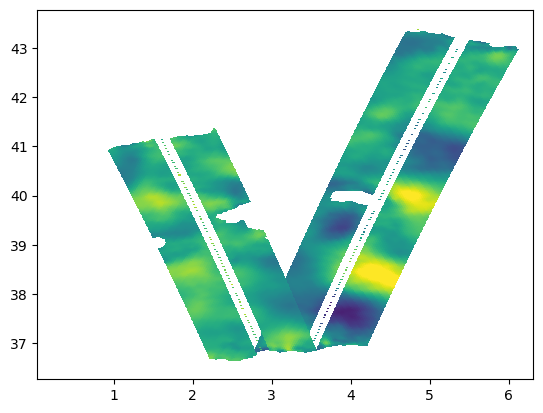

In [6]:
fig, ax = plt.subplots()
ax.pcolormesh(low03.longitude, low03.latitude,
              low03.sel(cycle_num=535),
              vmax=.15, vmin=0, 
              rasterized=True
             )
ax.pcolormesh(low16.longitude, low16.latitude,
              low16.sel(cycle_num=535),
              vmax=.15, vmin=0, 
              rasterized=True
             )

In [7]:
dsv6 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass016/SSVs_SwotDiag.zarr")
                   ).where(~maskn6,drop=True).where(~masks6,drop=True)
dsv3 = xr.open_zarr(op.join(ddir,"CalVal/geos/wMedSea/Pass003/SSVs_SwotDiag.zarr")
                   ).where(~maskn3,drop=True).where(~masks3,drop=True)
# dsv6 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass016/SSVs_SwotDiag.zarr")
#                    ).where(~maskh6,drop=True)
# dsv3 = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass003/SSVs_SwotDiag.zarr")
#                    ).where(~maskh3,drop=True)
dsv6

<xarray.Dataset> Size: 128MB
Dimensions:     (cycle_num: 105, num_lines: 414, num_pixels: 61)
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 3kB 2474 2475 2476 2477 ... 2885 2886 2887
  * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
    latitude    (num_lines, num_pixels) float64 202kB 43.77 43.76 ... 36.28
    longitude   (num_lines, num_pixels) float64 202kB 1.493 1.469 ... 2.362 2.34
Data variables:
    strain      (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 414, 61), meta=np.ndarray>
    ucg         (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 414, 61), meta=np.ndarray>
    ug          (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 414, 61), meta=np.ndarray>
    vcg         (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 414, 61), meta=np.ndarray>
    vg          (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 414, 61), meta=np.ndarray>
    vort        (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 414, 61), meta=np.ndarray>

In [8]:
wMed3 = xr.merge([low03.to_dataset(name="sshg"),dsv3])
wMed6 = xr.merge([low16.to_dataset(name="sshg"),dsv6])
wMed6

<xarray.Dataset> Size: 149MB
Dimensions:     (cycle_num: 105, num_lines: 414, num_pixels: 61)
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 3kB 2474 2475 2476 2477 ... 2885 2886 2887
  * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
    latitude    (num_lines, num_pixels) float64 202kB 43.77 43.76 ... 36.28
    longitude   (num_lines, num_pixels) float64 202kB 1.493 1.469 ... 2.362 2.34
Data variables:
    sshg        (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 414, 61), meta=np.ndarray>
    strain      (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 414, 61), meta=np.ndarray>
    ucg         (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 414, 61), meta=np.ndarray>
    ug          (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 414, 61), meta=np.ndarray>
    vcg         (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 414, 61), meta=np.ndarray>
    vg          (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 414, 61), meta=np.ndarray>
    vort        (cycle_num, num_lines, num_pixels) float64 21MB dask.array<chunksize=(1, 414, 61), meta=np.ndarray>

In [9]:
wMed3.to_zarr(op.join(ddir,"CalVal/geos/westMed/SSVs_pass003.zarr"), 
              mode="w")
wMed6.to_zarr(op.join(ddir,"CalVal/geos/westMed/SSVs_pass016.zarr"), 
              mode="w")

# Philip Sea

## SWOT

In [4]:
ds06 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/HYCOM/CalVal_pass%03d_v2.0.1.zarr"
                            % 6))
ds06.coords["num_lines"] = ("num_lines",range(len(ds06.num_lines)))
ds06.coords["num_pixels"] = ("num_pixels",range(len(ds06.num_pixels)))

ds21 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/HYCOM/CalVal_pass%03d_v2.0.1.zarr"
                            % 21))
ds21.coords["num_lines"] = ("num_lines",range(len(ds21.num_lines)))
ds21.coords["num_pixels"] = ("num_pixels",range(len(ds21.num_pixels)))

ds21

<xarray.Dataset> Size: 582MB
Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
Coordinates:
  * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
  * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
    latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
    longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
Data variables:
    ssha_detided  (cycle_num, num_lines, num_pixels) float64 571MB dask.array<chunksize=(1, 9860, 69), meta=np.ndarray>

In [5]:
maskn6 = xr.DataArray(ds06.latitude.where(ds06.latitude<30.).to_masked_array().mask,
                     dims=ds06.latitude.dims,
                     coords=ds06.latitude.coords
                    )
masks6 = xr.DataArray(ds06.latitude.where(ds06.latitude>20).to_masked_array().mask,
                     dims=ds06.latitude.dims,
                     coords=ds06.latitude.coords
                    )
xo06 = ds06.where(~maskn6,drop=True).where(~masks6,drop=True)

maskn1 = xr.DataArray(ds21.latitude.where(ds21.latitude<30.).to_masked_array().mask,
                     dims=ds21.latitude.dims,
                     coords=ds21.latitude.coords
                    )
masks1 = xr.DataArray(ds21.latitude.where(ds21.latitude>20).to_masked_array().mask,
                     dims=ds21.latitude.dims,
                     coords=ds21.latitude.coords
                    )
xo21 = ds21.where(~maskn1,drop=True).where(~masks1,drop=True)

# maskn1d = xr.DataArray(ds21d.latitude.where(ds21d.latitude<30.).to_masked_array().mask,
#                      dims=ds21d.latitude.dims,
#                      coords=ds21d.latitude.coords
#                     )
# masks1d = xr.DataArray(ds21d.latitude.where(ds21d.latitude>20).to_masked_array().mask,
#                      dims=ds21d.latitude.dims,
#                      coords=ds21d.latitude.coords
#                     )
# xo21d = ds21d.where(~maskn1d,drop=True).where(~masks1d,drop=True)
xo21

<xarray.Dataset> Size: 34MB
Dimensions:       (cycle_num: 105, num_lines: 574, num_pixels: 69)
Coordinates:
  * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines     (num_lines) int64 5kB 6045 6046 6047 6048 ... 6616 6617 6618
  * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
    latitude      (num_lines, num_pixels) float64 317kB 20.02 20.01 ... 29.99
    longitude     (num_lines, num_pixels) float64 317kB 127.8 127.8 ... 131.1
Data variables:
    ssha_detided  (cycle_num, num_lines, num_pixels) float64 33MB dask.array<chunksize=(1, 574, 69), meta=np.ndarray>

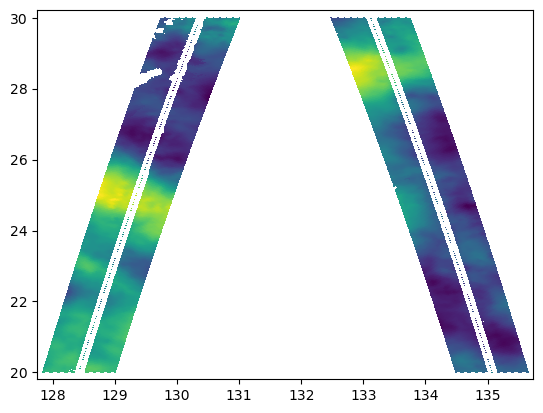

In [10]:
fig, ax = plt.subplots()
ax.pcolormesh(xo06.longitude, xo06.latitude,
              xo06.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )
ax.pcolormesh(xo21.longitude, xo21.latitude,
              xo21.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )

In [6]:
inp = 3

mask06 = xr.DataArray(xo06.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo06.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo06.ssha_detided.isel(cycle_num=0).coords
                    )
mm06 = xr.DataArray(mask06.where(mask06<.5
                              ).to_masked_array().mask,
                   dims=xo06.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo06.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mask21 = xr.DataArray(xo21.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo21.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo21.ssha_detided.isel(cycle_num=0).coords
                    )
mm21 = xr.DataArray(mask21.where(mask21<.5
                              ).to_masked_array().mask,
                   dims=xo21.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo21.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
# mask21d = xr.DataArray(xo21d.ssha_detided.to_masked_array().mask.mean(axis=0), 
#                      dims=xo21d.ssha_detided.isel(cycle_num=0).dims, 
#                      coords=xo21d.ssha_detided.isel(cycle_num=0).coords
#                     )
# mm21d = xr.DataArray(mask21d.where(mask21d<.5
#                               ).to_masked_array().mask,
#                    dims=xo21d.ssha_detided.isel(cycle_num=0).dims, 
#                    coords=xo21d.ssha_detided.isel(cycle_num=0).coords
#                   ).isel(num_pixels=slice(inp,-inp))
mm21

<xarray.DataArray (num_lines: 574, num_pixels: 63)> Size: 36kB
array([[ True, False, False, ...,  True,  True,  True],
       [ True, False, False, ...,  True,  True,  True],
       [ True, False, False, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ..., False, False,  True],
       [ True,  True,  True, ..., False, False,  True],
       [ True,  True,  True, ...,  True, False,  True]], shape=(574, 63))
Coordinates:
  * num_lines   (num_lines) int64 5kB 6045 6046 6047 6048 ... 6616 6617 6618
  * num_pixels  (num_pixels) int64 504B 3 4 5 6 7 8 9 ... 59 60 61 62 63 64 65
    cycle_num   int64 8B 474
    latitude    (num_lines, num_pixels) float64 289kB 20.01 20.01 ... 30.0 30.0
    longitude   (num_lines, num_pixels) float64 289kB 127.8 127.8 ... 131.0

In [7]:
low06 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass%03d/SSHa.zarr" 
                             % 6)
                    ).ssha.where(~maskn6,drop=True
                                ).where(~masks6,drop=True)
low21 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass%03d/SSHa.zarr" 
                             % 21)
                    ).ssha.where(~maskn1,drop=True
                                ).where(~masks1,drop=True)
low21h = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass%03d/HRET/SSHa.zarr" 
                             % 21)
                    ).ssha.where(~maskn1,drop=True
                                ).where(~masks1,drop=True)
low21d = xr.open_zarr(op.join(ddir,"SWOT_no_IT/10D_rolling/CalVal_pass%03d_v2.0.1.zarr"
                              % 21)
                     ).ssha_detided.where(~maskn1,drop=True
                                         ).where(~masks1,drop=True
                                                ).isel(num_pixels=slice(inp+1,-inp-1)
                                                      )*1e-2
low21, low21d

(<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 574, num_pixels: 61)> Size: 29MB
 dask.array<where, shape=(105, 574, 61), dtype=float64, chunksize=(1, 574, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 5kB 6045 6046 6047 6048 ... 6616 6617 6618
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 280kB 20.01 20.0 ... 30.0 30.0
     longitude   (num_lines, num_pixels) float64 280kB 127.8 127.9 ... 131.0,
 <xarray.DataArray 'ssha_detided' (cycle_num: 96, num_lines: 574, num_pixels: 61)> Size: 27MB
 dask.array<mul, shape=(96, 574, 61), dtype=float64, chunksize=(1, 574, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 768B 483 484 485 486 487 ... 575 576 577 578
   * num_lines   (num_lines) int64 5kB 6045 6046 6047 6048 ... 6616 6617 6618
   * num_pixels  (num_pixels)

In [8]:
r_ref6 = (~mm06).sum() / np.prod(mm06.shape)
r_ref1 = (~mm21).sum() / np.prod(mm21.shape)
r_ref1

<xarray.DataArray ()> Size: 8B
array(0.81765389)
Coordinates:
    cycle_num  int64 8B 474

In [26]:
ageo = (1e-2*ds21.ssha_detided
        - low21
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low21.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r21 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r21 = xr.concat([r21, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref1:
        if ic == 0:
            a21 = ssha
        else:
            try:
                a21 = xr.concat([a21, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a21.coords["cycle_num"] = ("cycle_num",
                           r21.where(r21>0.7*r_ref1, drop=True).cycle_num.data
                          )

dsa21 = a21.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa21.coords["y"] = ("y",range(len(dsa21.y)))
dsa21.coords["x"] = ("x",range(len(dsa21.x)))
if not dsa21.rio.crs:
    dsa21 = dsa21.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa21.ssha.rio.nodata is None:
    dsa21["ssha"] = dsa21.ssha.rio.write_nodata(np.nan)
_a21_exterp = dsa21.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a21_interp = _a21_exterp.interp(cycle_num=ds21.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a21_exterp = _a21_exterp.where(mm21.isel(num_pixels=slice(1,-1),
                                         # num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds21.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa21.close()

dsg21 = low21.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 
                                                 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg21.coords["y"] = ("y",range(len(dsg21.y)))
dsg21.coords["x"] = ("x",range(len(dsg21.x)))
if not dsg21.rio.crs:
    dsg21 = dsg21.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg21.ssha.rio.nodata is None:
    dsg21["ssha"] = dsg21.ssha.rio.write_nodata(np.nan)
_g21_exterp = dsg21.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g21_interp = _g21_exterp.interp(cycle_num=ds21.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g21_exterp = _g21_exterp.where(mm21.isel(num_pixels=slice(1,-1),
                                         # num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds21.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg21.close()

In [27]:
ageo = (1e-2*ds21.ssha_detided
        - low21d
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low21d.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r21 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r21 = xr.concat([r21, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref1:
        if ic == 0:
            a21 = ssha
        else:
            try:
                a21 = xr.concat([a21, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a21.coords["cycle_num"] = ("cycle_num",
                           r21.where(r21>0.7*r_ref1, drop=True).cycle_num.data
                          )

dsa21 = a21.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa21.coords["y"] = ("y",range(len(dsa21.y)))
dsa21.coords["x"] = ("x",range(len(dsa21.x)))
if not dsa21.rio.crs:
    dsa21 = dsa21.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa21.ssha.rio.nodata is None:
    dsa21["ssha"] = dsa21.ssha.rio.write_nodata(np.nan)
_a21d_exterp = dsa21.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a21d_interp = _a21d_exterp.interp(cycle_num=low21d.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a21d_exterp = _a21d_exterp.where(mm21.isel(num_pixels=slice(1,-1),
                                         # num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=low21d.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa21.close()

dsg21 = low21d.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 
                                                 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg21.coords["y"] = ("y",range(len(dsg21.y)))
dsg21.coords["x"] = ("x",range(len(dsg21.x)))
if not dsg21.rio.crs:
    dsg21 = dsg21.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg21.ssha.rio.nodata is None:
    dsg21["ssha"] = dsg21.ssha.rio.write_nodata(np.nan)
_g21d_exterp = dsg21.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g21d_interp = _g21d_exterp.interp(cycle_num=low21d.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g21d_exterp = _g21d_exterp.where(mm21.isel(num_pixels=slice(1,-1),
                                         # num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=low21d.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg21.close()

In [28]:
ageo = (1e-2*ds21.ssha_detided
        - low21h
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low21h.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r21 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r21 = xr.concat([r21, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref1:
        if ic == 0:
            a21 = ssha
        else:
            try:
                a21 = xr.concat([a21, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a21.coords["cycle_num"] = ("cycle_num",
                           r21.where(r21>0.7*r_ref1, drop=True).cycle_num.data
                          )

dsa21 = a21.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa21.coords["y"] = ("y",range(len(dsa21.y)))
dsa21.coords["x"] = ("x",range(len(dsa21.x)))
if not dsa21.rio.crs:
    dsa21 = dsa21.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa21.ssha.rio.nodata is None:
    dsa21["ssha"] = dsa21.ssha.rio.write_nodata(np.nan)
_a21h_exterp = dsa21.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a21h_interp = _a21h_exterp.interp(cycle_num=low21h.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a21h_exterp = _a21h_exterp.where(mm21.isel(num_pixels=slice(1,-1),
                                         # num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=low21h.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa21.close()

dsg21 = low21h.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 
                                                 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg21.coords["y"] = ("y",range(len(dsg21.y)))
dsg21.coords["x"] = ("x",range(len(dsg21.x)))
if not dsg21.rio.crs:
    dsg21 = dsg21.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg21.ssha.rio.nodata is None:
    dsg21["ssha"] = dsg21.ssha.rio.write_nodata(np.nan)
_g21h_exterp = dsg21.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g21h_interp = _g21h_exterp.interp(cycle_num=low21h.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g21h_exterp = _g21h_exterp.where(mm21.isel(num_pixels=slice(1,-1),
                                         # num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=low21h.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg21.close()

In [29]:
for cc in low21.cycle_num:
    if cc == low21.cycle_num[0]:
        # ar_g4 = g04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
        #                                          ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        # ar_a4 = a04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
        #                                          ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])

        ar_g1 = g21_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a1 = a21_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
    else:
        # ar_g4 = xr.concat([ar_g4, 
        #                   g04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
        #                                                    ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        #                  ], "time")
        # ar_a4 = xr.concat([ar_a4, 
        #                   a04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
        #                                                    ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        #                  ], "time")
        ar_g1 = xr.concat([ar_g1, 
                          g21_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a1 = xr.concat([ar_a1, 
                          a21_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")

# ar_g4.coords["time"] = ("time",np.arange(len(ar_g4.time))*24*60.*60)
# ar_a4.coords["time"] = ("time",np.arange(len(ar_a4.time))*24*60.*60)
ar_g1.coords["time"] = ("time",np.arange(len(ar_g1.time))*24*60.*60)
ar_a1.coords["time"] = ("time",np.arange(len(ar_a1.time))*24*60.*60)
# ar_g4.coords["num_lines"] = ("num_lines",np.arange(len(ar_g4.num_lines))*2e3)
# ar_a4.coords["num_lines"] = ("num_lines",np.arange(len(ar_a4.num_lines))*2e3)
ar_g1.coords["num_lines"] = ("num_lines",np.arange(len(ar_g1.num_lines))*2e3)
ar_a1.coords["num_lines"] = ("num_lines",np.arange(len(ar_a1.num_lines))*2e3)

ar_a1

<xarray.DataArray 'ssha' (time: 105, num_lines: 518, num_pixels: 2)> Size: 870kB
array([[[-0.0370778 , -0.00707544],
        [-0.03571363, -0.00739991],
        [-0.03435826, -0.00541472],
        ...,
        [ 0.00695112, -0.0081571 ],
        [ 0.01041189, -0.00158143],
        [ 0.0123767 ,  0.00515992]],

       [[-0.02807026,  0.0404197 ],
        [-0.02624543,  0.03879854],
        [-0.02377352,  0.03837756],
        ...,
        [ 0.00881983,  0.0191104 ],
        [ 0.01289954,  0.02124557],
        [ 0.01559333,  0.02994045]],

       [[-0.01906273,  0.08791485],
        [-0.01677723,  0.08499699],
        [-0.01318878,  0.08216984],
        ...,
...
        ...,
        [-0.15534567,  0.12797936],
        [-0.15141279,  0.12983215],
        [-0.14830787,  0.13054316]],

       [[ 0.06505107,  0.07871507],
        [ 0.06145929,  0.07793318],
        [ 0.05927211,  0.07528526],
        ...,
        [-0.10597351,  0.01075201],
        [-0.10499229,  0.01841203],
        [-0.10352901,  0.02649473]],

       [[ 0.0826992 ,  0.06314992],
        [ 0.0759166 ,  0.06281428],
        [ 0.06960769,  0.05975765],
        ...,
        [-0.05660136, -0.10647535],
        [-0.05857178, -0.09300809],
        [-0.05875014, -0.0775537 ]]], shape=(105, 518, 2))
Coordinates:
  * time         (time) float64 840B 0.0 8.64e+04 ... 8.899e+06 8.986e+06
  * num_lines    (num_lines) float64 4kB 0.0 2e+03 4e+03 ... 1.032e+06 1.034e+06
    spatial_ref  int64 8B 0
    latitude     (num_lines, num_pixels) float64 8kB 20.18 20.01 ... 29.99 29.79
    longitude    (num_lines, num_pixels) float64 8kB 127.9 129.0 ... 129.8 130.9
    cycle_num    (time) int64 840B 474 475 476 477 478 ... 574 575 576 577 578
Dimensions without coordinates: num_pixels
Attributes:
    _FillValue:  nan

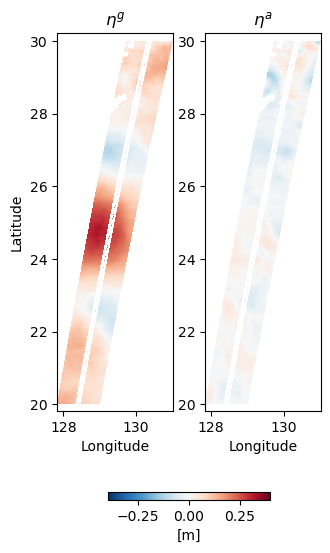

In [132]:
cnum = 20
fig, axes = plt.subplots(figsize=(3.5,7), nrows=1, ncols=2)
# fig.set_tight_layout(True)
# im = axes[0].pcolormesh(g04_exterp.isel(cycle_num=cnum).longitude, g04_exterp.isel(cycle_num=cnum).latitude,
#                g04_exterp.isel(cycle_num=cnum),
#                vmin=-.4, vmax=.4, cmap="RdBu_r",
#                rasterized=True)
im = axes[0].pcolormesh(g21_exterp.isel(cycle_num=cnum).longitude, g21_exterp.isel(cycle_num=cnum).latitude,
               g21_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
# axes[1].pcolormesh(a04_exterp.isel(cycle_num=cnum).longitude, a04_exterp.isel(cycle_num=cnum).latitude,
#                a04_exterp.isel(cycle_num=cnum),
#                vmin=-.4, vmax=.4, cmap="RdBu_r",
#                rasterized=True)
axes[1].pcolormesh(a21_exterp.isel(cycle_num=cnum).longitude, a21_exterp.isel(cycle_num=cnum).latitude,
               a21_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[0].set_aspect("equal")
axes[1].set_aspect("equal")
axes[0].set_xlabel(r"Longitude")
axes[0].set_ylabel(r"Latitude")
axes[1].set_xlabel(r"Longitude")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.6)
cbar.set_label(r"[m]")
axes[0].set_title(r"$\eta^g$")
axes[1].set_title(r"$\eta^a$")
plt.savefig(op.join(ddir,"../Figs/ssha-PS.pdf"))

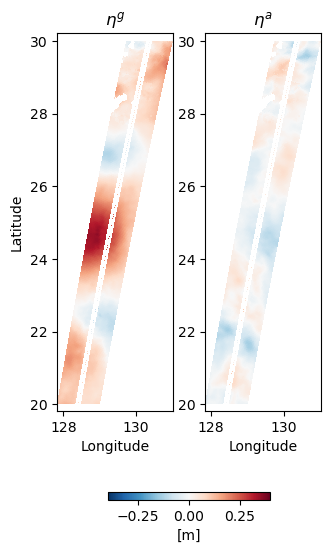

In [47]:
cnum = 20
fig, axes = plt.subplots(figsize=(3.5,7), nrows=1, ncols=2)
# fig.set_tight_layout(True)
# im = axes[0].pcolormesh(g04_exterp.isel(cycle_num=cnum).longitude, g04_exterp.isel(cycle_num=cnum).latitude,
#                g04_exterp.isel(cycle_num=cnum),
#                vmin=-.4, vmax=.4, cmap="RdBu_r",
#                rasterized=True)
im = axes[0].pcolormesh(g21d_exterp.isel(cycle_num=cnum).longitude, 
                        g21d_exterp.isel(cycle_num=cnum).latitude,
               g21d_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
# axes[1].pcolormesh(a04_exterp.isel(cycle_num=cnum).longitude, a04_exterp.isel(cycle_num=cnum).latitude,
#                a04_exterp.isel(cycle_num=cnum),
#                vmin=-.4, vmax=.4, cmap="RdBu_r",
#                rasterized=True)
axes[1].pcolormesh(a21d_exterp.isel(cycle_num=cnum).longitude, 
                   a21d_exterp.isel(cycle_num=cnum).latitude,
               a21d_exterp.isel(cycle_num=cnum),
               vmin=-.4, vmax=.4, cmap="RdBu_r",
               rasterized=True)
axes[0].set_aspect("equal")
axes[1].set_aspect("equal")
axes[0].set_xlabel(r"Longitude")
axes[0].set_ylabel(r"Latitude")
axes[1].set_xlabel(r"Longitude")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.6)
cbar.set_label(r"[m]")
axes[0].set_title(r"$\eta^g$")
axes[1].set_title(r"$\eta^a$")
plt.savefig(op.join(ddir,"../Figs/ssha10D-PS.pdf"))

In [30]:
# Fg4 = xrft.power_spectrum(ar_g4.reset_coords(drop=True).chunk({"num_pixels":1}), 
#                          dim=["time"], 
#                          detrend="linear", window="hann",
#                          window_correction=True
#                         )
# Fg4 = xrft.power_spectrum(Fg4.reset_coords(drop=True), 
#                          dim=["num_lines"], 
#                          detrend="linear", window="hann",
#                          window_correction=True
#                         ).mean("num_pixels")
# Fa4 = xrft.power_spectrum(ar_a4.reset_coords(drop=True).chunk({"num_pixels":1}), 
#                          dim=["time"], 
#                          detrend="linear", window="hann",
#                          window_correction=True
#                         )
# Fa4 = xrft.power_spectrum(Fa4.reset_coords(drop=True), 
#                          dim=["num_lines"], 
#                          detrend="linear", window="hann",
#                          window_correction=True
#                         ).mean("num_pixels")
Fg1 = xrft.power_spectrum(ar_g1.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg1 = xrft.power_spectrum(Fg1.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa1 = xrft.power_spectrum(ar_a1.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa1 = xrft.power_spectrum(Fa1.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
# Fa = .5*(Fa4 + Fa9)
# Fg = .5*(Fg4 + Fg9)
Fa = Fa1
Fg = Fg1
Fg, Fa

(<xarray.DataArray 'rechunk-merge-0067e28f6e0bf551d743b8edaadaa270' (
                                                                     freq_time: 105,
                                                                     freq_num_lines: 518)> Size: 435kB
 dask.array<mean_agg-aggregate, shape=(105, 518), dtype=float64, chunksize=(105, 518), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 4kB -0.00025 -0.000249 ... 0.000249,
 <xarray.DataArray 'rechunk-merge-981877dbe1c1fb8e9816f09adf4df92b' (
                                                                     freq_time: 105,
                                                                     freq_num_lines: 518)> Size: 435kB
 dask.array<mean_agg-aggregate, shape=(105, 518), dtype=float64, chunksize=(105, 518), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06

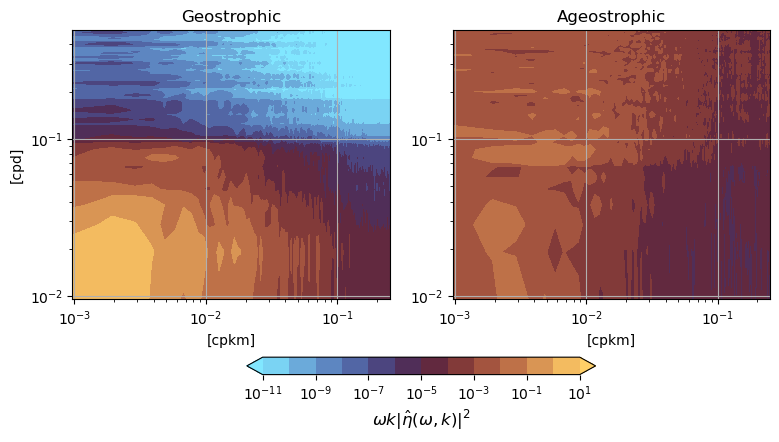

In [134]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fg.freq_num_lines.isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fg.freq_time.isel(freq_time=slice(len(Fg.freq_time)//2,
                                                 None)).values*86400,
               (Fg.freq_num_lines*Fg.freq_time*Fg
               ).isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,None),
                      freq_time=slice(len(Fg.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fa.freq_num_lines.isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fa.freq_time.isel(freq_time=slice(len(Fa.freq_time)//2,
                                                 None)).values*86400,
               (Fa.freq_num_lines*Fa.freq_time*Fa
               ).isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,None),
                      freq_time=slice(len(Fa.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fg.freq_num_lines.where(Fg.freq_num_lines>0.).min()*1e3,
              Fg.freq_num_lines.where(Fg.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fg.freq_time.where(Fg.freq_time>0.).min()*86400,
              Fg.freq_time.where(Fg.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fa.freq_num_lines.where(Fa.freq_num_lines>0.).min()*1e3,
              Fa.freq_num_lines.where(Fa.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fa.freq_time.where(Fa.freq_time>0.).min()*86400,
              Fa.freq_time.where(Fa.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"$\omega k |\hat{\eta}(\omega,k)|^2$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_PS.pdf"))

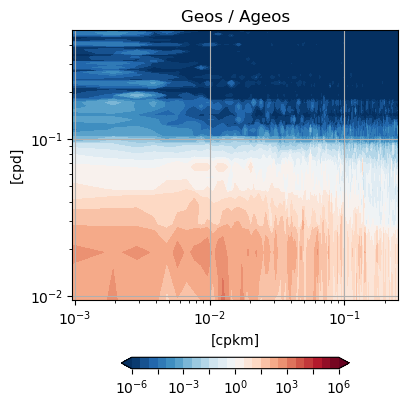

In [193]:
fig, ax = plt.subplots(figsize=(4.2,5))
# fig.set_tight_layout(True)
im = ax.contourf(Fg.freq_num_lines.isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fg.freq_time.isel(freq_time=slice(len(Fg.freq_time)//2,
                                                 None)).values*86400,
               ((Fg.freq_num_lines*Fg.freq_time*Fg
                ).isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,None),
                       freq_time=slice(len(Fg.freq_time)//2,None)
                      ).values.T
                / (Fa.freq_num_lines*Fa.freq_time*Fa
               ).isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,None),
                      freq_time=slice(len(Fa.freq_time)//2,None)
                     ).values.T
               ),
               levels=np.logspace(-6,6,25),
               norm=clr.LogNorm(), cmap="RdBu_r",
               extend="both",
               rasterized=True
              )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([Fg.freq_num_lines.where(Fg.freq_num_lines>0.).min()*1e3,
              Fg.freq_num_lines.where(Fg.freq_num_lines>0.).max()*1e3])
ax.set_ylim([Fg.freq_time.where(Fg.freq_time>0.).min()*86400,
              Fg.freq_time.where(Fg.freq_time>0.).max()*86400])
ax.set_xlabel(r"[cpkm]")
ax.set_ylabel(r"[cpd]")
ax.grid(True)
ax.set_title(r"Geos / Ageos")
cbar = fig.colorbar(im, ax=ax, orientation="horizontal", shrink=.7)
plt.savefig(op.join(ddir,"../Figs/omega-k_PS-ratio.pdf"))

In [31]:
for cc in low21d.cycle_num:
    if cc == low21d.cycle_num[0]:
        # ar_g4 = g04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
        #                                          ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        # ar_a4 = a04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
        #                                          ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])

        ar_g1d = g21d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a1d = a21d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
    else:
        # ar_g4 = xr.concat([ar_g4, 
        #                   g04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
        #                                                    ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        #                  ], "time")
        # ar_a4 = xr.concat([ar_a4, 
        #                   a04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
        #                                                    ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        #                  ], "time")
        ar_g1d = xr.concat([ar_g1d, 
                          g21d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a1d = xr.concat([ar_a1d, 
                          a21d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")

# ar_g4.coords["time"] = ("time",np.arange(len(ar_g4.time))*24*60.*60)
# ar_a4.coords["time"] = ("time",np.arange(len(ar_a4.time))*24*60.*60)
ar_g1d.coords["time"] = ("time",np.arange(len(ar_g1d.time))*24*60.*60)
ar_a1d.coords["time"] = ("time",np.arange(len(ar_a1d.time))*24*60.*60)
# ar_g4.coords["num_lines"] = ("num_lines",np.arange(len(ar_g4.num_lines))*2e3)
# ar_a4.coords["num_lines"] = ("num_lines",np.arange(len(ar_a4.num_lines))*2e3)
ar_g1d.coords["num_lines"] = ("num_lines",np.arange(len(ar_g1d.num_lines))*2e3)
ar_a1d.coords["num_lines"] = ("num_lines",np.arange(len(ar_a1d.num_lines))*2e3)

Fg1d = xrft.power_spectrum(ar_g1d.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg1d = xrft.power_spectrum(Fg1d.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa1d = xrft.power_spectrum(ar_a1d.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa1d = xrft.power_spectrum(Fa1d.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
# Fa = .5*(Fa4 + Fa9)
# Fg = .5*(Fg4 + Fg9)
Fad = Fa1d
Fgd = Fg1d
Fgd, Fad

(<xarray.DataArray 'rechunk-merge-e55d9d1f39f5f4d45cee739364a59de0' (
                                                                     freq_time: 96,
                                                                     freq_num_lines: 518)> Size: 398kB
 dask.array<mean_agg-aggregate, shape=(96, 518), dtype=float64, chunksize=(96, 518), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 768B -5.787e-06 -5.666e-06 ... 5.666e-06
   * freq_num_lines  (freq_num_lines) float64 4kB -0.00025 -0.000249 ... 0.000249,
 <xarray.DataArray 'rechunk-merge-07f83d7d3c306cbc8b5cce3fa553ea58' (
                                                                     freq_time: 96,
                                                                     freq_num_lines: 518)> Size: 398kB
 dask.array<mean_agg-aggregate, shape=(96, 518), dtype=float64, chunksize=(96, 518), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 768B -5.787e-06 -5.666e-06 ... 5

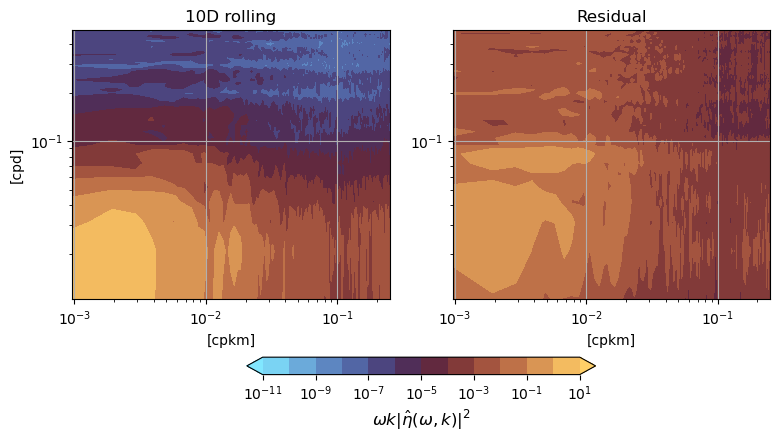

In [50]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fgd.freq_num_lines.isel(freq_num_lines=slice(len(Fgd.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fgd.freq_time.isel(freq_time=slice(len(Fgd.freq_time)//2,
                                                 None)).values*86400,
               (Fgd.freq_num_lines*Fgd.freq_time*Fgd
               ).isel(freq_num_lines=slice(len(Fgd.freq_num_lines)//2,None),
                      freq_time=slice(len(Fgd.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fad.freq_num_lines.isel(freq_num_lines=slice(len(Fad.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fad.freq_time.isel(freq_time=slice(len(Fad.freq_time)//2,
                                                 None)).values*86400,
               (Fad.freq_num_lines*Fad.freq_time*Fad
               ).isel(freq_num_lines=slice(len(Fad.freq_num_lines)//2,None),
                      freq_time=slice(len(Fad.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fgd.freq_num_lines.where(Fgd.freq_num_lines>0.).min()*1e3,
              Fgd.freq_num_lines.where(Fgd.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fgd.freq_time.where(Fgd.freq_time>0.).min()*86400,
              Fgd.freq_time.where(Fgd.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fad.freq_num_lines.where(Fad.freq_num_lines>0.).min()*1e3,
              Fad.freq_num_lines.where(Fad.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fad.freq_time.where(Fad.freq_time>0.).min()*86400,
              Fad.freq_time.where(Fad.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"10D rolling")
axes[1].set_title(r"Residual")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"$\omega k |\hat{\eta}(\omega,k)|^2$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_PS_10D.pdf"))

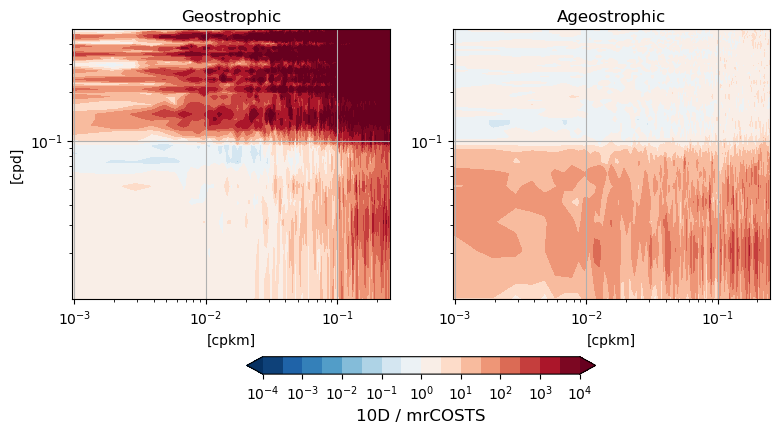

In [32]:
# Fgd, Fg.interp(freq_num_lines=Fgd.freq_num_lines,freq_time=Fgd.freq_time)
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fgd.freq_num_lines.isel(freq_num_lines=slice(len(Fgd.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fgd.freq_time.isel(freq_time=slice(len(Fgd.freq_time)//2,
                                                 None)).values*86400,
               (Fgd/Fg.interp(freq_time=Fgd.freq_time,
                              freq_num_lines=Fgd.freq_num_lines).data
               ).isel(freq_num_lines=slice(len(Fgd.freq_num_lines)//2,None),
                      freq_time=slice(len(Fgd.freq_time)//2,None)
                     ).values,
               levels=np.logspace(-4,4,17),
               norm=clr.LogNorm(), cmap="RdBu_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fad.freq_num_lines.isel(freq_num_lines=slice(len(Fad.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fad.freq_time.isel(freq_time=slice(len(Fad.freq_time)//2,
                                                 None)).values*86400,
               (Fad/Fa.interp(freq_time=Fgd.freq_time,
                              freq_num_lines=Fgd.freq_num_lines).data
               ).isel(freq_num_lines=slice(len(Fad.freq_num_lines)//2,None),
                      freq_time=slice(len(Fad.freq_time)//2,None)
                     ).values,
               levels=np.logspace(-4,4,17),
               norm=clr.LogNorm(), cmap="RdBu_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fgd.freq_num_lines.where(Fgd.freq_num_lines>0.).min()*1e3,
              Fgd.freq_num_lines.where(Fgd.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fgd.freq_time.where(Fgd.freq_time>0.).min()*86400,
              Fgd.freq_time.where(Fgd.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fad.freq_num_lines.where(Fad.freq_num_lines>0.).min()*1e3,
              Fad.freq_num_lines.where(Fad.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fad.freq_time.where(Fad.freq_time>0.).min()*86400,
              Fad.freq_time.where(Fad.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"10D / mrCOSTS", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_PS_10Dratio.pdf"))

In [33]:
for cc in low21h.cycle_num:
    if cc == low21h.cycle_num[0]:
        # ar_g4 = g04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
        #                                          ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        # ar_a4 = a04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
        #                                          ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])

        ar_g1h = g21h_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a1h = a21h_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
    else:
        # ar_g4 = xr.concat([ar_g4, 
        #                   g04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
        #                                                    ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        #                  ], "time")
        # ar_a4 = xr.concat([ar_a4, 
        #                   a04_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
        #                                                    ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        #                  ], "time")
        ar_g1h = xr.concat([ar_g1h, 
                          g21h_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a1h = xr.concat([ar_a1h, 
                          a21h_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")

# ar_g4.coords["time"] = ("time",np.arange(len(ar_g4.time))*24*60.*60)
# ar_a4.coords["time"] = ("time",np.arange(len(ar_a4.time))*24*60.*60)
ar_g1h.coords["time"] = ("time",np.arange(len(ar_g1h.time))*24*60.*60)
ar_a1h.coords["time"] = ("time",np.arange(len(ar_a1h.time))*24*60.*60)
# ar_g4.coords["num_lines"] = ("num_lines",np.arange(len(ar_g4.num_lines))*2e3)
# ar_a4.coords["num_lines"] = ("num_lines",np.arange(len(ar_a4.num_lines))*2e3)
ar_g1h.coords["num_lines"] = ("num_lines",np.arange(len(ar_g1h.num_lines))*2e3)
ar_a1h.coords["num_lines"] = ("num_lines",np.arange(len(ar_a1h.num_lines))*2e3)

Fg1h = xrft.power_spectrum(ar_g1h.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg1h = xrft.power_spectrum(Fg1h.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa1h = xrft.power_spectrum(ar_a1h.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa1h = xrft.power_spectrum(Fa1h.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")

Fah = Fa1h
Fgh = Fg1h
Fgh, Fah

(<xarray.DataArray 'rechunk-merge-6e9cc4141393258f7424868019c52b1d' (
                                                                     freq_time: 105,
                                                                     freq_num_lines: 518)> Size: 435kB
 dask.array<mean_agg-aggregate, shape=(105, 518), dtype=float64, chunksize=(105, 518), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 4kB -0.00025 -0.000249 ... 0.000249,
 <xarray.DataArray 'rechunk-merge-c22407d7d104344b9c887830736d5c3c' (
                                                                     freq_time: 105,
                                                                     freq_num_lines: 518)> Size: 435kB
 dask.array<mean_agg-aggregate, shape=(105, 518), dtype=float64, chunksize=(105, 518), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06

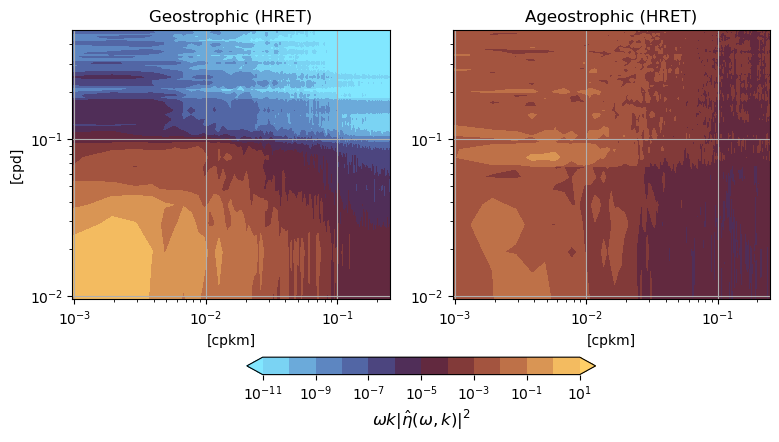

In [53]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fgh.freq_num_lines.isel(freq_num_lines=slice(len(Fgh.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fgh.freq_time.isel(freq_time=slice(len(Fgh.freq_time)//2,
                                                 None)).values*86400,
               (Fgh.freq_num_lines*Fgh.freq_time*Fgh
               ).isel(freq_num_lines=slice(len(Fgh.freq_num_lines)//2,None),
                      freq_time=slice(len(Fgh.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fah.freq_num_lines.isel(freq_num_lines=slice(len(Fah.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fah.freq_time.isel(freq_time=slice(len(Fah.freq_time)//2,
                                                 None)).values*86400,
               (Fah.freq_num_lines*Fah.freq_time*Fah
               ).isel(freq_num_lines=slice(len(Fah.freq_num_lines)//2,None),
                      freq_time=slice(len(Fah.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fgh.freq_num_lines.where(Fgh.freq_num_lines>0.).min()*1e3,
              Fgh.freq_num_lines.where(Fgh.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fgh.freq_time.where(Fgh.freq_time>0.).min()*86400,
              Fgh.freq_time.where(Fgh.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fah.freq_num_lines.where(Fah.freq_num_lines>0.).min()*1e3,
              Fah.freq_num_lines.where(Fah.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fah.freq_time.where(Fah.freq_time>0.).min()*86400,
              Fah.freq_time.where(Fah.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic (HRET)")
axes[1].set_title(r"Ageostrophic (HRET)")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"$\omega k |\hat{\eta}(\omega,k)|^2$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_PS_HRET.pdf"))

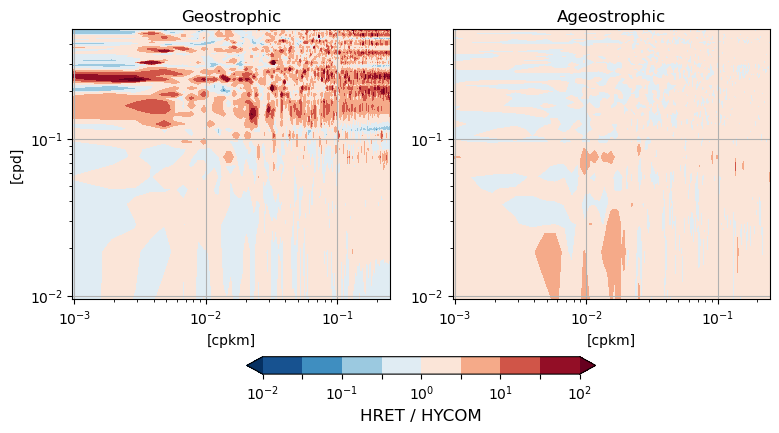

In [34]:
# Fgd, Fg.interp(freq_num_lines=Fgd.freq_num_lines,freq_time=Fgd.freq_time)
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fgh.freq_num_lines.isel(freq_num_lines=slice(len(Fgh.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fgh.freq_time.isel(freq_time=slice(len(Fgh.freq_time)//2,
                                                 None)).values*86400,
               (Fgh/Fg.interp(freq_time=Fgh.freq_time,
                              freq_num_lines=Fgh.freq_num_lines).data
               ).isel(freq_num_lines=slice(len(Fgh.freq_num_lines)//2,None),
                      freq_time=slice(len(Fgh.freq_time)//2,None)
                     ).values,
               levels=np.logspace(-2,2,9),
               norm=clr.LogNorm(), cmap="RdBu_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fah.freq_num_lines.isel(freq_num_lines=slice(len(Fah.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fah.freq_time.isel(freq_time=slice(len(Fah.freq_time)//2,
                                                 None)).values*86400,
               (Fah/Fa.interp(freq_time=Fgh.freq_time,
                              freq_num_lines=Fgh.freq_num_lines).data
               ).isel(freq_num_lines=slice(len(Fah.freq_num_lines)//2,None),
                      freq_time=slice(len(Fah.freq_time)//2,None)
                     ).values,
               levels=np.logspace(-2,2,9),
               norm=clr.LogNorm(), cmap="RdBu_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fgh.freq_num_lines.where(Fgh.freq_num_lines>0.).min()*1e3,
              Fgh.freq_num_lines.where(Fgh.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fgh.freq_time.where(Fgh.freq_time>0.).min()*86400,
              Fgh.freq_time.where(Fgh.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fah.freq_num_lines.where(Fah.freq_num_lines>0.).min()*1e3,
              Fah.freq_num_lines.where(Fah.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fah.freq_time.where(Fah.freq_time>0.).min()*86400,
              Fah.freq_time.where(Fah.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
# cbar.set_ticks([.5,1,2])
cbar.set_label(r"HRET / HYCOM", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_PS_HRETratio.pdf"))

In [136]:
# dsv4 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass004/SSVs_SwotDiag.zarr"))
dsv1 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass021/SSVs_SwotDiag.zarr"))
# dsv4r = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass004/SSVs_rawSwotDiag.zarr"))
dsv1r = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass021/SSVs_rawSwotDiag.zarr"))
dsv1

<xarray.Dataset> Size: 3GB
Dimensions:     (cycle_num: 105, num_lines: 9310, num_pixels: 61)
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
  * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
    latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
Data variables:
    strain      (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
    ucg         (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
    ug          (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
    vcg         (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
    vg          (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
    vort        (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>

In [137]:
# sp4 = np.sqrt(dsv4.ucg**2 + dsv4.vcg**2).where(~maskn4,drop=True).where(~masks4,drop=True)
# sp9 = np.sqrt(dsv9.ucg**2 + dsv9.vcg**2).where(~maskn9,drop=True).where(~masks9,drop=True)
# sp4 = np.sqrt(dsv4.ug**2 + dsv4.vg**2).where(~maskn4,drop=True).where(~masks4,drop=True)
sp1 = np.sqrt(dsv1.ug**2 + dsv1.vg**2).where(~maskn1,drop=True).where(~masks1,drop=True)
# v4 = dsv4.vort.where(~maskn4,drop=True).where(~masks4,drop=True)
# s4 = dsv4.strain.where(~maskn4,drop=True).where(~masks4,drop=True)
v1 = dsv1.vort.where(~maskn1,drop=True).where(~masks1,drop=True)
s1 = dsv1.strain.where(~maskn1,drop=True).where(~masks1,drop=True)
# v4r = dsv4r.vort.where(~maskn4,drop=True
#                       ).where(~masks4,drop=True
#                              ).isel(num_pixels=slice(4,-4),
#                                     num_lines=slice(1,-1)
#                                    ).dropna("cycle_num", how="all")
# s4r = dsv4r.strain.where(~maskn4,drop=True
#                         ).where(~masks4,drop=True
#                                ).isel(num_pixels=slice(4,-4),
#                                       num_lines=slice(1,-1)
#                                      ).dropna("cycle_num", how="all")
v1r = dsv1r.vort.where(~maskn1,drop=True
                      ).where(~masks1,drop=True
                             ).isel(num_pixels=slice(4,-4),
                                    num_lines=slice(1,-1)
                                   ).dropna("cycle_num", how="all")
s1r = dsv1r.strain.where(~maskn1,drop=True
                        ).where(~masks1,drop=True
                               ).isel(num_pixels=slice(4,-4),
                                      num_lines=slice(1,-1)
                                     ).dropna("cycle_num", how="all")
v1, v1r

(<xarray.DataArray 'vort' (cycle_num: 105, num_lines: 574, num_pixels: 61)> Size: 29MB
 dask.array<where, shape=(105, 574, 61), dtype=float64, chunksize=(1, 574, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 5kB 6045 6046 6047 6048 ... 6616 6617 6618
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 280kB 20.01 20.0 ... 30.0 30.0
     longitude   (num_lines, num_pixels) float64 280kB 127.8 127.9 ... 131.0,
 <xarray.DataArray 'vort' (cycle_num: 96, num_lines: 572, num_pixels: 61)> Size: 27MB
 dask.array<getitem, shape=(96, 572, 61), dtype=float64, chunksize=(1, 572, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 768B 474 476 478 479 480 ... 574 575 576 577
   * num_lines   (num_lines) int64 5kB 6046 6047 6048 6049 ... 6615 6616 6617
   * num_pixels  (num_pixels) int

In [138]:
vort = v1.drop_vars(["cycle_num","num_lines","num_pixels"])
strain = s1.drop_vars(["cycle_num","num_lines","num_pixels"])
f = gsw.f(vort.latitude)
vort_raw = v1r.drop_vars(["cycle_num","num_lines","num_pixels"])
str_raw = s1r.drop_vars(["cycle_num","num_lines","num_pixels"])
fr = gsw.f(vort_raw.latitude)
vort, strain, f

(<xarray.DataArray 'vort' (cycle_num: 105, num_lines: 574, num_pixels: 61)> Size: 29MB
 dask.array<where, shape=(105, 574, 61), dtype=float64, chunksize=(1, 574, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (num_lines, num_pixels) float64 280kB 20.01 20.0 ... 30.0 30.0
     longitude  (num_lines, num_pixels) float64 280kB 127.8 127.9 ... 131.0 131.0
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'strain' (cycle_num: 105, num_lines: 574, num_pixels: 61)> Size: 29MB
 dask.array<where, shape=(105, 574, 61), dtype=float64, chunksize=(1, 574, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (num_lines, num_pixels) float64 280kB 20.01 20.0 ... 30.0 30.0
     longitude  (num_lines, num_pixels) float64 280kB 127.8 127.9 ... 131.0 131.0
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'latitude' (num_lines: 574, num_pixels: 61)> Size: 280kB
 array([[4.98942960e-05, 4.98873788e-05, 4.98804542e-0

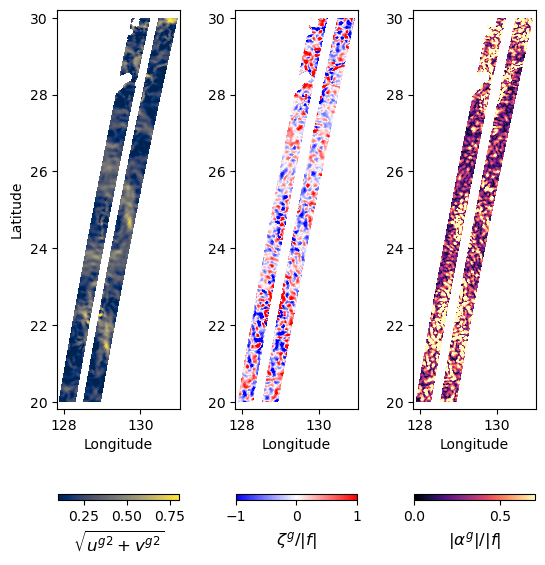

In [139]:
fig, (ax0, ax1,ax2) = plt.subplots(figsize=(6,6), nrows=1, ncols=3)
fig.set_tight_layout(True)
im0 = ax0.pcolormesh(sp1.isel(cycle_num=cnum).longitude, sp1.isel(cycle_num=cnum).latitude,
               sp1.isel(cycle_num=cnum),
               vmin=.1, vmax=.8, cmap="cividis",
               rasterized=True)
# ax0.pcolormesh(sp9.isel(cycle_num=cnum).longitude, sp9.isel(cycle_num=cnum).latitude,
#                sp9.isel(cycle_num=cnum),
#                vmin=.1, vmax=.8, cmap="cividis",
#                rasterized=True)
im1 = ax1.pcolormesh(v1.isel(cycle_num=cnum).longitude, v1.isel(cycle_num=cnum).latitude,
               (v1.isel(cycle_num=cnum) 
                / np.abs(gsw.f(v1.isel(cycle_num=cnum).latitude))),
               vmin=-1, vmax=1, cmap="bwr",
               rasterized=True)
# ax1.pcolormesh(v9.isel(cycle_num=cnum).longitude, v9.isel(cycle_num=cnum).latitude,
#                (v9.isel(cycle_num=cnum) 
#                 / np.abs(gsw.f(v9.isel(cycle_num=cnum).latitude))),
#                vmin=-1, vmax=1, cmap="bwr",
#                rasterized=True)
im2 = ax2.pcolormesh(s1.isel(cycle_num=cnum).longitude, s1.isel(cycle_num=cnum).latitude,
               (s1.isel(cycle_num=cnum) 
                / np.abs(gsw.f(s1.isel(cycle_num=cnum).latitude))),
               vmax=.7, vmin=0., cmap="magma",
               rasterized=True)
# ax2.pcolormesh(s9.isel(cycle_num=cnum).longitude, s9.isel(cycle_num=cnum).latitude,
#                (s9.isel(cycle_num=cnum) 
#                 / np.abs(gsw.f(s9.isel(cycle_num=cnum).latitude))),
#                vmax=.7, vmin=0., cmap="magma",
#                rasterized=True)
ax0.set_aspect("equal")
ax1.set_aspect("equal")
ax2.set_aspect("equal")
ax0.set_xlabel(r"Longitude")
ax1.set_xlabel(r"Longitude")
ax0.set_ylabel(r"Latitude")
ax2.set_xlabel(r"Longitude")
cbar0 = fig.colorbar(im0, ax=ax0, orientation="horizontal", shrink=.6)
cbar1 = fig.colorbar(im1, ax=ax1, orientation="horizontal", shrink=.6)
cbar2 = fig.colorbar(im2, ax=ax2, orientation="horizontal", shrink=.6)
cbar0.set_label(r"$\sqrt{{u^g}^2 + {v^g}^2}$", fontsize=12)
cbar1.set_label(r"$\zeta^g/|f|$", fontsize=12)
cbar2.set_label(r"$|\alpha^g|/|f|$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/vort-strain-PS.pdf"))

In [140]:
vbins = np.linspace(-3e0,3e0,60)
sbins = np.linspace(0,3e0,30)
hist_c = xhist((strain / np.abs(f)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort / np.abs(f)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()
hist_r = xhist((str_raw / np.abs(fr)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort_raw / np.abs(fr)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()

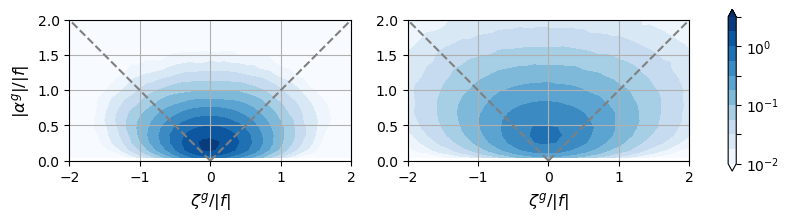

In [141]:
fig, axes = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
# fig.set_tight_layout(True)

im = axes[0].contourf(hist_c.vort_bin,
                 hist_c.strain_bin,
                 hist_c, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )
axes[1].contourf(hist_r.vort_bin,
                 hist_r.strain_bin,
                 hist_r, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )

# for c in im.collections:
#     c.set_rasterized(True)

axes[0].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[0].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')
axes[1].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[1].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')

axes[0].set_xlim([-2,2])
axes[0].set_ylim([0,2])
axes[1].set_xlim([-2,2])
axes[1].set_ylim([0,2])

axes[0].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[1].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[0].set_ylabel(r"$|\alpha^g|/|f|$", fontsize=12)

axes[0].grid(True)
axes[0].set_aspect('equal')
axes[1].grid(True)
axes[1].set_aspect('equal')

# fig.subplots_adjust(hspace=.06, wspace=.12)
# cbar = fig.colorbar(im, orientation='horizontal', ax=axes, shrink=.4, 
#                     ticks=[1e-4,1e-3,1e-2,1e-1,1e0])
cbar = fig.colorbar(im, ax=axes, shrink=.7)
# cbar.set_ticks([1e-2,1e-1,0,1])

plt.savefig(op.join(ddir,"../Figs/vort-strain-PSjointPDF.pdf"))

## HYCOM

In [4]:
reg = "PS"
ds21d = xr.open_zarr(op.join(ddir, "tssh_swot1day/Pass%03d/"
                             % 21)
                     + reg + "/ssh-detided_rawgrid.zarr"
                    )
maskn = xr.DataArray(ds21d.latitude.where(ds21d.latitude<30.).to_masked_array().mask,
                     dims=ds21d.latitude.dims,
                     coords=ds21d.latitude.coords
                    )
ds21d = ds21d.where(~maskn,drop=True)
masks = xr.DataArray(ds21d.latitude.where(ds21d.latitude>20.).to_masked_array().mask,
                     dims=ds21d.latitude.dims,
                     coords=ds21d.latitude.coords
                    )

ds21d = ds21d.where(~masks,drop=True)

mm21d = xr.DataArray(ds21d.ssha.mean(axis=0).to_masked_array().mask, 
                     dims=ds21d.ssha.isel(cycle_num=0).dims, 
                     coords=ds21d.ssha.isel(cycle_num=0).coords
                    )
######################
ds21t = xr.open_zarr(op.join(ddir, "tssh_swot1day/Pass%03d/"
                             % 21)
                     + reg + "/ssh-total_rawgrid.zarr"
                    )
maskn = xr.DataArray(ds21t.latitude.where(ds21t.latitude<30.).to_masked_array().mask,
                     dims=ds21t.latitude.dims,
                     coords=ds21t.latitude.coords
                    )
ds21t = ds21t.where(~maskn,drop=True)
masks = xr.DataArray(ds21t.latitude.where(ds21t.latitude>20.).to_masked_array().mask,
                     dims=ds21t.latitude.dims,
                     coords=ds21t.latitude.coords
                    )

ds21t = ds21t.where(~masks,drop=True)

mm21t = xr.DataArray(ds21t.ssha.mean(axis=0).to_masked_array().mask, 
                     dims=ds21t.ssha.isel(cycle_num=0).dims, 
                     coords=ds21t.ssha.isel(cycle_num=0).coords
                    )
ds21d

<xarray.Dataset> Size: 34MB
Dimensions:     (cycle_num: 105, num_lines: 574, num_pixels: 69)
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 5kB 6045 6046 6047 6048 ... 6616 6617 6618
  * num_pixels  (num_pixels) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
    latitude    (num_lines, num_pixels) float64 317kB dask.array<chunksize=(574, 69), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 317kB dask.array<chunksize=(574, 69), meta=np.ndarray>
    pass_num    int64 8B 21
Data variables:
    ssha        (cycle_num, num_lines, num_pixels) float64 33MB dask.array<chunksize=(14, 378, 18), meta=np.ndarray>

In [5]:
low21d = xr.open_zarr(op.join(ddir,"tssh_swot1day/geos/Pass%03d/%2s/SSHa-detided.zarr" 
                              % (21,reg))
                     )
maskn = xr.DataArray(low21d.latitude.where(low21d.latitude<30.).to_masked_array().mask,
                     dims=low21d.latitude.dims,
                     coords=low21d.latitude.coords
                    )
low21d = low21d.where(~maskn,drop=True)
masks = xr.DataArray(low21d.latitude.where(low21d.latitude>20.).to_masked_array().mask,
                     dims=low21d.latitude.dims,
                     coords=low21d.latitude.coords
                    )

low21d = low21d.where(~masks,drop=True).ssha
######################
low21t = xr.open_zarr(op.join(ddir,"tssh_swot1day/geos/Pass%03d/%2s/SSHa-total.zarr" 
                              % (21,reg))
                     )
maskn = xr.DataArray(low21t.latitude.where(low21t.latitude<30.).to_masked_array().mask,
                     dims=low21t.latitude.dims,
                     coords=low21t.latitude.coords
                    )
low21t = low21t.where(~maskn,drop=True)
masks = xr.DataArray(low21t.latitude.where(low21t.latitude>20.).to_masked_array().mask,
                     dims=low21t.latitude.dims,
                     coords=low21t.latitude.coords
                    )

low21t = low21t.where(~masks,drop=True).ssha
low21d

<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 574, num_pixels: 69)> Size: 33MB
dask.array<where, shape=(105, 574, 69), dtype=float64, chunksize=(1, 574, 69), chunktype=numpy.ndarray>
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 5kB 6045 6046 6047 6048 ... 6616 6617 6618
  * num_pixels  (num_pixels) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
    latitude    (num_lines, num_pixels) float64 317kB dask.array<chunksize=(574, 69), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 317kB dask.array<chunksize=(574, 69), meta=np.ndarray>
    pass_num    int64 8B 21

In [6]:
ageo = (1e-2*ds21d.ssha
        - low21d
       )

dsa21 = ageo.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa21.coords["y"] = ("y",range(len(dsa21.y)))
dsa21.coords["x"] = ("x",range(len(dsa21.x)))
if not dsa21.rio.crs:
    dsa21 = dsa21.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa21.ssha.rio.nodata is None:
    dsa21["ssha"] = dsa21.ssha.rio.write_nodata(np.nan)
_a21d_exterp = dsa21.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
# _a21_interp = _a21_exterp.interp(cycle_num=ds21.cycle_num, 
#                                    method="slinear",
#                                    kwargs={"fill_value": "extrapolate"}
#                                   )
a21d_exterp = _a21d_exterp.where(mm21d!=1)
dsa21.close()

dsg21 = low21d.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 
                                                 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg21.coords["y"] = ("y",range(len(dsg21.y)))
dsg21.coords["x"] = ("x",range(len(dsg21.x)))
if not dsg21.rio.crs:
    dsg21 = dsg21.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg21.ssha.rio.nodata is None:
    dsg21["ssha"] = dsg21.ssha.rio.write_nodata(np.nan)
_g21d_exterp = dsg21.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
# _g21_interp = _g21_exterp.interp(cycle_num=ds21.cycle_num, 
#                                    method="slinear",
#                                    kwargs={"fill_value": "extrapolate"}
#                                   )
g21d_exterp = _g21d_exterp.where(mm21d!=1)
dsg21.close()

In [7]:
ageo = (1e-2*ds21t.ssha
        - low21t
       )

dsa21 = ageo.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa21.coords["y"] = ("y",range(len(dsa21.y)))
dsa21.coords["x"] = ("x",range(len(dsa21.x)))
if not dsa21.rio.crs:
    dsa21 = dsa21.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa21.ssha.rio.nodata is None:
    dsa21["ssha"] = dsa21.ssha.rio.write_nodata(np.nan)
_a21t_exterp = dsa21.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
# _a21_interp = _a21_exterp.interp(cycle_num=ds21.cycle_num, 
#                                    method="slinear",
#                                    kwargs={"fill_value": "extrapolate"}
#                                   )
a21t_exterp = _a21t_exterp.where(mm21t!=1)
dsa21.close()

dsg21 = low21t.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 
                                                 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg21.coords["y"] = ("y",range(len(dsg21.y)))
dsg21.coords["x"] = ("x",range(len(dsg21.x)))
if not dsg21.rio.crs:
    dsg21 = dsg21.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg21.ssha.rio.nodata is None:
    dsg21["ssha"] = dsg21.ssha.rio.write_nodata(np.nan)
_g21t_exterp = dsg21.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
# _g21_interp = _g21_exterp.interp(cycle_num=ds21.cycle_num, 
#                                    method="slinear",
#                                    kwargs={"fill_value": "extrapolate"}
#                                   )
g21t_exterp = _g21t_exterp.where(mm21t!=1)
dsg21.close()

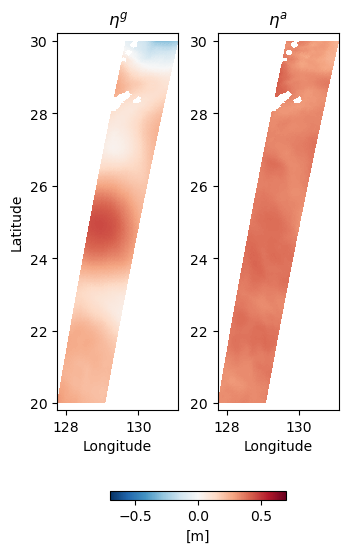

In [22]:
cnum = 20
fig, axes = plt.subplots(figsize=(3.8,7), nrows=1, ncols=2)
# fig.set_tight_layout(True)
# im = axes[0].pcolormesh(g04_exterp.isel(cycle_num=cnum).longitude, g04_exterp.isel(cycle_num=cnum).latitude,
#                g04_exterp.isel(cycle_num=cnum),
#                vmin=-.4, vmax=.4, cmap="RdBu_r",
#                rasterized=True)
im = axes[0].pcolormesh(g21d_exterp.isel(cycle_num=cnum).longitude, 
                        g21d_exterp.isel(cycle_num=cnum).latitude,
               g21d_exterp.isel(cycle_num=cnum),
               vmin=-.7, vmax=.7, cmap="RdBu_r",
               rasterized=True)
# axes[1].pcolormesh(a04_exterp.isel(cycle_num=cnum).longitude, a04_exterp.isel(cycle_num=cnum).latitude,
#                a04_exterp.isel(cycle_num=cnum),
#                vmin=-.4, vmax=.4, cmap="RdBu_r",
#                rasterized=True)
axes[1].pcolormesh(a21d_exterp.isel(cycle_num=cnum).longitude, 
                   a21d_exterp.isel(cycle_num=cnum).latitude,
               a21d_exterp.isel(cycle_num=cnum),
               vmin=-.7, vmax=.7, cmap="RdBu_r",
               rasterized=True)
axes[0].set_aspect("equal")
axes[1].set_aspect("equal")
axes[0].set_xlabel(r"Longitude")
axes[0].set_ylabel(r"Latitude")
axes[1].set_xlabel(r"Longitude")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.6)
cbar.set_label(r"[m]")
axes[0].set_title(r"$\eta^g$")
axes[1].set_title(r"$\eta^a$")
plt.savefig(op.join(ddir,"../Figs/sshaHYCOM-PS-detided.pdf"))

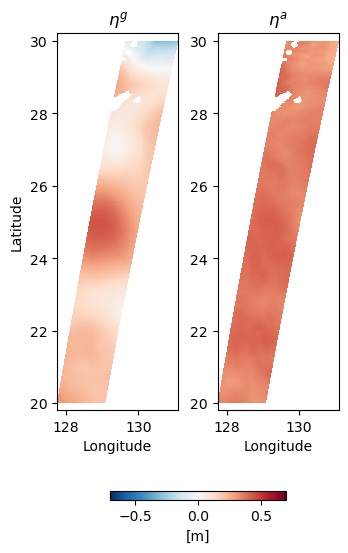

In [8]:
cnum = 20
fig, axes = plt.subplots(figsize=(3.8,7), nrows=1, ncols=2)
# fig.set_tight_layout(True)
# im = axes[0].pcolormesh(g04_exterp.isel(cycle_num=cnum).longitude, g04_exterp.isel(cycle_num=cnum).latitude,
#                g04_exterp.isel(cycle_num=cnum),
#                vmin=-.4, vmax=.4, cmap="RdBu_r",
#                rasterized=True)
im = axes[0].pcolormesh(g21t_exterp.isel(cycle_num=cnum).longitude, 
                        g21t_exterp.isel(cycle_num=cnum).latitude,
               g21t_exterp.isel(cycle_num=cnum),
               vmin=-.7, vmax=.7, cmap="RdBu_r",
               rasterized=True)
# axes[1].pcolormesh(a04_exterp.isel(cycle_num=cnum).longitude, a04_exterp.isel(cycle_num=cnum).latitude,
#                a04_exterp.isel(cycle_num=cnum),
#                vmin=-.4, vmax=.4, cmap="RdBu_r",
#                rasterized=True)
axes[1].pcolormesh(a21t_exterp.isel(cycle_num=cnum).longitude, 
                   a21t_exterp.isel(cycle_num=cnum).latitude,
               a21t_exterp.isel(cycle_num=cnum),
               vmin=-.7, vmax=.7, cmap="RdBu_r",
               rasterized=True)
axes[0].set_aspect("equal")
axes[1].set_aspect("equal")
axes[0].set_xlabel(r"Longitude")
axes[0].set_ylabel(r"Latitude")
axes[1].set_xlabel(r"Longitude")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.6)
cbar.set_label(r"[m]")
axes[0].set_title(r"$\eta^g$")
axes[1].set_title(r"$\eta^a$")
plt.savefig(op.join(ddir,"../Figs/sshaHYCOM-PS-total.pdf"))

In [9]:
for cc in low21d.cycle_num:
    if cc == low21d.cycle_num[0]:
        ar_g1d = g21d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a1d = a21d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_g1t = g21t_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a1t = a21t_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
    else:
        ar_g1d = xr.concat([ar_g1d, 
                          g21d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a1d = xr.concat([ar_a1d, 
                          a21d_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_g1t = xr.concat([ar_g1t, 
                          g21t_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a1t = xr.concat([ar_a1t, 
                          a21t_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")

ar_g1d.coords["time"] = ("time",np.arange(len(ar_g1d.time))*24*60.*60)
ar_a1d.coords["time"] = ("time",np.arange(len(ar_a1d.time))*24*60.*60)
ar_g1d.coords["num_lines"] = ("num_lines",np.arange(len(ar_g1d.num_lines))*2e3)
ar_a1d.coords["num_lines"] = ("num_lines",np.arange(len(ar_a1d.num_lines))*2e3)
ar_g1t.coords["time"] = ("time",np.arange(len(ar_g1t.time))*24*60.*60)
ar_a1t.coords["time"] = ("time",np.arange(len(ar_a1t.time))*24*60.*60)
ar_g1t.coords["num_lines"] = ("num_lines",np.arange(len(ar_g1t.num_lines))*2e3)
ar_a1t.coords["num_lines"] = ("num_lines",np.arange(len(ar_a1t.num_lines))*2e3)

Fg1d = xrft.power_spectrum(ar_g1d.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg1d = xrft.power_spectrum(Fg1d.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa1d = xrft.power_spectrum(ar_a1d.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa1d = xrft.power_spectrum(Fa1d.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")

Fg1t = xrft.power_spectrum(ar_g1t.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg1t = xrft.power_spectrum(Fg1t.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa1t = xrft.power_spectrum(ar_a1t.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa1t = xrft.power_spectrum(Fa1t.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fad = Fa1d
Fgd = Fg1d
Fat = Fa1t
Fgt = Fg1t
Fgd, Fad

(<xarray.DataArray 'rechunk-merge-a1b35fbc99ae76bd7f50cf44a523acd4' (
                                                                     freq_time: 105,
                                                                     freq_num_lines: 522)> Size: 438kB
 dask.array<mean_agg-aggregate, shape=(105, 522), dtype=float64, chunksize=(105, 522), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 4kB -0.00025 -0.000249 ... 0.000249,
 <xarray.DataArray 'rechunk-merge-bb17064ff0b90c1c8517d09260b19479' (
                                                                     freq_time: 105,
                                                                     freq_num_lines: 522)> Size: 438kB
 dask.array<mean_agg-aggregate, shape=(105, 522), dtype=float64, chunksize=(105, 522), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06

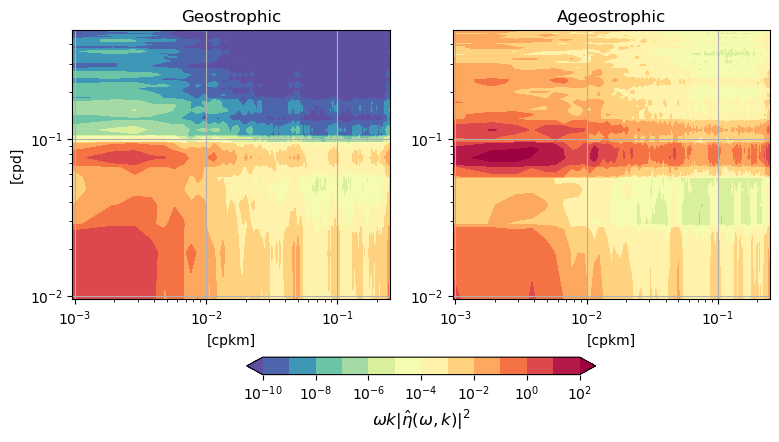

In [26]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fgd.freq_num_lines.isel(freq_num_lines=slice(len(Fgd.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fgd.freq_time.isel(freq_time=slice(len(Fgd.freq_time)//2,
                                                 None)).values*86400,
               (Fgd.freq_num_lines*Fgd.freq_time*Fgd
               ).isel(freq_num_lines=slice(len(Fgd.freq_num_lines)//2,None),
                      freq_time=slice(len(Fgd.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-10,2,13),
               norm=clr.LogNorm(), cmap="Spectral_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fad.freq_num_lines.isel(freq_num_lines=slice(len(Fad.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fad.freq_time.isel(freq_time=slice(len(Fad.freq_time)//2,
                                                 None)).values*86400,
               (Fad.freq_num_lines*Fad.freq_time*Fad
               ).isel(freq_num_lines=slice(len(Fad.freq_num_lines)//2,None),
                      freq_time=slice(len(Fad.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-10,2,13),
               norm=clr.LogNorm(), cmap="Spectral_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fgd.freq_num_lines.where(Fgd.freq_num_lines>0.).min()*1e3,
              Fgd.freq_num_lines.where(Fgd.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fgd.freq_time.where(Fgd.freq_time>0.).min()*86400,
              Fgd.freq_time.where(Fgd.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fad.freq_num_lines.where(Fad.freq_num_lines>0.).min()*1e3,
              Fad.freq_num_lines.where(Fad.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fad.freq_time.where(Fad.freq_time>0.).min()*86400,
              Fad.freq_time.where(Fad.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"$\omega k |\hat{\eta}(\omega,k)|^2$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_PS_HYCOMdetided.pdf"))

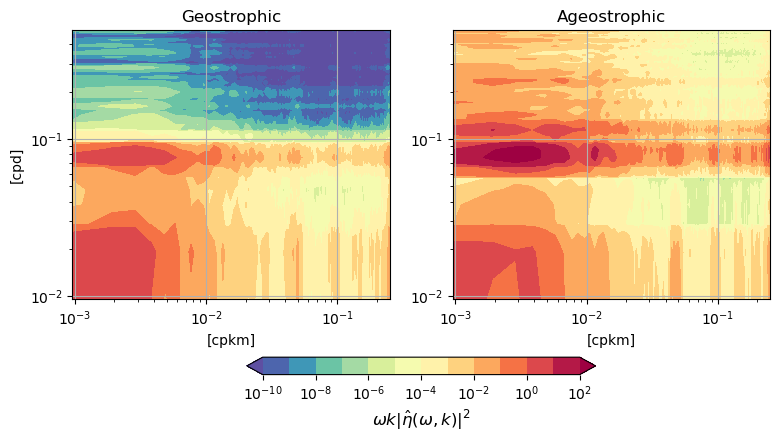

In [10]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fgt.freq_num_lines.isel(freq_num_lines=slice(len(Fgt.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fgt.freq_time.isel(freq_time=slice(len(Fgt.freq_time)//2,
                                                 None)).values*86400,
               (Fgt.freq_num_lines*Fgt.freq_time*Fgt
               ).isel(freq_num_lines=slice(len(Fgt.freq_num_lines)//2,None),
                      freq_time=slice(len(Fgt.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-10,2,13),
               norm=clr.LogNorm(), cmap="Spectral_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fat.freq_num_lines.isel(freq_num_lines=slice(len(Fat.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fat.freq_time.isel(freq_time=slice(len(Fat.freq_time)//2,
                                                 None)).values*86400,
               (Fat.freq_num_lines*Fat.freq_time*Fat
               ).isel(freq_num_lines=slice(len(Fat.freq_num_lines)//2,None),
                      freq_time=slice(len(Fat.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-10,2,13),
               norm=clr.LogNorm(), cmap="Spectral_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fgd.freq_num_lines.where(Fgt.freq_num_lines>0.).min()*1e3,
              Fgt.freq_num_lines.where(Fgt.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fgt.freq_time.where(Fgt.freq_time>0.).min()*86400,
              Fgt.freq_time.where(Fgt.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fat.freq_num_lines.where(Fat.freq_num_lines>0.).min()*1e3,
              Fat.freq_num_lines.where(Fat.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fat.freq_time.where(Fat.freq_time>0.).min()*86400,
              Fat.freq_time.where(Fat.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"$\omega k |\hat{\eta}(\omega,k)|^2$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_PS_HYCOMtotal.pdf"))

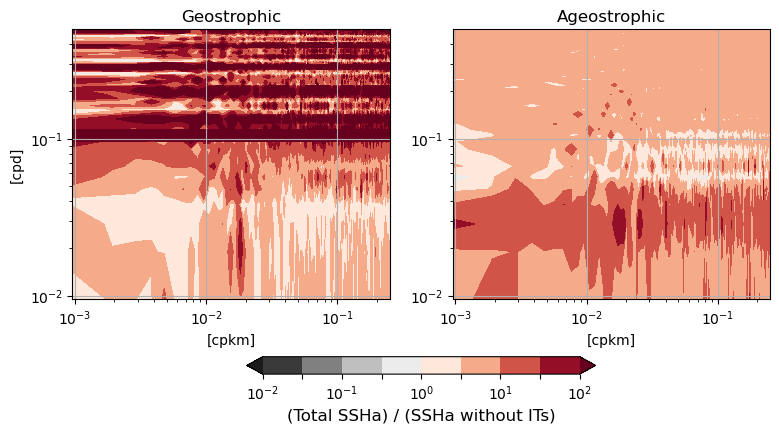

In [12]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fgt.freq_num_lines.isel(freq_num_lines=slice(len(Fgt.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fgt.freq_time.isel(freq_time=slice(len(Fgt.freq_time)//2,
                                                 None)).values*86400,
               (Fgt / Fgd
               ).isel(freq_num_lines=slice(len(Fgt.freq_num_lines)//2,None),
                      freq_time=slice(len(Fgt.freq_time)//2,None)
                     ).values*4,
               levels=np.logspace(-2,2,9),
               norm=clr.LogNorm(), cmap="RdGy_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fat.freq_num_lines.isel(freq_num_lines=slice(len(Fat.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fat.freq_time.isel(freq_time=slice(len(Fat.freq_time)//2,
                                                 None)).values*86400,
               (Fat / Fad
               ).isel(freq_num_lines=slice(len(Fat.freq_num_lines)//2,None),
                      freq_time=slice(len(Fat.freq_time)//2,None)
                     ).values*4,
               levels=np.logspace(-2,2,9),
               norm=clr.LogNorm(), cmap="RdGy_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fgd.freq_num_lines.where(Fgt.freq_num_lines>0.).min()*1e3,
              Fgt.freq_num_lines.where(Fgt.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fgt.freq_time.where(Fgt.freq_time>0.).min()*86400,
              Fgt.freq_time.where(Fgt.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fat.freq_num_lines.where(Fat.freq_num_lines>0.).min()*1e3,
              Fat.freq_num_lines.where(Fat.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fat.freq_time.where(Fat.freq_time>0.).min()*86400,
              Fat.freq_time.where(Fat.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"(Total SSHa) / (SSHa without ITs)", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_PS_HYCOMratio.pdf"))

# Hawaii

In [198]:
ds15 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 15))
ds15.coords["num_lines"] = ("num_lines",range(len(ds15.num_lines)))
ds15.coords["num_pixels"] = ("num_pixels",range(len(ds15.num_pixels)))

ds28 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/CalVal_pass%03d_v2.0.1.zarr"
                            % 28))
ds28.coords["num_lines"] = ("num_lines",range(len(ds28.num_lines)))
ds28.coords["num_pixels"] = ("num_pixels",range(len(ds28.num_pixels)))
ds15,ds28

(<xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
     longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 571MB dask.array<chunksize=(1, 9860, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels  

In [209]:
maskn5 = xr.DataArray(ds15.latitude.where(ds15.latitude<38.4).to_masked_array().mask,
                     dims=ds15.latitude.dims,
                     coords=ds15.latitude.coords
                    )
masks5 = xr.DataArray(ds15.latitude.where(ds15.latitude>33).to_masked_array().mask,
                     dims=ds15.latitude.dims,
                     coords=ds15.latitude.coords
                    )
xo15 = ds15.where(~maskn5,drop=True).where(~masks5,drop=True)

maskn8 = xr.DataArray(ds28.latitude.where(ds28.latitude<38.4).to_masked_array().mask,
                     dims=ds28.latitude.dims,
                     coords=ds28.latitude.coords
                    )
masks8 = xr.DataArray(ds28.latitude.where(ds28.latitude>33).to_masked_array().mask,
                     dims=ds28.latitude.dims,
                     coords=ds28.latitude.coords
                    )
xo28 = ds28.where(~maskn8,drop=True).where(~masks8,drop=True)
xo15, xo28

(<xarray.Dataset> Size: 19MB
 Dimensions:       (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 3kB 6775 6776 6777 6778 ... 7093 7094 7095
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 177kB 33.0 33.0 ... 38.38
     longitude     (num_lines, num_pixels) float64 177kB 207.5 207.5 ... 210.4
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 19MB dask.array<chunksize=(1, 321, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 19MB
 Dimensions:       (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 3kB 2766 2767 2768 2769 ... 3084 3085 3086
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 

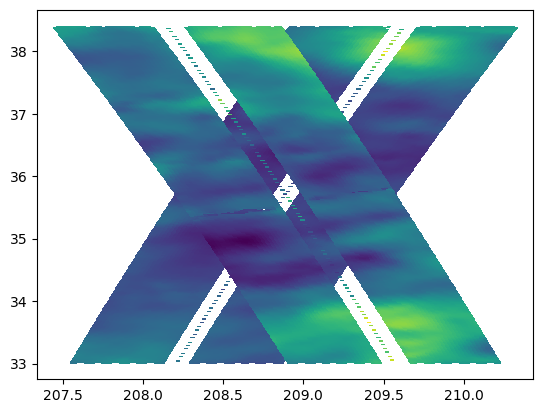

In [210]:
fig, ax = plt.subplots()
ax.pcolormesh(xo15.longitude, xo15.latitude,
              xo15.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )
ax.pcolormesh(xo28.longitude, xo28.latitude,
              xo28.ssha_detided.isel(cycle_num=10),
              rasterized=True
             )

In [211]:
inp = 3

mask15 = xr.DataArray(xo15.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo15.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo15.ssha_detided.isel(cycle_num=0).coords
                    )
mm15 = xr.DataArray(mask15.where(mask15<.5
                              ).to_masked_array().mask,
                   dims=xo15.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo15.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mask28 = xr.DataArray(xo28.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo28.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo28.ssha_detided.isel(cycle_num=0).coords
                    )
mm28 = xr.DataArray(mask28.where(mask28<.5
                              ).to_masked_array().mask,
                   dims=xo28.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo28.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mm15, mm28

(<xarray.DataArray (num_lines: 321, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ...,  True,  True,  True]], shape=(321, 63))
 Coordinates:
   * num_lines   (num_lines) int64 3kB 6775 6776 6777 6778 ... 7093 7094 7095
   * num_pixels  (num_pixels) int64 504B 3 4 5 6 7 8 9 ... 59 60 61 62 63 64 65
     cycle_num   int64 8B 474
     latitude    (num_lines, num_pixels) float64 162kB 32.99 32.99 ... 38.4 38.4
     longitude   (num_lines, num_pixels) float64 162kB 207.5 207.6 ... 210.4,
 <xarray.DataArray (num_lines: 321, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  

In [212]:
low15 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass%03d/SSHa.zarr" 
                               % 15)
                      ).ssha.where(~maskn5,drop=True).where(~masks5,drop=True)
low28 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass%03d/SSHa.zarr" 
                               % 28)
                      ).ssha.where(~maskn8,drop=True).where(~masks8,drop=True)
low15, low28

(<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 6776 6777 6778 6779 ... 7092 7093 7094
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 156kB 33.0 33.0 ... 38.39 38.38
     longitude   (num_lines, num_pixels) float64 156kB 207.6 207.6 ... 210.3,
 <xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 2767 2768 2769 2770 ... 3083 3084 3085
   * num_pixels  (num_pixels) in

In [213]:
r_ref5 = (~mm15).sum() / np.prod(mm15.shape)
r_ref8 = (~mm28).sum() / np.prod(mm28.shape)
r_ref8

<xarray.DataArray ()> Size: 8B
array(0.81966078)
Coordinates:
    cycle_num  int64 8B 474

In [214]:
ageo = (1e-2*ds15.ssha_detided
        - low15
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low15.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r15 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r15 = xr.concat([r15, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref5:
        if ic == 0:
            a15 = ssha
        else:
            try:
                a15 = xr.concat([a15, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a15.coords["cycle_num"] = ("cycle_num",
                           r15.where(r15>0.7*r_ref5, drop=True).cycle_num.data
                          )

dsa15 = a15.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa15.coords["y"] = ("y",range(len(dsa15.y)))
dsa15.coords["x"] = ("x",range(len(dsa15.x)))
if not dsa15.rio.crs:
    dsa15 = dsa15.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa15.ssha.rio.nodata is None:
    dsa15["ssha"] = dsa15.ssha.rio.write_nodata(np.nan)
_a15_exterp = dsa15.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a15_interp = _a15_exterp.interp(cycle_num=ds15.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a15_exterp = _a15_exterp.where(mm15.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds15.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa15.close()

dsg15 = low15.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg15.coords["y"] = ("y",range(len(dsg15.y)))
dsg15.coords["x"] = ("x",range(len(dsg15.x)))
if not dsg15.rio.crs:
    dsg15 = dsg15.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg15.ssha.rio.nodata is None:
    dsg15["ssha"] = dsg15.ssha.rio.write_nodata(np.nan)
_g15_exterp = dsg15.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g15_interp = _g15_exterp.interp(cycle_num=ds15.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g15_exterp = _g15_exterp.where(mm15.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds15.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg15.close()

In [215]:
ageo = (1e-2*ds28.ssha_detided
        - low28
       )
ic = 0
for cc in ageo.cycle_num:

    sshg = low28.sel(cycle_num=cc)
    ssha = ageo.sel(cycle_num=cc)
    
    array = ssha.to_masked_array()
    mask = ~array.mask
    ratio = mask.sum() / np.prod(mask.shape)
    if ic == 0:
        r28 = xr.DataArray(np.array([ratio]), 
                           dims='cycle_num', 
                           coords={'cycle_num':np.array([cc.values,])}
                          )
    else:
        r28 = xr.concat([r28, xr.DataArray(np.array([ratio]), 
                               dims='cycle_num', 
                               coords={'cycle_num':np.array([cc.values,])}
                                          )
                        ], 'cycle_num')
    if ratio > .7*r_ref8:
        if ic == 0:
            a28 = ssha
        else:
            try:
                a28 = xr.concat([a28, ssha], 'cycle_num')
            except:
                pass
        ic += 1
    # else:
    #     ssha.plot(rasterized=True)
    #     plt.show()
    del ssha, mask, array

a28.coords["cycle_num"] = ("cycle_num",
                           r28.where(r28>0.7*r_ref8, drop=True).cycle_num.data
                          )

dsa28 = a28.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsa28.coords["y"] = ("y",range(len(dsa28.y)))
dsa28.coords["x"] = ("x",range(len(dsa28.x)))
if not dsa28.rio.crs:
    dsa28 = dsa28.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsa28.ssha.rio.nodata is None:
    dsa28["ssha"] = dsa28.ssha.rio.write_nodata(np.nan)
_a28_exterp = dsa28.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_a28_interp = _a28_exterp.interp(cycle_num=ds28.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
a28_exterp = _a28_exterp.where(mm28.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds28.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsa28.close()

dsg28 = low28.to_dataset(name="ssha").swap_dims({'num_pixels':'x', 'num_lines':'y'}
                                             ).reset_coords(drop=True)
dsg28.coords["y"] = ("y",range(len(dsg28.y)))
dsg28.coords["x"] = ("x",range(len(dsg28.x)))
if not dsg28.rio.crs:
    dsg28 = dsg28.rio.write_crs("EPSG:4326")
    # dsH3 = dsH3.rio.write_crs("EPSG:3857")
if dsg28.ssha.rio.nodata is None:
    dsg28["ssha"] = dsg28.ssha.rio.write_nodata(np.nan)
_g28_exterp = dsg28.rio.interpolate_na().swap_dims({'x':'num_pixels', 
                                                    'y':'num_lines'}
                                                  ).ssha.drop_vars(["x","y"])
_g28_interp = _g28_exterp.interp(cycle_num=ds28.cycle_num, 
                                   method="slinear",
                                   kwargs={"fill_value": "extrapolate"}
                                  )
g28_exterp = _g28_exterp.where(mm28.isel(num_pixels=slice(1,-1),
                                         num_lines=slice(1,-1)
                                        )!=1
                              ).interp(cycle_num=ds28.cycle_num, 
                                       method="slinear",
                                       kwargs={"fill_value": "extrapolate"}
                                      )
dsg28.close()

In [216]:
for cc in low15.cycle_num:
    if cc == low15.cycle_num[0]:
        ar_g5 = g15_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a5 = a15_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])

        ar_g8 = g28_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
        ar_a8 = a28_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                 ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
    else:
        ar_g5 = xr.concat([ar_g5, 
                          g15_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a5 = xr.concat([ar_a5, 
                          a15_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_g8 = xr.concat([ar_g8, 
                          g28_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")
        ar_a8 = xr.concat([ar_a8, 
                          a28_exterp.sel(cycle_num=cc).isel(num_pixels=[1,-2]
                                                           ).dropna("num_lines").drop_vars(["num_lines","num_pixels"])
                         ], "time")

ar_g5.coords["time"] = ("time",np.arange(len(ar_g5.time))*24*60.*60)
ar_a5.coords["time"] = ("time",np.arange(len(ar_a5.time))*24*60.*60)
ar_g8.coords["time"] = ("time",np.arange(len(ar_g8.time))*24*60.*60)
ar_a8.coords["time"] = ("time",np.arange(len(ar_a8.time))*24*60.*60)
ar_g5.coords["num_lines"] = ("num_lines",np.arange(len(ar_g5.num_lines))*2e3)
ar_a5.coords["num_lines"] = ("num_lines",np.arange(len(ar_a5.num_lines))*2e3)
ar_g8.coords["num_lines"] = ("num_lines",np.arange(len(ar_g8.num_lines))*2e3)
ar_a8.coords["num_lines"] = ("num_lines",np.arange(len(ar_a8.num_lines))*2e3)

ar_g5, ar_a8

(<xarray.DataArray 'ssha' (time: 105, num_lines: 294, num_pixels: 2)> Size: 494kB
 array([[[0.07027429, 0.0691213 ],
         [0.07228503, 0.07025162],
         [0.07403477, 0.07153865],
         ...,
         [0.16735856, 0.09677204],
         [0.16501921, 0.0993765 ],
         [0.16268299, 0.10248393]],
 
        [[0.06948413, 0.06592252],
         [0.0710514 , 0.06711064],
         [0.07254725, 0.06857247],
         ...,
         [0.15839301, 0.10883398],
         [0.15625288, 0.11100708],
         [0.15416223, 0.11357267]],
 
        [[0.06872324, 0.0631701 ],
         [0.06944784, 0.06454559],
         [0.07040884, 0.06626171],
         ...,
 ...
         ...,
         [0.14964397, 0.07071187],
         [0.14845295, 0.07246709],
         [0.14715527, 0.07437196]],
 
        [[0.09668212, 0.08475528],
         [0.09563638, 0.08664559],
         [0.09478896, 0.08850827],
         ...,
         [0.15237212, 0.07072306],
         [0.15121428, 0.07254657],
         [0.14995976, 0.07449

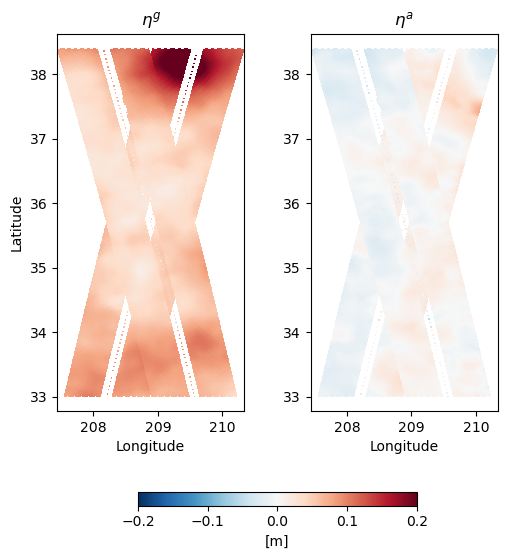

In [239]:
cnum = 20
fig, axes = plt.subplots(figsize=(6,7), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].pcolormesh(g15_exterp.isel(cycle_num=cnum).longitude, g15_exterp.isel(cycle_num=cnum).latitude,
               g15_exterp.isel(cycle_num=cnum),
               vmin=-.2, vmax=.2, cmap="RdBu_r",
               rasterized=True)
axes[0].pcolormesh(g28_exterp.isel(cycle_num=cnum).longitude, g28_exterp.isel(cycle_num=cnum).latitude,
               g28_exterp.isel(cycle_num=cnum),
               vmin=-.2, vmax=.2, cmap="RdBu_r",
               rasterized=True)
axes[1].pcolormesh(a15_exterp.isel(cycle_num=cnum).longitude, a15_exterp.isel(cycle_num=cnum).latitude,
               a15_exterp.isel(cycle_num=cnum),
               vmin=-.2, vmax=.2, cmap="RdBu_r",
               rasterized=True)
axes[1].pcolormesh(a28_exterp.isel(cycle_num=cnum).longitude, a28_exterp.isel(cycle_num=cnum).latitude,
               a28_exterp.isel(cycle_num=cnum),
               vmin=-.2, vmax=.2, cmap="RdBu_r",
               rasterized=True)
axes[0].set_aspect("equal")
axes[1].set_aspect("equal")
axes[0].set_xlabel(r"Longitude")
axes[0].set_ylabel(r"Latitude")
axes[1].set_xlabel(r"Longitude")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.6)
cbar.set_label(r"[m]")
axes[0].set_title(r"$\eta^g$")
axes[1].set_title(r"$\eta^a$")
plt.savefig(op.join(ddir,"../Figs/ssha-nH.pdf"))

In [218]:
Fg5 = xrft.power_spectrum(ar_g5.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg5 = xrft.power_spectrum(Fg5.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa5 = xrft.power_spectrum(ar_a5.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa5 = xrft.power_spectrum(Fa5.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fg8 = xrft.power_spectrum(ar_g8.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fg8 = xrft.power_spectrum(Fg8.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa8 = xrft.power_spectrum(ar_a8.reset_coords(drop=True).chunk({"num_pixels":1}), 
                         dim=["time"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        )
Fa8 = xrft.power_spectrum(Fa8.reset_coords(drop=True), 
                         dim=["num_lines"], 
                         detrend="linear", window="hann",
                         window_correction=True
                        ).mean("num_pixels")
Fa = .5*(Fa5 + Fa8)
Fg = .5*(Fg5 + Fg8)
Fg, Fa

(<xarray.DataArray (freq_time: 105, freq_num_lines: 294)> Size: 247kB
 dask.array<mul, shape=(105, 294), dtype=float64, chunksize=(105, 294), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483,
 <xarray.DataArray (freq_time: 105, freq_num_lines: 294)> Size: 247kB
 dask.array<mul, shape=(105, 294), dtype=float64, chunksize=(105, 294), chunktype=numpy.ndarray>
 Coordinates:
   * freq_time       (freq_time) float64 840B -5.732e-06 -5.622e-06 ... 5.732e-06
   * freq_num_lines  (freq_num_lines) float64 2kB -0.00025 ... 0.0002483)

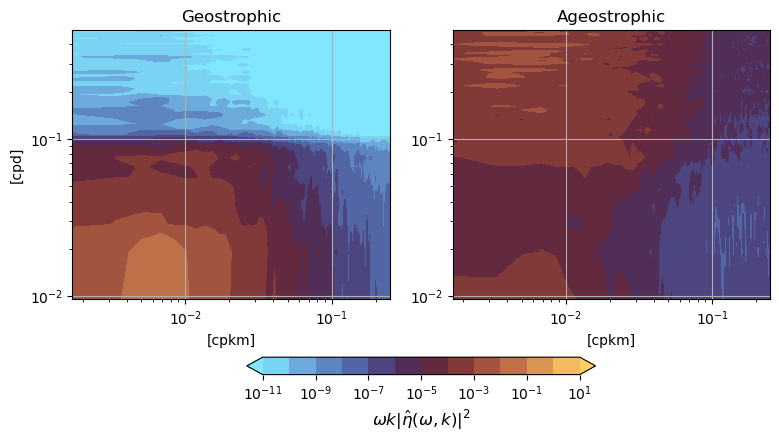

In [222]:
fig, axes = plt.subplots(figsize=(9,5), nrows=1, ncols=2)
# fig.set_tight_layout(True)
im = axes[0].contourf(Fg.freq_num_lines.isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fg.freq_time.isel(freq_time=slice(len(Fg.freq_time)//2,
                                                 None)).values*86400,
               (Fg.freq_num_lines*Fg.freq_time*Fg
               ).isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,None),
                      freq_time=slice(len(Fg.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
               extend="both",
               rasterized=True
              )
axes[1].contourf(Fa.freq_num_lines.isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fa.freq_time.isel(freq_time=slice(len(Fa.freq_time)//2,
                                                 None)).values*86400,
               (Fa.freq_num_lines*Fa.freq_time*Fa
               ).isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,None),
                      freq_time=slice(len(Fa.freq_time)//2,None)
                     ).values.T*4,
               levels=np.logspace(-11,1,13),
               norm=clr.LogNorm(), cmap="managua_r",
                 extend="both",
               rasterized=True
              )
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim([Fg.freq_num_lines.where(Fg.freq_num_lines>0.).min()*1e3,
              Fg.freq_num_lines.where(Fg.freq_num_lines>0.).max()*1e3])
axes[0].set_ylim([Fg.freq_time.where(Fg.freq_time>0.).min()*86400,
              Fg.freq_time.where(Fg.freq_time>0.).max()*86400])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim([Fa.freq_num_lines.where(Fa.freq_num_lines>0.).min()*1e3,
              Fa.freq_num_lines.where(Fa.freq_num_lines>0.).max()*1e3])
axes[1].set_ylim([Fa.freq_time.where(Fa.freq_time>0.).min()*86400,
              Fa.freq_time.where(Fa.freq_time>0.).max()*86400])
axes[0].set_xlabel(r"[cpkm]")
axes[1].set_xlabel(r"[cpkm]")
axes[0].set_ylabel(r"[cpd]")
axes[0].grid(True)
axes[1].grid(True)
axes[0].set_title(r"Geostrophic")
axes[1].set_title(r"Ageostrophic")
cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.5)
cbar.set_label(r"$\omega k |\hat{\eta}(\omega,k)|^2$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/omega-k_nH.pdf"))

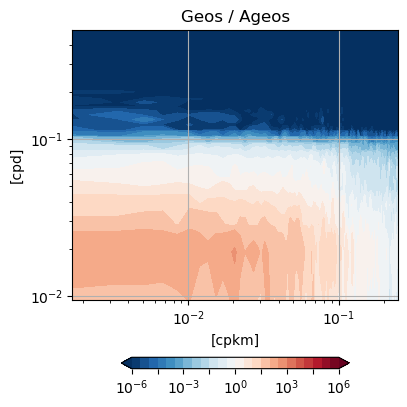

In [223]:
fig, ax = plt.subplots(figsize=(4.2,5))
# fig.set_tight_layout(True)
im = ax.contourf(Fg.freq_num_lines.isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,
                                                           None)).values*1e3,
               Fg.freq_time.isel(freq_time=slice(len(Fg.freq_time)//2,
                                                 None)).values*86400,
               ((Fg.freq_num_lines*Fg.freq_time*Fg
                ).isel(freq_num_lines=slice(len(Fg.freq_num_lines)//2,None),
                       freq_time=slice(len(Fg.freq_time)//2,None)
                      ).values.T
                / (Fa.freq_num_lines*Fa.freq_time*Fa
               ).isel(freq_num_lines=slice(len(Fa.freq_num_lines)//2,None),
                      freq_time=slice(len(Fa.freq_time)//2,None)
                     ).values.T
               ),
               levels=np.logspace(-6,6,25),
               norm=clr.LogNorm(), cmap="RdBu_r",
               extend="both",
               rasterized=True
              )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([Fg.freq_num_lines.where(Fg.freq_num_lines>0.).min()*1e3,
              Fg.freq_num_lines.where(Fg.freq_num_lines>0.).max()*1e3])
ax.set_ylim([Fg.freq_time.where(Fg.freq_time>0.).min()*86400,
              Fg.freq_time.where(Fg.freq_time>0.).max()*86400])
ax.set_xlabel(r"[cpkm]")
ax.set_ylabel(r"[cpd]")
ax.grid(True)
ax.set_title(r"Geos / Ageos")
cbar = fig.colorbar(im, ax=ax, orientation="horizontal", shrink=.7)
plt.savefig(op.join(ddir,"../Figs/omega-k_nH-ratio.pdf"))

In [224]:
dsv5 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass015/SSVs_SwotDiag.zarr"))
dsv8 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass028/SSVs_SwotDiag.zarr"))
dsv5r = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass015/SSVs_rawSwotDiag.zarr"))
dsv8r = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass028/SSVs_rawSwotDiag.zarr"))
dsv5, dsv8

(<xarray.Dataset> Size: 3GB
 Dimensions:     (cycle_num: 105, num_lines: 9310, num_pixels: 61)
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
     longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
 Data variables:
     strain      (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     ucg         (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     ug          (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>
     vcg         (cycle_num, num_lines, num_pixels) float64 477MB das

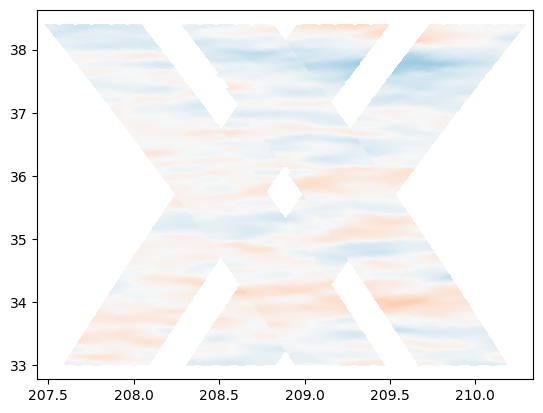

In [225]:
# u1 = dsv1.ucg.where(~maskn1,drop=True).where(~masks1,drop=True)
# u6 = dsv6.ucg.where(~maskn6,drop=True).where(~masks6,drop=True)
u5 = dsv5.ug.where(~maskn5,drop=True).where(~masks5,drop=True)
u8 = dsv8.ug.where(~maskn8,drop=True).where(~masks8,drop=True)

fig, ax = plt.subplots()
ax.pcolormesh(u5.longitude, u5.latitude,
              u5.isel(cycle_num=11),
              vmax=.8, vmin=-.8, cmap="RdBu_r",
              rasterized=True
             )
ax.pcolormesh(u8.longitude, u8.latitude,
              u8.isel(cycle_num=11),
              vmax=.8, vmin=-.8, cmap="RdBu_r",
              rasterized=True
             )

In [226]:
# sp1 = np.sqrt(dsv1.ucg**2 + dsv1.vcg**2).where(~maskn1,drop=True).where(~masks1,drop=True)
# sp6 = np.sqrt(dsv6.ucg**2 + dsv6.vcg**2).where(~maskn6,drop=True).where(~masks6,drop=True)
sp5 = np.sqrt(dsv5.ug**2 + dsv5.vg**2).where(~maskn5,drop=True).where(~masks5,drop=True)
sp8 = np.sqrt(dsv8.ug**2 + dsv8.vg**2).where(~maskn8,drop=True).where(~masks8,drop=True)
v5 = dsv5.vort.where(~maskn5,drop=True).where(~masks5,drop=True)
s5 = dsv5.strain.where(~maskn5,drop=True).where(~masks5,drop=True)
v8 = dsv8.vort.where(~maskn8,drop=True).where(~masks8,drop=True)
s8 = dsv8.strain.where(~maskn8,drop=True).where(~masks8,drop=True)
v5r = dsv5r.vort.where(~maskn5,drop=True
                      ).where(~masks5,drop=True
                             ).isel(num_pixels=slice(4,-4),
                                    num_lines=slice(1,-1)
                                   ).dropna("cycle_num", how="all")
s5r = dsv5r.strain.where(~maskn5,drop=True
                        ).where(~masks5,drop=True
                               ).isel(num_pixels=slice(4,-4),
                                      num_lines=slice(1,-1)
                                     ).dropna("cycle_num", how="all")
v8r = dsv8r.vort.where(~maskn8,drop=True
                      ).where(~masks8,drop=True
                             ).isel(num_pixels=slice(4,-4),
                                    num_lines=slice(1,-1)
                                   ).dropna("cycle_num", how="all")
s8r = dsv8r.strain.where(~maskn8,drop=True
                        ).where(~masks8,drop=True
                               ).isel(num_pixels=slice(4,-4),
                                      num_lines=slice(1,-1)
                                     ).dropna("cycle_num", how="all")
v5, v5r

(<xarray.DataArray 'vort' (cycle_num: 105, num_lines: 319, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 3kB 6776 6777 6778 6779 ... 7092 7093 7094
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 156kB 33.0 33.0 ... 38.39 38.38
     longitude   (num_lines, num_pixels) float64 156kB 207.6 207.6 ... 210.3,
 <xarray.DataArray 'vort' (cycle_num: 93, num_lines: 319, num_pixels: 61)> Size: 14MB
 dask.array<getitem, shape=(93, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 744B 474 476 478 479 480 ... 574 575 576 577
   * num_lines   (num_lines) int64 3kB 6776 6777 6778 6779 ... 7092 7093 7094
   * num_pixels  (num_pixels) in

In [227]:
vort = xr.concat([v5.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  v8.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
strain = xr.concat([s5.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  s8.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
f = gsw.f(vort.latitude)
vort_raw = xr.concat([v5r.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  v8r.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
str_raw = xr.concat([s5r.drop_vars(["cycle_num","num_lines","num_pixels"]),
                  s8r.drop_vars(["cycle_num","num_lines","num_pixels"])
                 ], "cycle_num")
fr = gsw.f(vort_raw.latitude)
vort, strain, f

(<xarray.DataArray 'vort' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 dask.array<concatenate, shape=(210, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (cycle_num, num_lines, num_pixels) float64 33MB 33.0 ... 32.79
     longitude  (cycle_num, num_lines, num_pixels) float64 33MB 207.6 ... 209.0
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'strain' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 dask.array<concatenate, shape=(210, 319, 61), dtype=float64, chunksize=(1, 319, 61), chunktype=numpy.ndarray>
 Coordinates:
     latitude   (cycle_num, num_lines, num_pixels) float64 33MB 33.0 ... 32.79
     longitude  (cycle_num, num_lines, num_pixels) float64 33MB 207.6 ... 209.0
 Dimensions without coordinates: cycle_num, num_lines, num_pixels,
 <xarray.DataArray 'latitude' (cycle_num: 210, num_lines: 319, num_pixels: 61)> Size: 33MB
 array([[[7.94417138e-05, 7.943

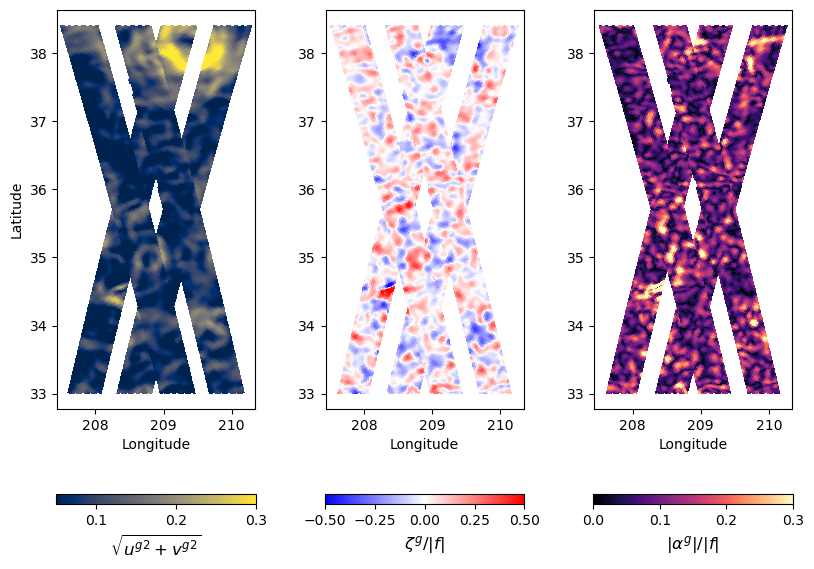

In [235]:
fig, (ax0, ax1,ax2) = plt.subplots(figsize=(9,6), nrows=1, ncols=3)
fig.set_tight_layout(True)
im0 = ax0.pcolormesh(sp5.isel(cycle_num=cnum).longitude, sp5.isel(cycle_num=cnum).latitude,
               sp5.isel(cycle_num=cnum),
               vmin=.05, vmax=.3, cmap="cividis",
               rasterized=True)
ax0.pcolormesh(sp8.isel(cycle_num=cnum).longitude, sp8.isel(cycle_num=cnum).latitude,
               sp8.isel(cycle_num=cnum),
               vmin=.05, vmax=.3, cmap="cividis",
               rasterized=True)
im1 = ax1.pcolormesh(v5.isel(cycle_num=cnum).longitude, v5.isel(cycle_num=cnum).latitude,
               (v5.isel(cycle_num=cnum) 
                / np.abs(gsw.f(v5.isel(cycle_num=cnum).latitude))),
               vmin=-.5, vmax=.5, cmap="bwr",
               rasterized=True)
ax1.pcolormesh(v8.isel(cycle_num=cnum).longitude, v8.isel(cycle_num=cnum).latitude,
               (v8.isel(cycle_num=cnum) 
                / np.abs(gsw.f(v8.isel(cycle_num=cnum).latitude))),
               vmin=-.5, vmax=.5, cmap="bwr",
               rasterized=True)
im2 = ax2.pcolormesh(s5.isel(cycle_num=cnum).longitude, s5.isel(cycle_num=cnum).latitude,
               (s5.isel(cycle_num=cnum) 
                / np.abs(gsw.f(s5.isel(cycle_num=cnum).latitude))),
               vmax=.3, vmin=0., cmap="magma",
               rasterized=True)
ax2.pcolormesh(s8.isel(cycle_num=cnum).longitude, s8.isel(cycle_num=cnum).latitude,
               (s8.isel(cycle_num=cnum) 
                / np.abs(gsw.f(s6.isel(cycle_num=cnum).latitude))),
               vmax=.3, vmin=0., cmap="magma",
               rasterized=True)
ax0.set_aspect("equal")
ax1.set_aspect("equal")
ax2.set_aspect("equal")
ax0.set_xlabel(r"Longitude")
ax1.set_xlabel(r"Longitude")
ax0.set_ylabel(r"Latitude")
ax2.set_xlabel(r"Longitude")
cbar0 = fig.colorbar(im0, ax=ax0, orientation="horizontal", shrink=.6)
cbar1 = fig.colorbar(im1, ax=ax1, orientation="horizontal", shrink=.6)
cbar2 = fig.colorbar(im2, ax=ax2, orientation="horizontal", shrink=.6)
cbar0.set_label(r"$\sqrt{{u^g}^2 + {v^g}^2}$", fontsize=12)
cbar1.set_label(r"$\zeta^g/|f|$", fontsize=12)
cbar2.set_label(r"$|\alpha^g|/|f|$", fontsize=12)
plt.savefig(op.join(ddir,"../Figs/vort-strain-nH.pdf"))

In [237]:
vbins = np.linspace(-3e0,3e0,60)
sbins = np.linspace(0,3e0,30)
hist_c = xhist((strain / np.abs(f)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort / np.abs(f)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()
hist_r = xhist((str_raw / np.abs(fr)).rename('strain'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               (vort_raw / np.abs(fr)).rename('vort'
                             ).chunk({'cycle_num':10,'num_lines':-1,'num_pixels':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()

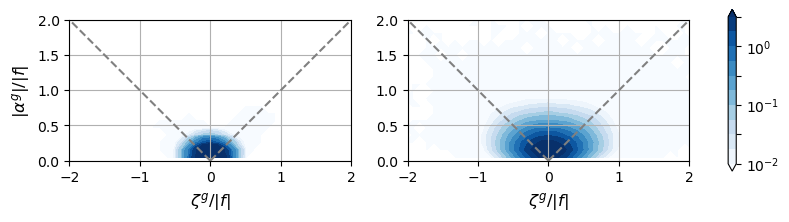

In [238]:
fig, axes = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
# fig.set_tight_layout(True)

im = axes[0].contourf(hist_c.vort_bin,
                 hist_c.strain_bin,
                 hist_c, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )
axes[1].contourf(hist_r.vort_bin,
                 hist_r.strain_bin,
                 hist_r, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )

# for c in im.collections:
#     c.set_rasterized(True)

axes[0].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[0].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')
axes[1].plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
axes[1].plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')

axes[0].set_xlim([-2,2])
axes[0].set_ylim([0,2])
axes[1].set_xlim([-2,2])
axes[1].set_ylim([0,2])

axes[0].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[1].set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
axes[0].set_ylabel(r"$|\alpha^g|/|f|$", fontsize=12)

axes[0].grid(True)
axes[0].set_aspect('equal')
axes[1].grid(True)
axes[1].set_aspect('equal')

# fig.subplots_adjust(hspace=.06, wspace=.12)
# cbar = fig.colorbar(im, orientation='horizontal', ax=axes, shrink=.4, 
#                     ticks=[1e-4,1e-3,1e-2,1e-1,1e0])
cbar = fig.colorbar(im, ax=axes, shrink=.7)
# cbar.set_ticks([1e-2,1e-1,0,1])

plt.savefig(op.join(ddir,"../Figs/vort-strain-nHjointPDF.pdf"))